In [ ]:
!wget -O brfss_data.zip https://www.cdc.gov/brfss/annual_data/2024/files/LLCP2024XPT.zip
!wget -O var_layout.html https://www.cdc.gov/brfss/annual_data/2024/llcp_varlayout_24_onecolumn.html
!wget -O codebook.zip https://www.cdc.gov/brfss/annual_data/2024/zip/codebook24_llcp-v2-508.zip

!unzip -q brfss_data.zip
!unzip -q codebook.zip

!ls

import os
os.rename("LLCP2024.XPT ", "LLCP2024.XPT")

--2026-04-08 05:55:51--  https://www.cdc.gov/brfss/annual_data/2024/files/LLCP2024XPT.zip
Resolving www.cdc.gov (www.cdc.gov)... 184.29.161.36, 2600:1405:401:18f::2461, 2600:1405:401:18e::2461
Connecting to www.cdc.gov (www.cdc.gov)|184.29.161.36|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 83007956 (79M) [application/x-zip-compressed]
Saving to: ‘brfss_data.zip’

brfss_data.zip      100%[===================>]  79.16M  44.2MB/s    in 1.8s    

2026-04-08 05:55:53 (44.2 MB/s) - ‘brfss_data.zip’ saved [83007956/83007956]

--2026-04-08 05:55:53--  https://www.cdc.gov/brfss/annual_data/2024/llcp_varlayout_24_onecolumn.html
Resolving www.cdc.gov (www.cdc.gov)... 184.29.161.36, 2600:1405:401:18f::2461, 2600:1405:401:18e::2461
Connecting to www.cdc.gov (www.cdc.gov)|184.29.161.36|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘var_layout.html’

var_layout.html         [ <=>                ] 108.36K  --.

In [ ]:
# ============================================================================================
#  BRFSS 2024 | STAGE 1 — Data Loading, Variable Selection, Recoding & Missingness Assessment
# ============================================================================================

In [ ]:
# 0. Install dependencies ──────────────────────────────────
!pip install -q pandas numpy matplotlib seaborn scipy pyreadstat missingno

import warnings
warnings.filterwarnings("ignore")

import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import missingno as msno
from scipy import stats

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 15.6 MB/s eta 0:00:00


In [ ]:
# 1. Load raw dataset
df_raw = pd.read_sas("LLCP2024.XPT", encoding="latin1")
print(f"Raw shape: {df_raw.shape}")

Loading BRFSS 2024 XPT file … (may take ~60 s)
Raw shape: (457670, 301)


In [ ]:
# 2. Variable manifest

VAR_MAP = {
    # ── EXPOSURE ─────────────────────────────────────────────
    "SDLONELY"  : "lonely_raw",      # Loneliness (1=always … 5=never)
    "EMTSUPRT"  : "social_support_raw",  # Emotional support (1=always … 5=never)
    "LSATISFY"  : "life_satisfy_raw",   # Life satisfaction (1=very sat … 4=very dis)

    # ── PRIMARY OUTCOMES ──────────────────────────────────────
    "ADDEPEV3"  : "depression",       # Ever told had depression (1=Yes, 2=No)
    "MENTHLTH"  : "bad_mental_days",  # Days mental health not good (0–30)
    "GENHLTH"   : "gen_health",       # General health (1=Excellent … 5=Poor)
    "PHYSHLTH"  : "bad_physical_days",# Days physical health not good (0–30)

    # ── CHRONIC DISEASE (for multimorbidity index) ────────────
    "CVDINFR4"  : "heart_attack",     # Ever had heart attack (1=Yes, 2=No)
    "CVDCRHD4"  : "coronary_hd",      # Coronary heart disease (1=Yes, 2=No)
    "CVDSTRK3"  : "stroke",           # Ever had stroke (1=Yes, 2=No)
    "ASTHMA3"   : "asthma",           # Ever told had asthma (1=Yes, 2=No)
    "CHCSCNC1"  : "skin_cancer",      # Skin cancer (1=Yes, 2=No)
    "CHCOCNC1"  : "other_cancer",     # Other cancer (1=Yes, 2=No)
    "CHCCOPD3"  : "copd",             # COPD/emphysema (1=Yes, 2=No)
    "CHCKDNY2"  : "kidney_disease",   # Kidney disease (1=Yes, 2=No)
    "HAVARTH4"  : "arthritis",        # Arthritis (1=Yes, 2=No)
    "DIABETE4"  : "diabetes",         # Diabetes status (1=Yes, 2=pre, 3=gestational, 4=No)

    # ── CONFOUNDERS — sociodemographic ───────────────────────
    "_SEX"      : "sex",              # Sex (1=Male, 2=Female)
    "_AGEG5YR"  : "age_group",        # Age group 5-yr (1=18–24 … 13=80+)
    "_RACE"     : "race",             # Race/ethnicity category
    "EDUCA"     : "education",        # Education level (1–6)
    "INCOME3"   : "income",           # Income category (1–11)
    "EMPLOY1"   : "employment",       # Employment status (1–8)
    "MARITAL"   : "marital_status",   # Marital status (1–6)
    "RENTHOM1"  : "housing",          # Own/rent home (1=Own, 2=Rent, 3=Other)
    "CHILDREN"  : "n_children",       # Number of children in household

    # ── CONFOUNDERS — health behaviours ──────────────────────
    "_SMOKER3"  : "smoking_status",   # Smoking status (1=daily, 2=someday, 3=former, 4=never)
    "EXERANY2"  : "physical_activity",# Any physical activity (1=Yes, 2=No)
    "_BMI5CAT"  : "bmi_cat",          # BMI category (1=Underweight…4=Obese)
    "ALCDAY4"   : "alcohol_days",     # Days per week/month drinking
    "DRNKANY6"  : "any_alcohol",      # Any alcohol in past 30 days (1=Yes, 2=No)

    # ── CONFOUNDERS — healthcare access ──────────────────────
    "PERSDOC3"  : "has_doctor",       # Has personal doctor (1=Yes only one, 2=Yes multiple, 3=No)
    "MEDCOST1"  : "cost_barrier",     # Could not see doctor due to cost (1=Yes, 2=No)
    "_HLTHPL2"  : "health_insurance", # Health plan/insurance (1=Yes, 2=No)
    "CHECKUP1"  : "last_checkup",     # Last routine checkup (1=<1yr … 8=never)

    # ── SOCIAL DETERMINANTS (additional confounders/mediators)
    "FOODSTMP"  : "food_stamps",      # Received food stamps (1=Yes, 2=No)
    "SDHFOOD1"  : "food_insecurity",  # Food insecurity worry (1=never … 4=always)
    "SDHBILLS"  : "cant_pay_bills",   # Hard to pay bills (1=never … 4=always)
    "SDHUTILS"  : "utility_worry",    # Utilities cut off worry (1=never … 4=always)
    "HOWSAFE1"  : "neighbourhood_safety", # Safety in neighbourhood (1=very safe … 4=unsafe)

    # ── ADVERSE CHILDHOOD EXPERIENCES (sensitivity analysis) ─
    "ACEDEPRS"  : "ace_parent_depressed",
    "ACEDRINK"  : "ace_parent_alcohol",
    "ACEDRUGS"  : "ace_household_drugs",
    "ACEPRISN"  : "ace_household_prison",
    "ACEDIVRC"  : "ace_parent_divorced",
    "ACEPUNCH"  : "ace_violence_witness",
    "ACEHURT1"  : "ace_physical_abuse",
    "ACESWEAR"  : "ace_emotional_abuse",
    "ACETOUCH"  : "ace_sexual_abuse",

    # ── SURVEY WEIGHT ─────────────────────────────────────────
    "_LLCPWT"   : "survey_weight",    # Final combined landline+cell weight
    "_STSTR"    : "stratum",          # Stratification variable
    "_PSU"      : "psu",              # Primary sampling unit
}

available = {k: v for k, v in VAR_MAP.items() if k in df_raw.columns}
missing_cols = [k for k in VAR_MAP if k not in df_raw.columns]
if missing_cols:
    print(f"⚠  Columns not found in raw file (will skip): {missing_cols}")

df = df_raw[list(available.keys())].copy()
df.rename(columns=available, inplace=True)
print(f"\nWorking dataset shape: {df.shape}")
print(f"Variables selected: {df.shape[1]}")


Working dataset shape: (457670, 52)
Variables selected: 52


In [ ]:
import gc

del df_raw
gc.collect()

0

In [ ]:
# 3. Recode variables
print("\n── Recoding variables …")

REFUSE_CODES = {7, 9, 77, 99, 777, 999, 7777, 9999}

def brfss_na(series, extra=None):
    """Set BRFSS missing/refusal codes to NaN."""
    codes = REFUSE_CODES.copy()
    if extra:
        codes.update(extra)
    return series.where(~series.isin(codes))


# 3a. EXPOSURE — Loneliness / Social isolation composite

df["lonely_raw"]        = brfss_na(df["lonely_raw"])
df["social_support_raw"]= brfss_na(df["social_support_raw"])
df["life_satisfy_raw"]  = brfss_na(df["life_satisfy_raw"])

df["lonely_score"]       = 6 - df["lonely_raw"]

df["support_score"]      = df["social_support_raw"]

df["satisfy_score"]      = 5 - df["life_satisfy_raw"]

def standardise(s):
    return (s - s.mean()) / s.std()

components = df[["lonely_score", "support_score"]].copy()
components["support_score"] = components["support_score"]

df["sii_raw"] = (
    standardise(df["lonely_score"])
  + standardise(df["support_score"])
) / 2

q75 = df["sii_raw"].quantile(0.75)
df["isolated"] = (df["sii_raw"] >= q75).astype(float)
df.loc[df["sii_raw"].isna(), "isolated"] = np.nan

print(f"  Exposure — Social isolation index created (top-quartile binary)")
print(f"  Isolated=1: {df['isolated'].value_counts(normalize=True).get(1.0, 0):.1%} of non-missing respondents")


# 3b. PRIMARY OUTCOMES

df["depression"]     = brfss_na(df["depression"])
df["depression_bin"] = np.where(df["depression"] == 1, 1,
                       np.where(df["depression"] == 2, 0, np.nan))
df["bad_mental_days"] = brfss_na(df["bad_mental_days"], extra={88})
df["bad_mental_days"] = df["bad_mental_days"].where(
    df["bad_mental_days"].between(0, 30) | (df["bad_mental_days"] == 88)
)
df["bad_mental_days"] = df["bad_mental_days"].replace(88, 0)

df["bad_physical_days"] = brfss_na(df["bad_physical_days"], extra={88})
df["bad_physical_days"] = df["bad_physical_days"].where(
    df["bad_physical_days"].between(0, 30) | (df["bad_physical_days"] == 88)
)
df["bad_physical_days"] = df["bad_physical_days"].replace(88, 0)

df["gen_health"] = brfss_na(df["gen_health"])
df["poor_health_bin"] = np.where(df["gen_health"].isin([4, 5]), 1,
                        np.where(df["gen_health"].isin([1, 2, 3]), 0, np.nan))


# 3c. MULTIMORBIDITY INDEX

chronic_vars_raw = [
    "heart_attack", "coronary_hd", "stroke", "asthma",
    "skin_cancer", "other_cancer", "copd", "kidney_disease",
    "arthritis"
]

for v in chronic_vars_raw:
    df[v] = brfss_na(df[v])
    df[v + "_bin"] = np.where(df[v] == 1, 1,
                     np.where(df[v] == 2, 0, np.nan))

df["diabetes"] = brfss_na(df["diabetes"])
df["diabetes_bin"] = np.where(df["diabetes"] == 1, 1,
                     np.where(df["diabetes"] == 4, 0, np.nan))

chronic_bins = [v + "_bin" for v in chronic_vars_raw] + ["diabetes_bin"]

df["n_conditions"] = df[chronic_bins].sum(axis=1)

df["n_cond_valid"]  = df[chronic_bins].notna().sum(axis=1)
df.loc[df["n_cond_valid"] < 8, "n_conditions"] = np.nan
df["multimorbidity"] = (df["n_conditions"] >= 2).astype(float)
df.loc[df["n_conditions"].isna(), "multimorbidity"] = np.nan

print(f"  Multimorbidity (≥2 conditions): "
      f"{df['multimorbidity'].value_counts(normalize=True).get(1.0, 0):.1%} of non-missing")


# 3d. CONFOUNDERS

df["sex"] = brfss_na(df["sex"])
df["male"] = np.where(df["sex"] == 1, 1,
             np.where(df["sex"] == 2, 0, np.nan))

age_map = {1:21, 2:27, 3:32, 4:37, 5:42, 6:47, 7:52,
           8:57, 9:62, 10:67, 11:72, 12:77, 13:82}
df["age_group"] = brfss_na(df["age_group"], extra={14})
df["age_mid"]   = df["age_group"].map(age_map)
df["age65plus"] = (df["age_mid"] >= 65).astype(float)
df.loc[df["age_mid"].isna(), "age65plus"] = np.nan

df["race"] = brfss_na(df["race"], extra={8})
race_map = {1: "White_NH", 2: "Black_NH", 3: "AIAN_NH",
            4: "Asian_NH", 5: "NHPI_NH", 6: "Other_NH",
            7: "Multiracial_NH", 8: np.nan, 9: "Hispanic"}
df["race_eth"] = df["race"].map(race_map)

df["black"]    = (df["race_eth"] == "Black_NH").astype(float)
df["hispanic"] = (df["race_eth"] == "Hispanic").astype(float)
df["asian"]    = (df["race_eth"] == "Asian_NH").astype(float)
df["other_race"] = df["race_eth"].isin(
    ["AIAN_NH","NHPI_NH","Other_NH","Multiracial_NH"]).astype(float)
df.loc[df["race_eth"].isna(), ["black","hispanic","asian","other_race"]] = np.nan

df["education"] = brfss_na(df["education"], extra={9})
df["edu_cat"] = pd.cut(df["education"], bins=[0,2,4,6],
                        labels=["less_than_hs", "some_college", "college_plus"])

df["income"] = brfss_na(df["income"], extra={99})
df["income_cat"] = pd.cut(df["income"], bins=[0, 4, 7, 11],
                           labels=["low", "mid", "high"])

df["employment"] = brfss_na(df["employment"], extra={9})
df["employed"] = np.where(df["employment"].isin([1, 2]), 1,
                 np.where(df["employment"].isin([3,4,5,6,7,8]), 0, np.nan))

df["marital_status"] = brfss_na(df["marital_status"], extra={9})
df["married"] = np.where(df["marital_status"] == 1, 1,
                np.where(df["marital_status"].between(2, 6), 0, np.nan))

df["housing"] = brfss_na(df["housing"], extra={9})
df["homeowner"] = np.where(df["housing"] == 1, 1,
                  np.where(df["housing"].isin([2, 3]), 0, np.nan))

df["smoking_status"] = brfss_na(df["smoking_status"])
df["current_smoker"] = np.where(df["smoking_status"].isin([1, 2]), 1,
                       np.where(df["smoking_status"].isin([3, 4]), 0, np.nan))

df["physical_activity"] = brfss_na(df["physical_activity"], extra={9})
df["active"] = np.where(df["physical_activity"] == 1, 1,
               np.where(df["physical_activity"] == 2, 0, np.nan))

df["bmi_cat"] = brfss_na(df["bmi_cat"])
df["obese"] = np.where(df["bmi_cat"] == 4, 1,
              np.where(df["bmi_cat"].isin([1, 2, 3]), 0, np.nan))

df["any_alcohol"] = brfss_na(df["any_alcohol"], extra={9})
df["drinks_alcohol"] = np.where(df["any_alcohol"] == 1, 1,
                       np.where(df["any_alcohol"] == 2, 0, np.nan))

df["has_doctor"]      = brfss_na(df["has_doctor"], extra={9})
df["has_doctor_bin"]  = np.where(df["has_doctor"].isin([1, 2]), 1,
                        np.where(df["has_doctor"] == 3, 0, np.nan))

df["cost_barrier"]    = brfss_na(df["cost_barrier"], extra={9})
df["cost_barrier_bin"]= np.where(df["cost_barrier"] == 1, 1,
                        np.where(df["cost_barrier"] == 2, 0, np.nan))

df["health_insurance"]= brfss_na(df["health_insurance"])
df["insured"]         = np.where(df["health_insurance"] == 1, 1,
                        np.where(df["health_insurance"] == 2, 0, np.nan))

df["last_checkup"]    = brfss_na(df["last_checkup"], extra={9})
df["checkup_recent"]  = np.where(df["last_checkup"] == 1, 1,
                        np.where(df["last_checkup"].between(2, 8), 0, np.nan))

df["food_stamps"]        = brfss_na(df["food_stamps"], extra={9})
df["food_stamps_bin"]    = np.where(df["food_stamps"] == 1, 1,
                           np.where(df["food_stamps"] == 2, 0, np.nan))

df["food_insecurity"]    = brfss_na(df["food_insecurity"], extra={9})
df["food_insecure_bin"]  = np.where(df["food_insecurity"].isin([3, 4]), 1,
                           np.where(df["food_insecurity"].isin([1, 2]), 0, np.nan))

df["neighbourhood_safety"] = brfss_na(df["neighbourhood_safety"], extra={9})
df["unsafe_neighbourhood"] = np.where(df["neighbourhood_safety"] == 4, 1,
                             np.where(df["neighbourhood_safety"].isin([1,2,3]), 0, np.nan))

df["cant_pay_bills"]    = brfss_na(df["cant_pay_bills"], extra={9})
df["bills_hardship"]    = np.where(df["cant_pay_bills"].isin([3, 4]), 1,
                          np.where(df["cant_pay_bills"].isin([1, 2]), 0, np.nan))

ace_vars = [
    "ace_parent_depressed", "ace_parent_alcohol", "ace_household_drugs",
    "ace_household_prison", "ace_parent_divorced", "ace_violence_witness",
    "ace_physical_abuse", "ace_emotional_abuse", "ace_sexual_abuse"
]
for v in ace_vars:
    df[v] = brfss_na(df[v], extra={9})
    df[v + "_bin"] = np.where(df[v] == 1, 1,
                     np.where(df[v] == 2, 0, np.nan))

ace_bin_vars = [v + "_bin" for v in ace_vars]
df["ace_score"] = df[ace_bin_vars].sum(axis=1)
df.loc[df[ace_bin_vars].notna().sum(axis=1) < 7, "ace_score"] = np.nan
df["high_ace"] = (df["ace_score"] >= 4).astype(float)
df.loc[df["ace_score"].isna(), "high_ace"] = np.nan

print(f"  ACE score computed (0–9 events)")


── Recoding variables …
  Exposure — Social isolation index created (top-quartile binary)
  Isolated=1: 26.8% of non-missing respondents
  Multimorbidity (≥2 conditions): 30.6% of non-missing
  ACE score computed (0–9 events)


In [ ]:
# 4. Define final analytic variable lists

EXPOSURE   = "isolated"
OUTCOMES   = ["depression_bin", "multimorbidity", "bad_mental_days", "poor_health_bin"]
MEDIATOR   = "depression_bin"

CONFOUNDERS = [
    "male", "age_mid", "age65plus",
    "black", "hispanic", "asian", "other_race",
    "married", "homeowner", "employed",
    "edu_cat", "income_cat",
    "current_smoker", "active", "obese", "drinks_alcohol",
    "has_doctor_bin", "insured", "cost_barrier_bin", "checkup_recent",
    "food_stamps_bin", "food_insecure_bin", "bills_hardship",
    "unsafe_neighbourhood",
    "high_ace",
]

SURVEY_VARS = ["survey_weight", "stratum", "psu"]

KEEP_COLS = (
    [EXPOSURE] + OUTCOMES + CONFOUNDERS + SURVEY_VARS
    + ["sii_raw", "lonely_score", "support_score",
       "n_conditions", "age_group", "race_eth", "ace_score"]
)
KEEP_COLS = [c for c in KEEP_COLS if c in df.columns]

df_analytic = df[KEEP_COLS].copy()
print(f"\nAnalytic dataset shape: {df_analytic.shape}")


Analytic dataset shape: (457670, 40)


In [ ]:
# 5. Restrict to adults with non-zero survey weight
df_analytic = df_analytic[df_analytic["survey_weight"] > 0].copy()
print(f"After weight filter: {df_analytic.shape}")

After weight filter: (457670, 40)



── Missingness report ──
                      n_missing  pct_missing
high_ace                 422664       92.350
ace_score                422664       92.350
food_insecure_bin        416118       90.920
bad_mental_days          286674       62.640
sii_raw                  257928       56.360
isolated                 257928       56.360
unsafe_neighbourhood     257670       56.300
support_score            257046       56.160
bills_hardship           256223       55.980
food_stamps_bin          255541       55.840
lonely_score             255537       55.830
income_cat               203910       44.550
employed                 155318       33.940
age_mid                   83395       18.220
age65plus                 83395       18.220
age_group                 83395       18.220
race_eth                  68235       14.910
hispanic                  68235       14.910
asian                     68235       14.910
black                     68235       14.910
other_race                682

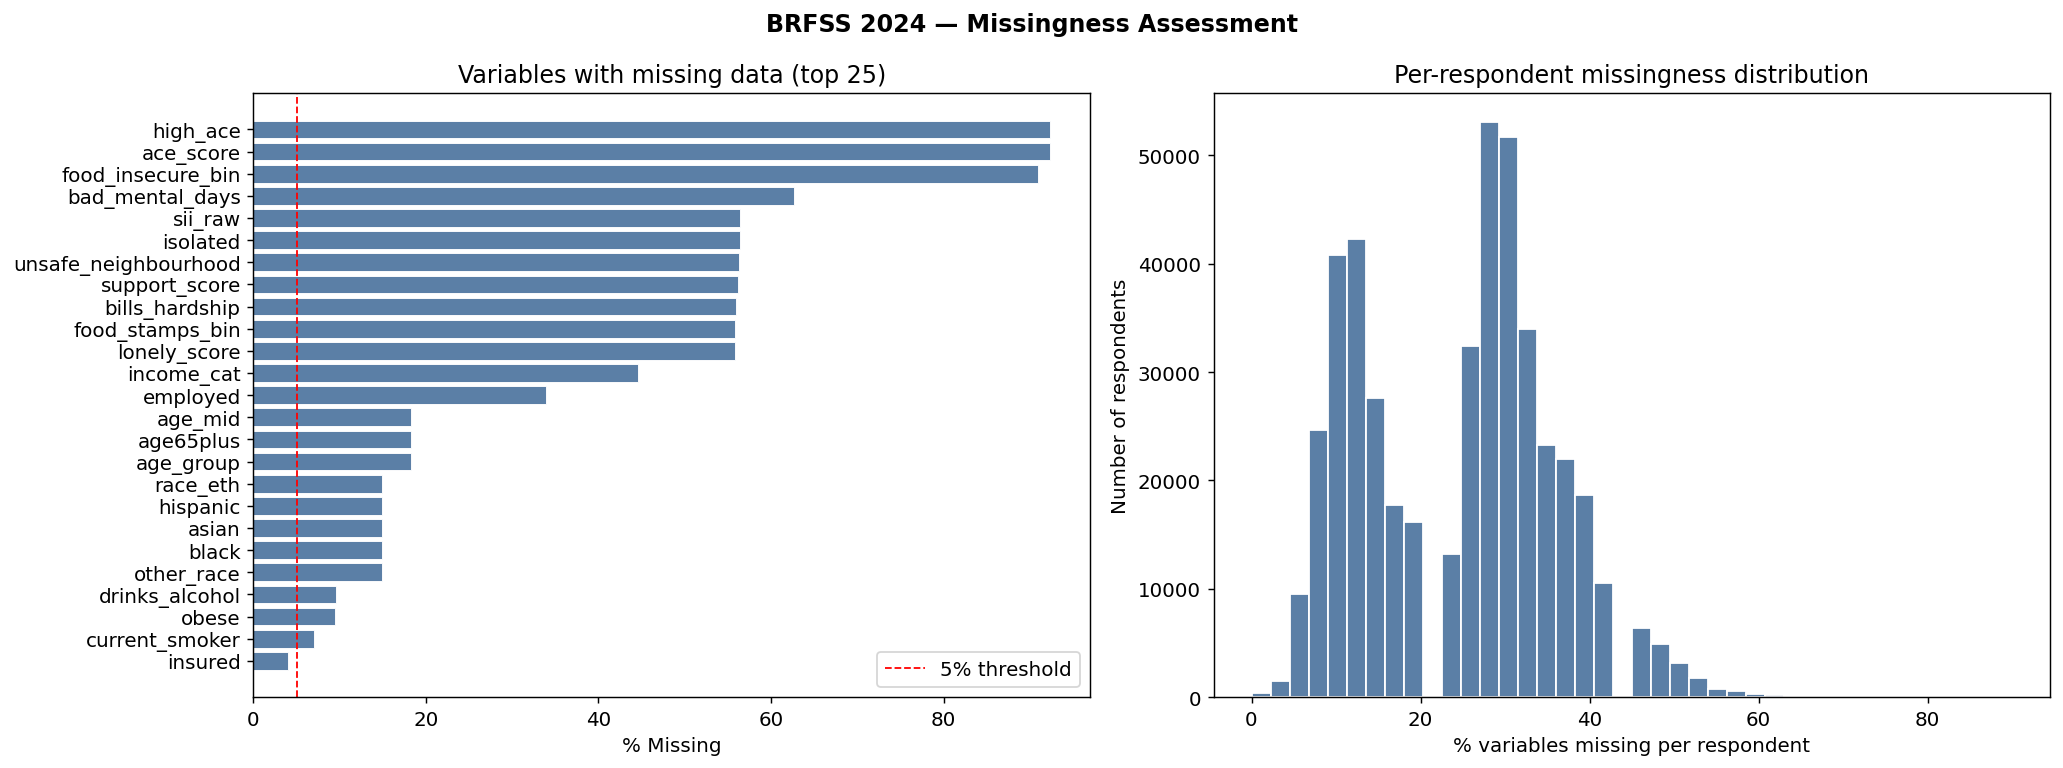

Figure saved: fig_missingness.png


In [ ]:
# 6. Missingness assessment
print("\n── Missingness report ──")

miss = pd.DataFrame({
    "n_missing"  : df_analytic.isnull().sum(),
    "pct_missing": df_analytic.isnull().mean() * 100
}).sort_values("pct_missing", ascending=False)

print(miss[miss["pct_missing"] > 0].round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_missing = miss[miss["pct_missing"] > 0].head(25)
axes[0].barh(top_missing.index[::-1], top_missing["pct_missing"][::-1],
             color="#5B7FA6", edgecolor="white", linewidth=0.5)
axes[0].axvline(5, color="red", linestyle="--", linewidth=1, label="5% threshold")
axes[0].set_xlabel("% Missing")
axes[0].set_title("Variables with missing data (top 25)")
axes[0].legend()

row_miss = df_analytic.isnull().mean(axis=1) * 100
axes[1].hist(row_miss, bins=40, color="#5B7FA6", edgecolor="white")
axes[1].set_xlabel("% variables missing per respondent")
axes[1].set_ylabel("Number of respondents")
axes[1].set_title("Per-respondent missingness distribution")

plt.suptitle("BRFSS 2024 — Missingness Assessment", fontweight="bold")
plt.tight_layout()
plt.savefig("fig_missingness.png", bbox_inches="tight")
plt.show()
print("Figure saved: fig_missingness.png")

In [ ]:
# 7. Restrict to complete exposure + outcome

mask_complete = (
    df_analytic[EXPOSURE].notna() &
    df_analytic[OUTCOMES].notna().any(axis=1)
)
df_analytic = df_analytic[mask_complete].copy()
print(f"\nAfter exposure+outcome completeness filter: {df_analytic.shape[0]:,} respondents")



After exposure+outcome completeness filter: 199,740 respondents


In [ ]:
# 8. Summarise exposure & outcomes
print("\n── Exposure distribution ──")
print(df_analytic["isolated"].value_counts(dropna=False))
print(f"  SII mean: {df_analytic['sii_raw'].mean():.3f}, SD: {df_analytic['sii_raw'].std():.3f}")

print("\n── Outcome prevalence (unweighted) ──")
for o in OUTCOMES:
    if o in df_analytic.columns:
        vc = df_analytic[o].value_counts(normalize=True, dropna=True)
        print(f"  {o}: {vc.get(1.0, 0):.1%} positive")



── Exposure distribution ──
isolated
0.000    146114
1.000     53626
Name: count, dtype: int64
  SII mean: 0.000, SD: 0.822

── Outcome prevalence (unweighted) ──
  depression_bin: 21.2% positive
  multimorbidity: 31.3% positive
  bad_mental_days: 9.3% positive
  poor_health_bin: 19.6% positive


In [ ]:
# 9. Save analytic dataset
df_analytic.to_parquet("brfss_analytic_stage1.parquet", index=False)
df_analytic.to_csv("brfss_analytic_stage1.csv", index=False)
print("\n✓  Stage 1 complete.")
print(f"   Saved: brfss_analytic_stage1.parquet  ({df_analytic.shape[0]:,} rows × {df_analytic.shape[1]} cols)")
print(f"   Saved: brfss_analytic_stage1.csv")


✓  Stage 1 complete.
   Saved: brfss_analytic_stage1.parquet  (199,740 rows × 40 cols)
   Saved: brfss_analytic_stage1.csv


In [ ]:
df_analytic.to_parquet("brfss_analytic_stage1.parquet", index=False)
df_analytic.to_csv("brfss_analytic_stage1.csv", index=False)

del df
del df_analytic
gc.collect()

6

In [ ]:
# ================================================================================================
#  BRFSS 2024 | STAGE 2 — Multiple Imputation (MICE), Survey-Weighted Descriptive Statistics & EDA
# ================================================================================================

In [ ]:
# 0. Install dependencies
!pip install -q miceforest tableone matplotlib seaborn scipy

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import miceforest as mf
from tableone import TableOne

pd.set_option("display.float_format", lambda x: f"{x:.3f}")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

SEED = 42
np.random.seed(SEED)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00


In [ ]:
# 1. Load Stage 1 output
df = pd.read_parquet("brfss_analytic_stage1.parquet")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")

Loaded: 199,740 rows × 40 cols


In [ ]:
# 2. Reassess missingness WITHIN analytic sample
print("\n── Missingness within analytic sample (N=199,740) ──")
miss_in = pd.DataFrame({
    "n_missing"  : df.isnull().sum(),
    "pct_missing": df.isnull().mean() * 100
}).sort_values("pct_missing", ascending=False)
print(miss_in[miss_in["pct_missing"] > 0].round(2).to_string())


── Missingness within analytic sample (N=199,740) ──
                      n_missing  pct_missing
high_ace                 180635       90.440
ace_score                180635       90.440
food_insecure_bin        158946       79.580
bad_mental_days          125818       62.990
income_cat                86175       43.140
employed                  69081       34.590
age_mid                   35882       17.960
age65plus                 35882       17.960
age_group                 35882       17.960
other_race                28450       14.240
race_eth                  28450       14.240
black                     28450       14.240
asian                     28450       14.240
hispanic                  28450       14.240
obese                     11615        5.820
insured                    6798        3.400
unsafe_neighbourhood       2827        1.420
checkup_recent             2131        1.070
drinks_alcohol             1860        0.930
has_doctor_bin             1677        0.840
b

In [ ]:
# 3. Define confounder set for imputation

DROP_FROM_MICE = ["high_ace", "ace_score", "food_insecure_bin",
                  "age_group", "race_eth",    #raw/redundant versions
                  "sii_raw", "lonely_score", "support_score",  #exposure components
                  "n_conditions",              #used only for multimorbidity construction
                  "bad_mental_days",           #outcome, impute separately
                  "stratum", "psu"]            #survey design vars, not imputed

OUTCOMES  = ["depression_bin", "multimorbidity", "poor_health_bin"]
EXPOSURE  = "isolated"

CONFOUNDERS_FOR_MICE = [
    "male", "age_mid", "age65plus",
    "black", "hispanic", "asian", "other_race",
    "married", "homeowner", "employed",
    "edu_cat", "income_cat",
    "current_smoker", "active", "obese", "drinks_alcohol",
    "has_doctor_bin", "insured", "cost_barrier_bin", "checkup_recent",
    "food_stamps_bin", "bills_hardship", "unsafe_neighbourhood",
]

pct_miss = df[CONFOUNDERS_FOR_MICE].isnull().mean() * 100
high_miss = pct_miss[pct_miss > 40].index.tolist()
if high_miss:
    print(f"\n⚠  Confounders >40% missing in analytic sample → removed from MICE:")
    print(f"   {high_miss}")
    CONFOUNDERS_FOR_MICE = [c for c in CONFOUNDERS_FOR_MICE if c not in high_miss]

print(f"\nFinal confounder set ({len(CONFOUNDERS_FOR_MICE)} variables):")
print(CONFOUNDERS_FOR_MICE)

df["edu_num"]    = df["edu_cat"].map({"less_than_hs": 1, "some_college": 2, "college_plus": 3})
df["income_num"] = df["income_cat"].map({"low": 1, "mid": 2, "high": 3})

CONFOUNDERS_NUM = [c if c not in ("edu_cat","income_cat")
                   else c.replace("cat","num")
                   for c in CONFOUNDERS_FOR_MICE]
CONFOUNDERS_NUM = list(dict.fromkeys(
    ["edu_num" if c == "edu_cat" else
     "income_num" if c == "income_cat" else c
     for c in CONFOUNDERS_FOR_MICE]))

MICE_COLS = [EXPOSURE] + OUTCOMES + CONFOUNDERS_NUM


⚠  Confounders >40% missing in analytic sample → removed from MICE:
   ['income_cat']

Final confounder set (22 variables):
['male', 'age_mid', 'age65plus', 'black', 'hispanic', 'asian', 'other_race', 'married', 'homeowner', 'employed', 'edu_cat', 'current_smoker', 'active', 'obese', 'drinks_alcohol', 'has_doctor_bin', 'insured', 'cost_barrier_bin', 'checkup_recent', 'food_stamps_bin', 'bills_hardship', 'unsafe_neighbourhood']


In [ ]:
# 4. Run MICE (m=5 imputed datasets, 5 iterations)
print("\n── Running MICE (m=5, iterations=5) … this takes ~3–5 min ──")

df_mice_input = df[MICE_COLS].copy()

for c in df_mice_input.columns:
    df_mice_input[c] = pd.to_numeric(df_mice_input[c], errors="coerce").astype(float)

kernel = mf.ImputationKernel(
    data=df_mice_input,
    num_datasets=5,
    random_state=SEED
)

kernel.mice(iterations=5, verbose=True)
print("MICE complete.")

imputed_datasets = [kernel.complete_data(dataset=i) for i in range(5)]

df_imp = imputed_datasets[0].copy()
df_imp["survey_weight"] = df["survey_weight"].values
df_imp["stratum"]       = df["stratum"].values
df_imp["psu"]           = df["psu"].values
df_imp["age_mid"]       = df_imp["age_mid"].round().clip(18, 85)

for i, imp in enumerate(imputed_datasets):
    imp["survey_weight"] = df["survey_weight"].values
    imp["stratum"]       = df["stratum"].values
    imp["psu"]           = df["psu"].values

import pickle
with open("imputed_datasets.pkl", "wb") as f:
    pickle.dump(imputed_datasets, f)
print("Saved imputed_datasets.pkl (all 5 datasets for Rubin's pooling in Stage 4)")


── Running MICE (m=5, iterations=5) … this takes ~3–5 min ──
Initialized logger with name MICE Iterations 1 - 5 and 4 levels
1 Dataset 0
 | active | poor_health_bin | cost_barrier_bin | edu_num | multimorbidity | food_stamps_bin | depression_bin | current_smoker | homeowner | married | bills_hardship | has_doctor_bin | drinks_alcohol | checkup_recent | unsafe_neighbourhood | insured | obese | asian | black | hispanic | other_race | age_mid | age65plus | employed
Dataset 1
 | active | poor_health_bin | cost_barrier_bin | edu_num | multimorbidity | food_stamps_bin | depression_bin | current_smoker | homeowner | married | bills_hardship | has_doctor_bin | drinks_alcohol | checkup_recent | unsafe_neighbourhood | insured | obese | asian | black | hispanic | other_race | age_mid | age65plus | employed
Dataset 2
 | active | poor_health_bin | cost_barrier_bin | edu_num | multimorbidity | food_stamps_bin | depression_bin | current_smoker | homeowner | married | bills_hardship | has_doctor_bin 


── Plotting MICE convergence …


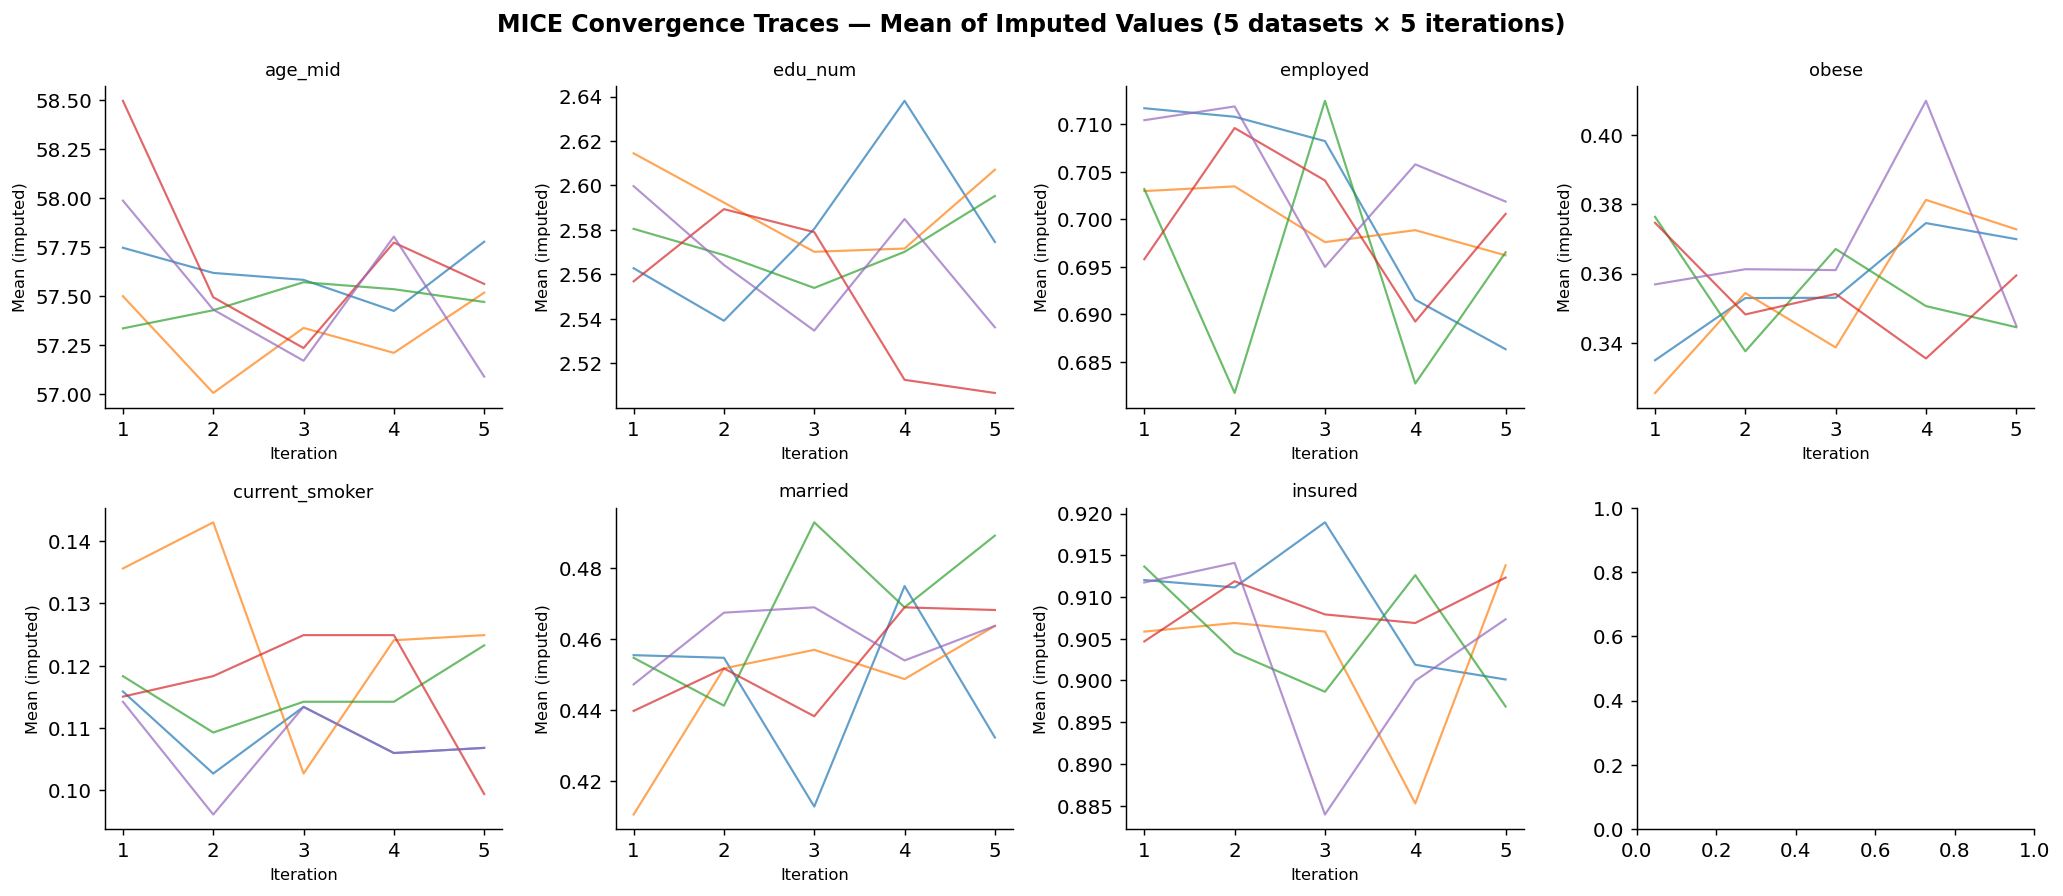

Saved: fig_mice_convergence.png


In [ ]:
# 5. Convergence check: MICE trace plot
print("\n── Plotting MICE convergence …")

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

trace_vars = [v for v in ["age_mid", "income_num", "edu_num", "employed",
                           "obese", "current_smoker", "married", "insured"]
              if v in df_mice_input.columns]

for ax, var in zip(axes, trace_vars):
    try:
        for ds in range(5):
            means = []
            for it in range(1, 6):
                completed = kernel.complete_data(dataset=ds, iteration=it)
                orig_miss = df_mice_input[var].isna()
                means.append(completed.loc[orig_miss, var].mean())
            ax.plot(range(1, 6), means, alpha=0.7, linewidth=1.2)
        ax.set_title(var, fontsize=10)
        ax.set_xlabel("Iteration", fontsize=9)
        ax.set_ylabel("Mean (imputed)", fontsize=9)
    except Exception:
        ax.set_visible(False)

plt.suptitle("MICE Convergence Traces — Mean of Imputed Values (5 datasets × 5 iterations)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("fig_mice_convergence.png", bbox_inches="tight")
plt.show()
print("Saved: fig_mice_convergence.png")

In [ ]:
# 6. Survey-weighted Table 1

print("\n── Building survey-weighted Table 1 …")

W = df_imp["survey_weight"]
E = df_imp[EXPOSURE]

def wtd_mean(x, w):
    mask = x.notna() & w.notna()
    return np.average(x[mask], weights=w[mask])

def wtd_pct(x, w, val=1.0):
    """Weighted % of x == val."""
    mask = x.notna() & w.notna()
    return np.average((x[mask] == val).astype(float), weights=w[mask]) * 100

def wtd_sd(x, w):
    mask = x.notna() & w.notna()
    xm = wtd_mean(x[mask], w[mask])
    variance = np.average((x[mask] - xm)**2, weights=w[mask])
    return np.sqrt(variance)

def smd(x, treated, w):
    """SMD between isolated=1 and isolated=0 (weighted)."""
    mask = x.notna() & treated.notna() & w.notna()
    x1 = x[mask & (treated == 1)];  w1 = w[mask & (treated == 1)]
    x0 = x[mask & (treated == 0)];  w0 = w[mask & (treated == 0)]
    m1 = np.average(x1, weights=w1); m0 = np.average(x0, weights=w0)
    v1 = np.average((x1 - m1)**2, weights=w1)
    v0 = np.average((x0 - m0)**2, weights=w0)
    denom = np.sqrt((v1 + v0) / 2)
    return (m1 - m0) / denom if denom > 0 else np.nan

rows = []

def add_row(label, total_stat, iso1_stat, iso0_stat, smd_val, is_header=False):
    rows.append({
        "Variable"           : ("  " if not is_header else "") + label,
        "Total (N=199,740)"  : total_stat,
        "Isolated (N=53,626)": iso1_stat,
        "Not isolated (N=146,114)": iso0_stat,
        "SMD"                : f"{smd_val:.3f}" if not np.isnan(smd_val) else "—"
    })

iso1 = E == 1
iso0 = E == 0

for label, var in [("Age, mean (SD)", "age_mid")]:
    t_m, t_s = wtd_mean(df_imp[var], W), wtd_sd(df_imp[var], W)
    m1, s1   = wtd_mean(df_imp.loc[iso1, var], W[iso1]), wtd_sd(df_imp.loc[iso1, var], W[iso1])
    m0, s0   = wtd_mean(df_imp.loc[iso0, var], W[iso0]), wtd_sd(df_imp.loc[iso0, var], W[iso0])
    d        = smd(df_imp[var], E, W)
    add_row(label, f"{t_m:.1f} ({t_s:.1f})", f"{m1:.1f} ({s1:.1f})", f"{m0:.1f} ({s0:.1f})", d)

binary_vars = [
    ("Female sex (%)",                "male",            0.0),
    ("Age ≥65 (%)",                   "age65plus",       1.0),
    ("Black/African-American (%)",    "black",           1.0),
    ("Hispanic (%)",                  "hispanic",        1.0),
    ("Asian (%)",                     "asian",           1.0),
    ("Other/multiracial (%)",         "other_race",      1.0),
    ("Married/partnered (%)",         "married",         1.0),
    ("Homeowner (%)",                 "homeowner",       1.0),
    ("Employed (%)",                  "employed",        1.0),
    ("Current smoker (%)",            "current_smoker",  1.0),
    ("Physically active (%)",         "active",          1.0),
    ("Obese (BMI ≥30) (%)",           "obese",           1.0),
    ("Any alcohol use (%)",           "drinks_alcohol",  1.0),
    ("Has personal doctor (%)",       "has_doctor_bin",  1.0),
    ("Health insurance (%)",          "insured",         1.0),
    ("Cost barrier to care (%)",      "cost_barrier_bin",1.0),
    ("Routine checkup <1 yr (%)",     "checkup_recent",  1.0),
    ("Food stamps/SNAP (%)",          1.0),
    ("Financial hardship (%)",        1.0),
    ("Unsafe neighbourhood (%)",      1.0),
]

binary_vars_processed = []
for label, var, val in [
    ("Female sex (%)",                "male",            0.0),
    ("Age ≥65 (%)",                   "age65plus",       1.0),
    ("Black/African-American (%)",    "black",           1.0),
    ("Hispanic (%)",                  "hispanic",        1.0),
    ("Asian (%)",                     "asian",           1.0),
    ("Other/multiracial (%)",         "other_race",      1.0),
    ("Married/partnered (%)",         "married",         1.0),
    ("Homeowner (%)",                 "homeowner",       1.0),
    ("Employed (%)",                  "employed",        1.0),
    ("Current smoker (%)",            "current_smoker",  1.0),
    ("Physically active (%)",         "active",          1.0),
    ("Obese (BMI ≥30) (%)",           "obese",           1.0),
    ("Any alcohol use (%)",           "drinks_alcohol",  1.0),
    ("Has personal doctor (%)",       "has_doctor_bin",  1.0),
    ("Health insurance (%)",          "insured",         1.0),
    ("Cost barrier to care (%)",      "cost_barrier_bin",1.0),
    ("Routine checkup <1 yr (%)",     "checkup_recent",  1.0)
]:
    binary_vars_processed.append((label, var, val))

if "food_stamps_bin" in df_imp.columns:
    binary_vars_processed.append(("Food stamps/SNAP (%)", "food_stamps_bin", 1.0))
if "bills_hardship" in df_imp.columns:
    binary_vars_processed.append(("Financial hardship (%)", "bills_hardship", 1.0))
if "unsafe_neighbourhood" in df_imp.columns:
    binary_vars_processed.append(("Unsafe neighbourhood (%)", "unsafe_neighbourhood", 1.0))

for item in binary_vars_processed:
    label, var, val = item

    t  = wtd_pct(df_imp[var], W, val)
    p1 = wtd_pct(df_imp.loc[iso1, var], W[iso1], val)
    p0 = wtd_pct(df_imp.loc[iso0, var], W[iso0], val)
    d  = smd(df_imp[var], E, W)
    add_row(label, f"{t:.1f}", f"{p1:.1f}", f"{p0:.1f}", d)

if "edu_num" in df_imp.columns:
    for cat_val, lbl in [(1,"Less than HS (%)"), (2,"Some college (%)"), (3,"College grad (%)")]:
        tmp = (df_imp["edu_num"] == cat_val).astype(float)
        t   = wtd_pct(tmp, W, 1.0)
        p1  = wtd_pct(tmp[iso1], W[iso1], 1.0)
        p0  = wtd_pct(tmp[iso0], W[iso0], 1.0)
        d   = smd(tmp, E, W)
        add_row(lbl, f"{t:.1f}", f"{p1:.1f}", f"{p0:.1f}", d)

if "income_num" in df_imp.columns:
    for cat_val, lbl in [(1,"Low income (%)"), (2,"Mid income (%)"), (3,"High income (%)")]:
        tmp = (df_imp["income_num"] == cat_val).astype(float)
        t   = wtd_pct(tmp, W, 1.0)
        p1  = wtd_pct(tmp[iso1], W[iso1], 1.0)
        p0  = wtd_pct(tmp[iso0], W[iso0], 1.0)
        d   = smd(tmp, E, W)
        add_row(lbl, f"{t:.1f}", f"{p1:.1f}", f"{p0:.1f}", d)

add_row("── OUTCOMES ──", "", "", "", np.nan, is_header=True)
for label, var in [("Depression (%)", "depression_bin"),
                   ("Multimorbidity ≥2 (%)", "multimorbidity"),
                   ("Poor/fair general health (%)", "poor_health_bin")]:
    t  = wtd_pct(df_imp[var], W, 1.0)
    p1 = wtd_pct(df_imp.loc[iso1, var], W[iso1], 1.0)
    p0 = wtd_pct(df_imp.loc[iso0, var], W[iso0], 1.0)
    d  = smd(df_imp[var], E, W)
    add_row(label, f"{t:.1f}", f"{p1:.1f}", f"{p0:.1f}", d)

table1 = pd.DataFrame(rows)
print("\n" + "="*90)
print("TABLE 1 — Survey-Weighted Characteristics by Social Isolation Status, BRFSS 2024")
print("="*90)
print(table1.to_string(index=False))
print("="*90)
print("Note: Values are weighted %. Continuous: mean (SD). SMD = Standardised Mean Difference.")

table1.to_csv("table1_weighted.csv", index=False)
print("Saved: table1_weighted.csv")


── Building survey-weighted Table 1 …

TABLE 1 — Survey-Weighted Characteristics by Social Isolation Status, BRFSS 2024
                      Variable Total (N=199,740) Isolated (N=53,626) Not isolated (N=146,114)    SMD
                Age, mean (SD)       49.2 (19.7)         45.6 (19.9)              50.7 (19.4) -0.260
                Female sex (%)              51.4                51.0                     51.6  0.012
                   Age ≥65 (%)              33.0                26.9                     35.4 -0.184
    Black/African-American (%)              15.3                17.2                     14.5  0.075
                  Hispanic (%)               0.0                 0.0                      0.0      —
                     Asian (%)               7.5                 9.2                      6.8  0.090
         Other/multiracial (%)               3.9                 4.9                      3.6  0.066
         Married/partnered (%)              50.9                33.8   


── Generating SMD Love Plot …


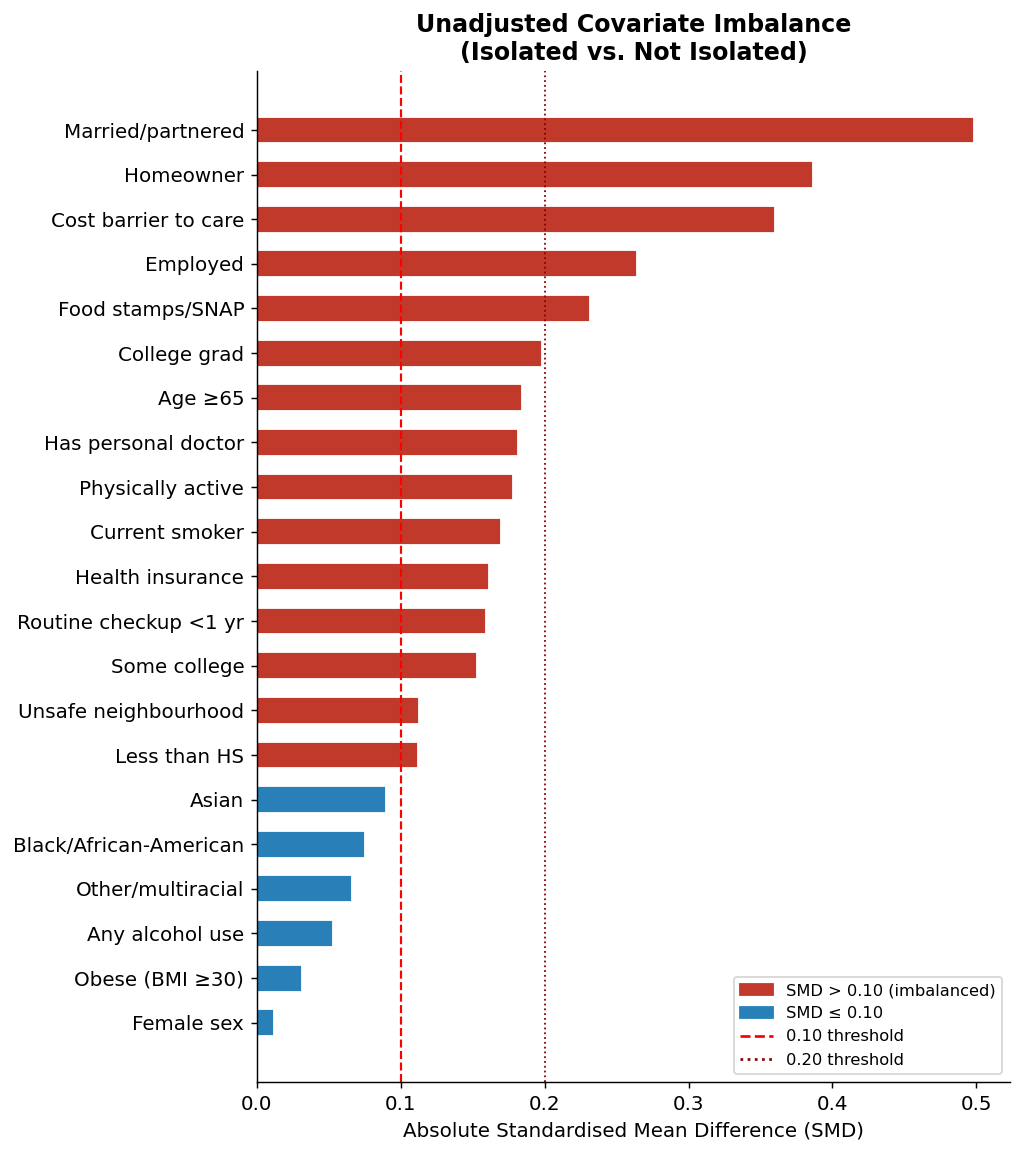

Saved: fig_love_plot_unadjusted.png


In [ ]:
# 7. Love plot (SMD) — unadjusted balance
print("\n── Generating SMD Love Plot …")

smd_data = []
for item in binary_vars_processed:
    label, var, val = item
    d = smd(df_imp[var], E, W)
    if not np.isnan(d):
        smd_data.append({"Variable": label.replace(" (%)", ""), "SMD": abs(d)})

conditional_vars_for_smd = []
if "income_num" in df_imp.columns:
    conditional_vars_for_smd.extend([(1,"Low income","income_num"), (2,"Mid income","income_num"), (3,"High income","income_num")])
if "edu_num" in df_imp.columns:
    conditional_vars_for_smd.extend([(1,"Less than HS","edu_num"), (2,"Some college","edu_num"), (3,"College grad","edu_num")])

for cat_val, lbl, var in conditional_vars_for_smd:
    tmp = (df_imp[var] == cat_val).astype(float)
    d = smd(tmp, E, W)
    if not np.isnan(d):
        smd_data.append({"Variable": lbl, "SMD": abs(d)})

smd_df = pd.DataFrame(smd_data).sort_values("SMD")

fig, ax = plt.subplots(figsize=(8, 9))
colors = ["#C0392B" if s > 0.1 else "#2980B9" for s in smd_df["SMD"]]
ax.barh(smd_df["Variable"], smd_df["SMD"], color=colors, edgecolor="white", height=0.6)
ax.axvline(0.1, color="red", linestyle="--", linewidth=1.2, label="SMD = 0.1 threshold")
ax.axvline(0.2, color="darkred", linestyle=":", linewidth=1, label="SMD = 0.2 (substantial)")
ax.set_xlabel("Absolute Standardised Mean Difference (SMD)", fontsize=11)
ax.set_title("Unadjusted Covariate Imbalance\n(Isolated vs. Not Isolated)", fontweight="bold")
ax.legend(fontsize=9)
red_patch = mpatches.Patch(color="#C0392B", label="SMD > 0.10 (imbalanced)")
blue_patch = mpatches.Patch(color="#2980B9", label="SMD ≤ 0.10 (balanced)")
ax.legend(handles=[red_patch, blue_patch,
                   plt.Line2D([0],[0], color="red", ls="--"),
                   plt.Line2D([0],[0], color="darkred", ls=":")],
          labels=["SMD > 0.10 (imbalanced)","SMD ≤ 0.10",
                  "0.10 threshold","0.20 threshold"], fontsize=9)
plt.tight_layout()
plt.savefig("fig_love_plot_unadjusted.png", bbox_inches="tight")
plt.show()
print("Saved: fig_love_plot_unadjusted.png")


── Generating EDA figures …


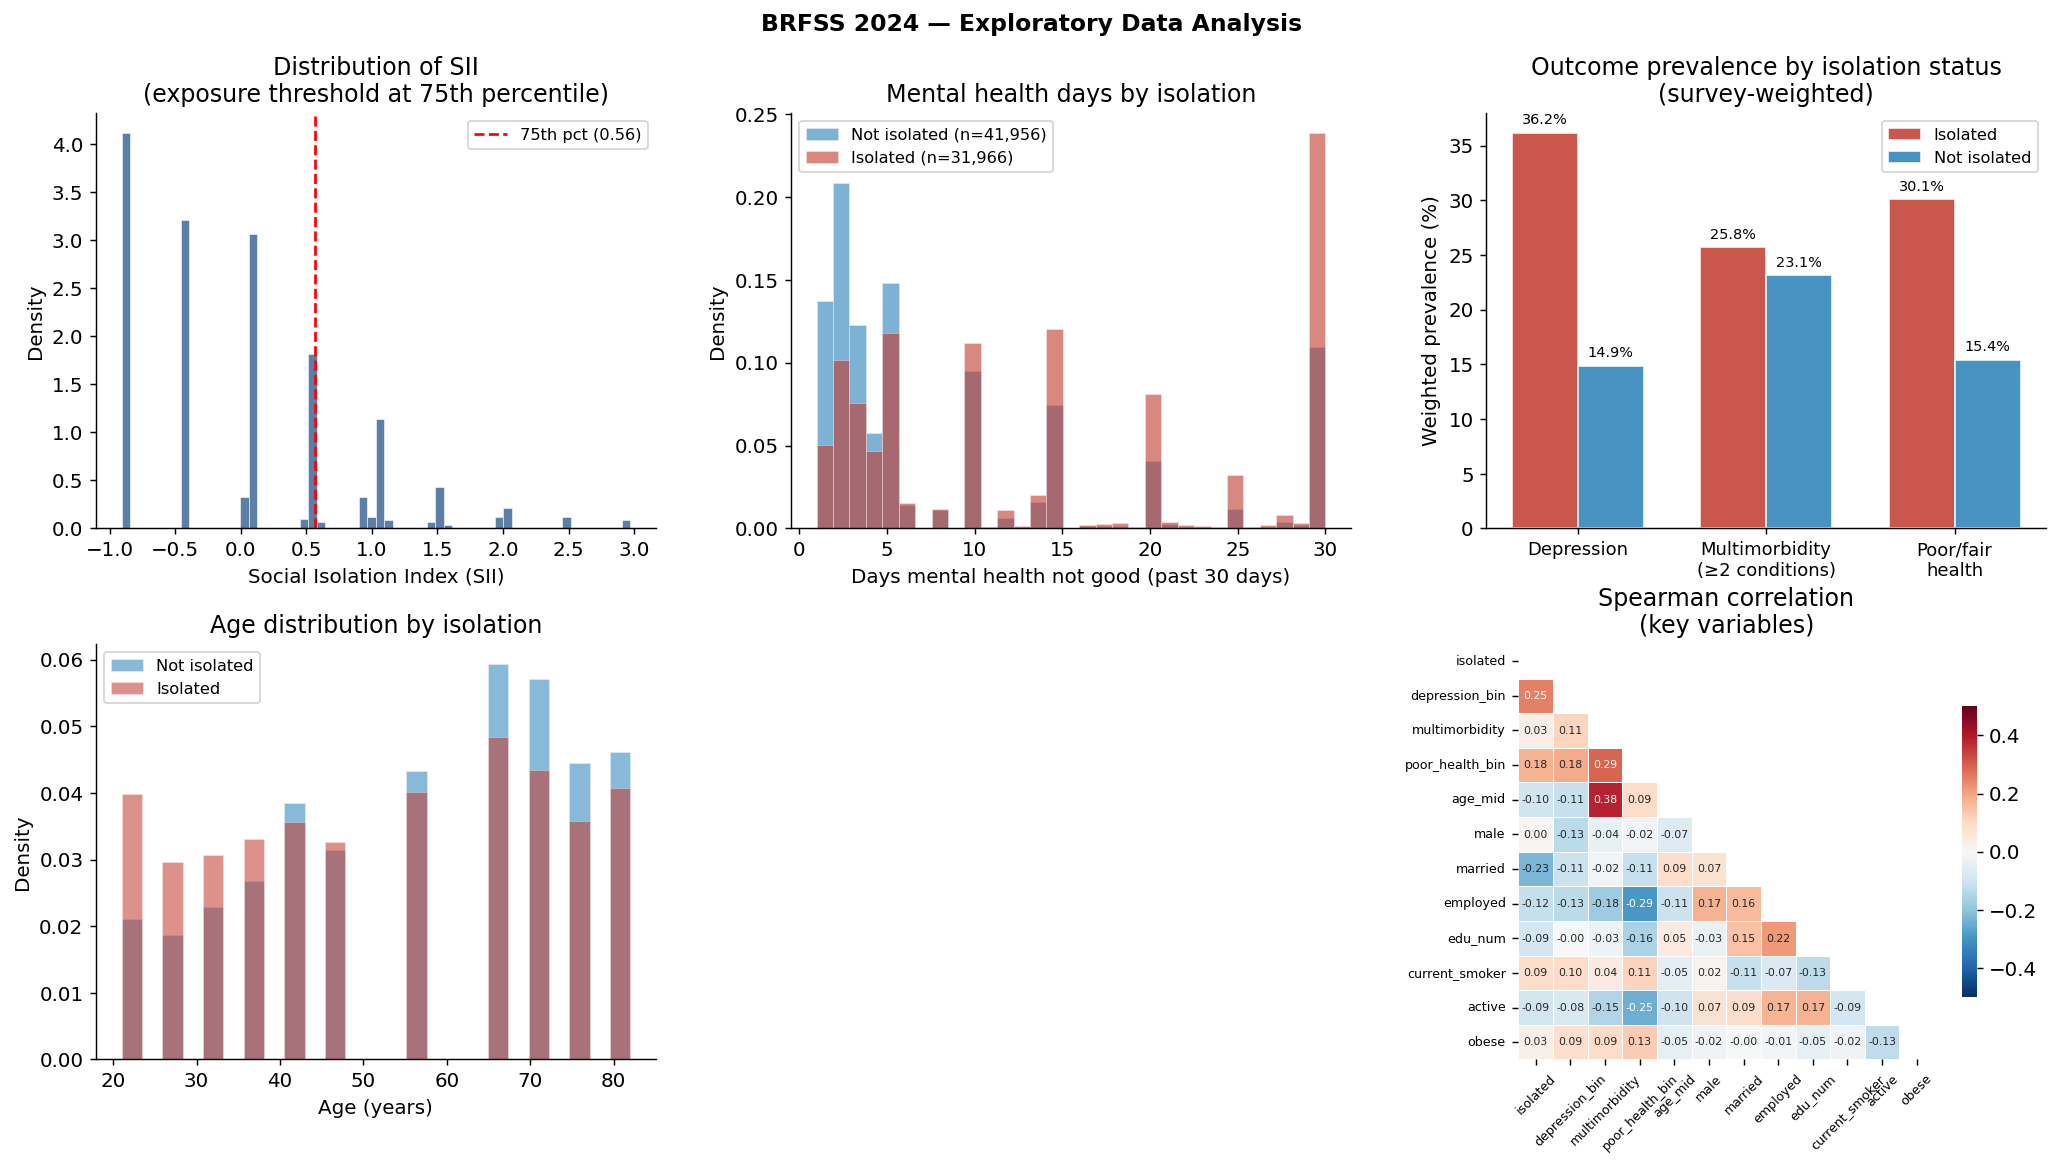

Saved: fig_eda.png


In [ ]:
# 8. EDA — Key distributions
print("\n── Generating EDA figures …")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 8a. Social Isolation Index distribution
ax = axes[0, 0]
sii_vals = df["sii_raw"].dropna()
ax.hist(sii_vals, bins=60, color="#5B7FA6", edgecolor="white", linewidth=0.3, density=True)
q75 = sii_vals.quantile(0.75)
ax.axvline(q75, color="red", linestyle="--", linewidth=1.5, label=f"75th pct ({q75:.2f})")
ax.set_xlabel("Social Isolation Index (SII)")
ax.set_ylabel("Density")
ax.set_title("Distribution of SII\n(exposure threshold at 75th percentile)")
ax.legend(fontsize=9)

# 8b. Bad mental health days by isolation status
ax = axes[0, 1]
for val, lbl, col in [(0,"Not isolated","#2980B9"), (1,"Isolated","#C0392B")]:

    sub = df.loc[df_imp[EXPOSURE] == val, "bad_mental_days"].dropna()

    sub = sub.clip(0, 30)
    ax.hist(sub, bins=31, alpha=0.6, density=True, color=col, edgecolor="white",
            linewidth=0.3, label=f"{lbl} (n={len(sub):,})")
ax.set_xlabel("Days mental health not good (past 30 days)")
ax.set_ylabel("Density")
ax.set_title("Mental health days by isolation")
ax.legend(fontsize=9)

# 8c. Outcome prevalence bar chart (weighted)
ax = axes[0, 2]
out_labels = ["Depression", "Multimorbidity\n(≥2 conditions)", "Poor/fair\nhealth"]
out_vars   = ["depression_bin", "multimorbidity", "poor_health_bin"]
colors_iso = ["#C0392B", "#2980B9"]
x = np.arange(len(out_labels))
width = 0.35

for i, (val, lbl, col) in enumerate([(1,"Isolated","#C0392B"),(0,"Not isolated","#2980B9")]):
    pcts = [wtd_pct(df_imp.loc[df_imp[EXPOSURE]==val, v], W[df_imp[EXPOSURE]==val], 1.0)
            for v in out_vars]
    bars = ax.bar(x + (i-0.5)*width, pcts, width, label=lbl, color=col, alpha=0.85,
                  edgecolor="white")
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x); ax.set_xticklabels(out_labels, fontsize=10)
ax.set_ylabel("Weighted prevalence (%)")
ax.set_title("Outcome prevalence by isolation status\n(survey-weighted)")
ax.legend(fontsize=9)

# 8d. Age distribution by isolation
ax = axes[1, 0]
for val, lbl, col in [(0,"Not isolated","#2980B9"),(1,"Isolated","#C0392B")]:
    sub = df_imp.loc[df_imp[EXPOSURE]==val, "age_mid"].dropna()
    ax.hist(sub, bins=25, alpha=0.55, density=True, color=col,
            edgecolor="white", linewidth=0.3, label=lbl)
ax.set_xlabel("Age (years)")
ax.set_ylabel("Density")
ax.set_title("Age distribution by isolation")
ax.legend(fontsize=9)

# 8e. Isolation prevalence by income category
ax = axes[1, 1]
if "income_num" in df_imp.columns:
    income_labels = {1: "Low", 2: "Mid", 3: "High"}
    inc_pcts = []
    for cat in [1, 2, 3]:
        sub = df_imp[df_imp["income_num"] == cat]
        p = wtd_pct(sub[EXPOSURE], W[sub.index], 1.0)
        inc_pcts.append(p)
    bars = ax.bar(["Low", "Mid", "High"], inc_pcts,
                  color=["#C0392B","#E67E22","#27AE60"], alpha=0.85, edgecolor="white")
    for bar, p in zip(bars, inc_pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{p:.1f}%", ha="center", va="bottom", fontsize=10)
    ax.set_xlabel("Income category")
    ax.set_ylabel("% Socially isolated (weighted)")
    ax.set_title("Social isolation prevalence\nby income category")
else:
    ax.set_visible(False)

# 8f. Correlation heatmap (Spearman, analytic variables)
ax = axes[1, 2]
corr_vars = ["isolated", "depression_bin", "multimorbidity", "poor_health_bin",
             "age_mid", "male", "married", "employed", "edu_num"]
if "income_num" in df_imp.columns:
    corr_vars.append("income_num")
corr_vars.extend(["current_smoker", "active", "obese"])
corr_vars = [v for v in corr_vars if v in df_imp.columns]
corr_mat = df_imp[corr_vars].corr(method="spearman")
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, ax=ax, cmap="RdBu_r", center=0,
            vmin=-0.5, vmax=0.5, annot=True, fmt=".2f", annot_kws={"size": 6},
            linewidths=0.3, square=True, cbar_kws={"shrink": 0.7})
ax.set_title("Spearman correlation\n(key variables)")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.tick_params(axis="y", labelsize=7)

plt.suptitle("BRFSS 2024 — Exploratory Data Analysis", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("fig_eda.png", bbox_inches="tight")
plt.show()
print("Saved: fig_eda.png")

In [ ]:
# 9. Weighted outcome prevalence ratio (crude, pre-adjustment)
print("\n── Crude (unadjusted) weighted prevalence ratios ──")

for out_lbl, out_var in [
        ("Depression",           "depression_bin"),
        ("Multimorbidity",       "multimorbidity"),
        ("Poor/fair health",     "poor_health_bin")]:

    p1 = wtd_pct(df_imp.loc[iso1, out_var], W[iso1], 1.0) / 100
    p0 = wtd_pct(df_imp.loc[iso0, out_var], W[iso0], 1.0) / 100

    pr = p1 / p0  if p0 > 0 else np.nan
    or_ = (p1/(1-p1)) / (p0/(1-p0)) if (p0 > 0 and p0 < 1 and p1 < 1) else np.nan

    print(f"  {out_lbl:30s}  Prev(isolated)={p1:.3f}  Prev(control)={p0:.3f}  "
          f"PR={pr:.3f}  OR={or_:.3f}")


── Crude (unadjusted) weighted prevalence ratios ──
  Depression                      Prev(isolated)=0.362  Prev(control)=0.149  PR=2.431  OR=3.243
  Multimorbidity                  Prev(isolated)=0.258  Prev(control)=0.231  PR=1.114  OR=1.153
  Poor/fair health                Prev(isolated)=0.301  Prev(control)=0.154  PR=1.953  OR=2.364


In [ ]:
# 10. Save primary imputed dataset
df_imp_save = df_imp.copy()
df_imp_save["survey_weight"] = df["survey_weight"].values
df_imp_save["stratum"]       = df["stratum"].values
df_imp_save["psu"]           = df["psu"].values

df_imp_save.to_parquet("brfss_analytic_stage2.parquet", index=False)
print("\n✓  Stage 2 complete.")
print("   Saved: brfss_analytic_stage2.parquet")
print("   Saved: imputed_datasets.pkl")
print("   Saved: table1_weighted.csv, fig_eda.png, fig_love_plot_unadjusted.png, fig_mice_convergence.png")


✓  Stage 2 complete.
   Saved: brfss_analytic_stage2.parquet
   Saved: imputed_datasets.pkl
   Saved: table1_weighted.csv, fig_eda.png, fig_love_plot_unadjusted.png, fig_mice_convergence.png


In [ ]:
del df_mice_input
del imputed_datasets
del kernel
gc.collect()

29101

In [ ]:
# ==========================================================================================================
#  BRFSS 2024 | STAGE 3 — DAG Specification, Propensity Score Estimation, IPTW Weights & Balance Diagnostics
# ==========================================================================================================


In [ ]:
# 0. Dependencies
!pip install -q scikit-learn statsmodels matplotlib seaborn numpy pandas

import warnings
warnings.filterwarnings("ignore")

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import calibration_curve
import statsmodels.formula.api as smf
import statsmodels.api as sm

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
SEED = 42
np.random.seed(SEED)

In [ ]:
# 1. Load Stage 2 imputed dataset
df = pd.read_parquet("brfss_analytic_stage2.parquet")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")

EXPOSURE = "isolated"
OUTCOMES = ["depression_bin", "multimorbidity", "poor_health_bin"]
W        = df["survey_weight"]

Loaded: 199,740 rows × 29 cols


In [ ]:
# 2. Near-zero variance check — auto-exclude flat variables
print("\n── Near-zero variance check on confounders …")

CANDIDATE_CONFOUNDERS = [
    "male", "age_mid", "age65plus",
    "black", "hispanic", "asian", "other_race",
    "married", "homeowner", "employed",
    "edu_num", "current_smoker", "active",
    "obese", "drinks_alcohol",
    "has_doctor_bin", "insured", "cost_barrier_bin", "checkup_recent",
    "food_stamps_bin", "bills_hardship", "unsafe_neighbourhood",
]

if "edu_num" not in df.columns and "edu_cat" in df.columns:
    df["edu_num"] = df["edu_cat"].map(
        {"less_than_hs": 1, "some_college": 2, "college_plus": 3})

CONFOUNDERS = []
excluded_nzv = []
for c in CANDIDATE_CONFOUNDERS:
    if c not in df.columns:
        excluded_nzv.append(f"{c} (not in dataset)")
        continue
    col_var = df[c].var()
    if col_var < 0.0005 or df[c].nunique() < 2:
        excluded_nzv.append(f"{c} (variance={col_var:.6f})")
    else:
        CONFOUNDERS.append(c)

if excluded_nzv:
    print(f"  Excluded (near-zero variance): {excluded_nzv}")
print(f"  Final PS confounder set ({len(CONFOUNDERS)}): {CONFOUNDERS}")


── Near-zero variance check on confounders …
  Excluded (near-zero variance): ['hispanic (variance=0.000000)', 'bills_hardship (variance=0.000000)']
  Final PS confounder set (20): ['male', 'age_mid', 'age65plus', 'black', 'asian', 'other_race', 'married', 'homeowner', 'employed', 'edu_num', 'current_smoker', 'active', 'obese', 'drinks_alcohol', 'has_doctor_bin', 'insured', 'cost_barrier_bin', 'checkup_recent', 'food_stamps_bin', 'unsafe_neighbourhood']


In [ ]:
# 3. Prepare design matrix

#Interaction terms grounded in the DAG:
#age × married  : social isolation pathway differs by life stage + partnership
#age × employed : labour force exit is a major isolation mechanism for older adults
#age × insured  : healthcare-mediated pathway differs by age


df_ps = df[[EXPOSURE] + CONFOUNDERS + OUTCOMES + ["survey_weight","stratum","psu"]].copy()

n_miss_ps = df_ps[CONFOUNDERS].isnull().sum().sum()
print(f"\n  Missing values in PS covariates after imputation: {n_miss_ps}")

df_ps["age_x_married"]  = df_ps["age_mid"] * df_ps["married"]
df_ps["age_x_employed"] = df_ps["age_mid"] * df_ps["employed"]
df_ps["age_x_insured"]  = df_ps["age_mid"] * df_ps["insured"]

CONFOUNDERS_EXT = CONFOUNDERS + ["age_x_married", "age_x_employed", "age_x_insured"]

scaler = StandardScaler()
X_raw = df_ps[CONFOUNDERS_EXT].values.astype(float)
X     = scaler.fit_transform(X_raw)
y     = df_ps[EXPOSURE].values.astype(float)
sw    = W.values


  Missing values in PS covariates after imputation: 0


In [ ]:
# 4. Propensity Score Model

print("\n── Fitting propensity score model (logistic regression) …")

ps_model = LogisticRegression(
    penalty="l2", C=1.0, solver="lbfgs",
    max_iter=2000, random_state=SEED
)
ps_model.fit(X, y, sample_weight=sw)

ps_scores = ps_model.predict_proba(X)[:, 1]
df_ps["ps"] = ps_scores

auc    = roc_auc_score(y, ps_scores, sample_weight=sw)
brier  = brier_score_loss(y, ps_scores, sample_weight=sw)
print(f"  PS model AUC (weighted)   : {auc:.4f}")
print(f"  PS model Brier score      : {brier:.4f}")
print(f"  PS mean (isolated=1)      : {ps_scores[y==1].mean():.4f}")
print(f"  PS mean (isolated=0)      : {ps_scores[y==0].mean():.4f}")

coef_df = pd.DataFrame({
    "Variable"   : CONFOUNDERS_EXT,
    "Coefficient": ps_model.coef_[0],
    "Odds Ratio" : np.exp(ps_model.coef_[0])
}).sort_values("Coefficient", key=abs, ascending=False)
print("\n  PS Model Coefficients (top 15 by |coef|):")
print(coef_df.head(15).to_string(index=False))
coef_df.to_csv("ps_model_coefficients.csv", index=False)


── Fitting propensity score model (logistic regression) …
  PS model AUC (weighted)   : 0.6905
  PS model Brier score      : 0.1870
  PS mean (isolated=1)      : 0.3414
  PS mean (isolated=0)      : 0.2469

  PS Model Coefficients (top 15 by |coef|):
            Variable  Coefficient  Odds Ratio
             married      -0.3749      0.6873
    cost_barrier_bin       0.2317      1.2607
       age_x_insured      -0.1522      0.8588
           homeowner      -0.1159      0.8906
              active      -0.1154      0.8910
      age_x_employed      -0.1113      0.8946
             age_mid       0.0910      1.0953
      current_smoker       0.0806      1.0839
             insured       0.0789      1.0821
               asian       0.0689      1.0713
            employed      -0.0672      0.9350
unsafe_neighbourhood       0.0575      1.0592
     food_stamps_bin       0.0557      1.0572
                male       0.0554      1.0569
      checkup_recent      -0.0434      0.9576


In [ ]:
# 5. Positivity / Overlap Check
print("\n── Checking positivity assumption …")

ps1 = ps_scores[y == 1]
ps0 = ps_scores[y == 0]

print(f"  PS range (isolated=1) : [{ps1.min():.4f}, {ps1.max():.4f}]")
print(f"  PS range (isolated=0) : [{ps0.min():.4f}, {ps0.max():.4f}]")
print(f"  PS < 0.05 (isolated=1): {(ps1 < 0.05).mean()*100:.2f}%")
print(f"  PS > 0.95 (isolated=1): {(ps1 > 0.95).mean()*100:.2f}%")
print(f"  PS < 0.05 (isolated=0): {(ps0 < 0.05).mean()*100:.2f}%")
print(f"  PS > 0.95 (isolated=0): {(ps0 > 0.95).mean()*100:.2f}%")


── Checking positivity assumption …
  PS range (isolated=1) : [0.1043, 0.8828]
  PS range (isolated=0) : [0.1043, 0.8748]
  PS < 0.05 (isolated=1): 0.00%
  PS > 0.95 (isolated=1): 0.00%
  PS < 0.05 (isolated=0): 0.00%
  PS > 0.95 (isolated=0): 0.00%


In [ ]:
# 6. Compute Stabilised IPTW Weights

print("\n── Computing stabilised IPTW weights …")

p_treated   = y.mean()
p_untreated = 1 - p_treated

iptw = np.where(
    y == 1,
    p_treated   / ps_scores,
    p_untreated / (1 - ps_scores)
)

df_ps["iptw_raw"]   = iptw

# 6a. Weight trimming at 1st / 99th percentile
p01 = np.percentile(iptw, 1)
p99 = np.percentile(iptw, 99)
iptw_trimmed = np.clip(iptw, p01, p99)
df_ps["iptw_trimmed"] = iptw_trimmed

# 6b. Combine IPTW × survey weight (for population inference)
def renorm(w, a, trt_val):
    idx = a == trt_val
    w_sub = w[idx]
    return w_sub / w_sub.mean()

iptw_norm = iptw_trimmed.copy()
iptw_norm[y == 1] = renorm(iptw_trimmed, y, 1)
iptw_norm[y == 0] = renorm(iptw_trimmed, y, 0)

df_ps["iptw_norm"]  = iptw_norm
df_ps["combined_w"] = iptw_norm * df_ps["survey_weight"]

print(f"  Raw IPTW    — mean: {iptw.mean():.4f}, max: {iptw.max():.4f}, "
      f"SD: {iptw.std():.4f}")
print(f"  Trimmed IPTW — 1st pct={p01:.4f}, 99th pct={p99:.4f}")
print(f"  Trimmed IPTW — mean: {iptw_trimmed.mean():.4f}, "
      f"SD: {iptw_trimmed.std():.4f}")

ess_trt  = (iptw_trimmed[y==1].sum())**2 / (iptw_trimmed[y==1]**2).sum()
ess_ctrl = (iptw_trimmed[y==0].sum())**2 / (iptw_trimmed[y==0]**2).sum()
print(f"\n  Effective sample size (treated) : {ess_trt:,.0f}  "
      f"(original n={int(y.sum()):,})")
print(f"  Effective sample size (control) : {ess_ctrl:,.0f}  "
      f"(original n={int((1-y).sum()):,})")


── Computing stabilised IPTW weights …
  Raw IPTW    — mean: 0.9951, max: 5.8439, SD: 0.3117
  Trimmed IPTW — 1st pct=0.4167, 99th pct=2.1360
  Trimmed IPTW — mean: 0.9933, SD: 0.3011

  Effective sample size (treated) : 43,645  (original n=53,626)
  Effective sample size (control) : 139,833  (original n=146,114)


In [ ]:
# 7. Post-weighting SMD — assess balance
print("\n── Computing post-IPTW standardised mean differences …")

def wtd_mean_smd(x, w):
    mask = ~np.isnan(x) & ~np.isnan(w)
    return np.average(x[mask], weights=w[mask])

def wtd_smd_post(var_name, trt_arr, wt_arr):
    x = df_ps[var_name].values.astype(float)
    mask = ~np.isnan(x)
    x1 = x[mask & (trt_arr == 1)];  w1 = wt_arr[mask & (trt_arr == 1)]
    x0 = x[mask & (trt_arr == 0)];  w0 = wt_arr[mask & (trt_arr == 0)]
    if len(w1) == 0 or len(w0) == 0:
        return np.nan
    m1 = np.average(x1, weights=w1)
    m0 = np.average(x0, weights=w0)
    v1 = np.average((x1 - m1)**2, weights=w1)
    v0 = np.average((x0 - m0)**2, weights=w0)
    denom = np.sqrt((v1 + v0) / 2)
    return (m1 - m0) / denom if denom > 0 else np.nan

def unadj_smd(var_name):
    x = df_ps[var_name].values.astype(float)
    sw_ = df_ps["survey_weight"].values
    mask = ~np.isnan(x)
    x1 = x[mask & (y==1)]; w1 = sw_[mask & (y==1)]
    x0 = x[mask & (y==0)]; w0 = sw_[mask & (y==0)]
    if len(w1)==0 or len(w0)==0: return np.nan
    m1 = np.average(x1,weights=w1); m0 = np.average(x0,weights=w0)
    v1 = np.average((x1-m1)**2,weights=w1)
    v0 = np.average((x0-m0)**2,weights=w0)
    d  = np.sqrt((v1+v0)/2)
    return (m1-m0)/d if d>0 else np.nan

BALANCE_VARS = [v for v in CONFOUNDERS if v not in ("age65plus",)]

smd_records = []
for v in BALANCE_VARS:
    if v not in df_ps.columns:
        continue
    pre  = abs(unadj_smd(v))
    post = abs(wtd_smd_post(v, y, iptw_trimmed))
    smd_records.append({"Variable": v, "Pre_IPTW": pre, "Post_IPTW": post})

smd_balance = pd.DataFrame(smd_records).dropna()
smd_balance.to_csv("smd_balance.csv", index=False)

n_imbalanced_pre  = (smd_balance["Pre_IPTW"]  > 0.10).sum()
n_imbalanced_post = (smd_balance["Post_IPTW"] > 0.10).sum()
print(f"  Variables with SMD>0.10 — Before IPTW: {n_imbalanced_pre}, "
      f"After IPTW: {n_imbalanced_post}")
print(f"  Max post-IPTW SMD: {smd_balance['Post_IPTW'].max():.4f}")
print(f"  Mean post-IPTW SMD: {smd_balance['Post_IPTW'].mean():.4f}")
print(smd_balance.sort_values("Post_IPTW", ascending=False).to_string(index=False))


── Computing post-IPTW standardised mean differences …
  Variables with SMD>0.10 — Before IPTW: 13, After IPTW: 0
  Max post-IPTW SMD: 0.0567
  Mean post-IPTW SMD: 0.0202
            Variable  Pre_IPTW  Post_IPTW
             married    0.4985     0.0567
      drinks_alcohol    0.0528     0.0490
              active    0.1780     0.0326
           homeowner    0.3863     0.0321
    cost_barrier_bin    0.3604     0.0293
      has_doctor_bin    0.1817     0.0280
             age_mid    0.2605     0.0246
             insured    0.1612     0.0204
               obese    0.0315     0.0175
             edu_num    0.2066     0.0164
            employed    0.2642     0.0144
     food_stamps_bin    0.2314     0.0127
      checkup_recent    0.1593     0.0116
          other_race    0.0659     0.0106
               black    0.0754     0.0104
               asian    0.0895     0.0081
unsafe_neighbourhood    0.1124     0.0055
                male    0.0120     0.0023
      current_smoker    0.1700

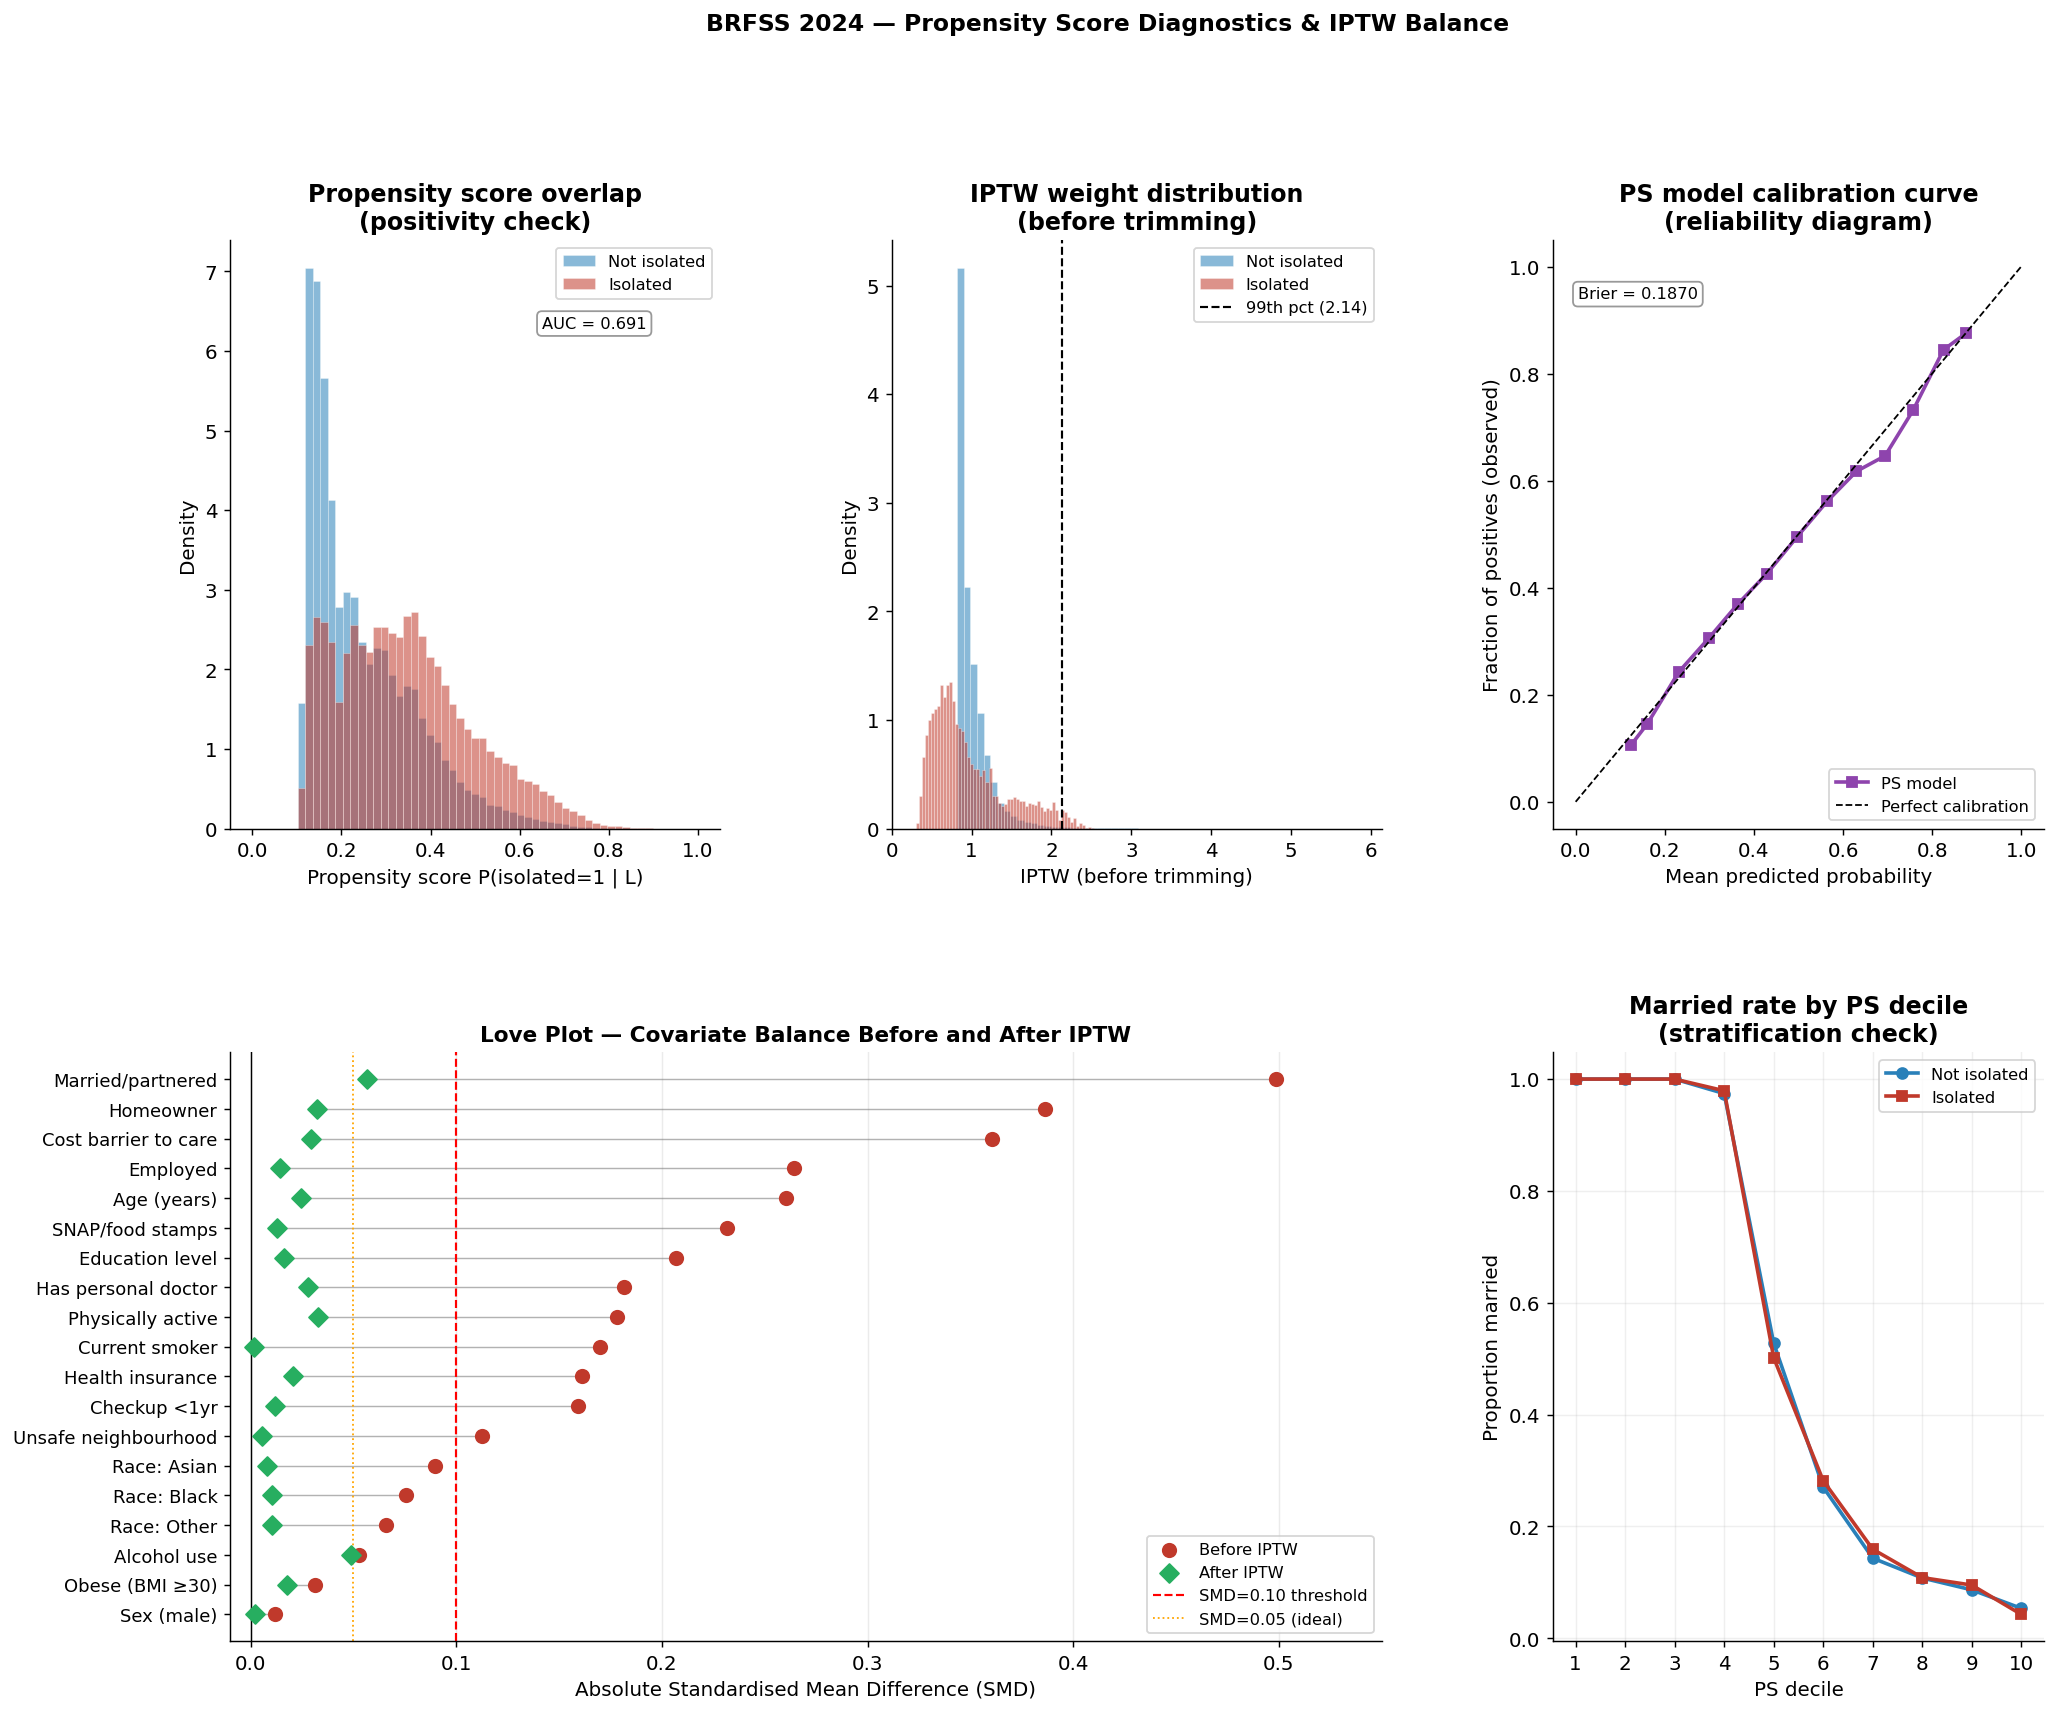

Saved: fig_ps_diagnostics.png


In [ ]:
# 8. Final figures of currect stage

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.38, wspace=0.35)

# Fig 8a: PS Overlap (density)
ax1 = fig.add_subplot(gs[0, 0])
bins_ = np.linspace(0, 1, 60)
ax1.hist(ps0, bins=bins_, alpha=0.55, density=True,
         color="#2980B9", edgecolor="white", linewidth=0.3, label="Not isolated")
ax1.hist(ps1, bins=bins_, alpha=0.55, density=True,
         color="#C0392B", edgecolor="white", linewidth=0.3, label="Isolated")
ax1.set_xlabel("Propensity score P(isolated=1 | L)")
ax1.set_ylabel("Density")
ax1.set_title("Propensity score overlap\n(positivity check)", fontweight="bold")
ax1.legend(fontsize=9)
ax1.text(0.65, ax1.get_ylim()[1]*0.85, f"AUC = {auc:.3f}", fontsize=9,
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Fig 8b: IPTW distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(iptw[y==0], bins=60, alpha=0.55, density=True,
         color="#2980B9", edgecolor="white", linewidth=0.3, label="Not isolated")
ax2.hist(iptw[y==1], bins=60, alpha=0.55, density=True,
         color="#C0392B", edgecolor="white", linewidth=0.3, label="Isolated")
ax2.axvline(p99, color="black", linestyle="--", linewidth=1.2, label=f"99th pct ({p99:.2f})")
ax2.set_xlabel("IPTW (before trimming)")
ax2.set_ylabel("Density")
ax2.set_title("IPTW weight distribution\n(before trimming)", fontweight="bold")
ax2.legend(fontsize=9)
ax2.set_xlim(0, min(iptw.max()*1.05, 15))

# Fig 8c: Calibration curve of PS model
ax3 = fig.add_subplot(gs[0, 2])
frac_pos, mean_pred = calibration_curve(y, ps_scores, n_bins=15, strategy="uniform")
ax3.plot(mean_pred, frac_pos, "s-", color="#8E44AD", linewidth=2,
         markersize=5, label="PS model")
ax3.plot([0, 1], [0, 1], "k--", linewidth=1, label="Perfect calibration")
ax3.set_xlabel("Mean predicted probability")
ax3.set_ylabel("Fraction of positives (observed)")
ax3.set_title("PS model calibration curve\n(reliability diagram)", fontweight="bold")
ax3.legend(fontsize=9)
ax3.text(0.05, 0.90, f"Brier = {brier:.4f}", fontsize=9, transform=ax3.transAxes,
         bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8))

# Fig 8d: Love plot — Pre vs Post IPTW SMD
ax4 = fig.add_subplot(gs[1, :2])
smd_plot = smd_balance.sort_values("Pre_IPTW", ascending=True)

var_labels = {
    "male": "Sex (male)", "age_mid": "Age (years)", "black": "Race: Black",
    "asian": "Race: Asian", "other_race": "Race: Other",
    "married": "Married/partnered", "homeowner": "Homeowner",
    "employed": "Employed", "edu_num": "Education level",
    "current_smoker": "Current smoker", "active": "Physically active",
    "obese": "Obese (BMI ≥30)", "drinks_alcohol": "Alcohol use",
    "has_doctor_bin": "Has personal doctor", "insured": "Health insurance",
    "cost_barrier_bin": "Cost barrier to care", "checkup_recent": "Checkup <1yr",
    "food_stamps_bin": "SNAP/food stamps", "unsafe_neighbourhood": "Unsafe neighbourhood",
}
y_labels = [var_labels.get(v, v) for v in smd_plot["Variable"]]
y_pos     = np.arange(len(y_labels))

ax4.scatter(smd_plot["Pre_IPTW"],  y_pos, color="#C0392B", zorder=3,
            s=55, label="Before IPTW", marker="o")
ax4.scatter(smd_plot["Post_IPTW"], y_pos, color="#27AE60", zorder=3,
            s=55, label="After IPTW",  marker="D")

for i, (pre, post) in enumerate(zip(smd_plot["Pre_IPTW"], smd_plot["Post_IPTW"])):
    ax4.plot([pre, post], [i, i], color="gray", linewidth=0.8, alpha=0.6, zorder=2)

ax4.axvline(0.10, color="red",    linestyle="--", linewidth=1.2, label="SMD=0.10 threshold")
ax4.axvline(0.05, color="orange", linestyle=":",  linewidth=1.0, label="SMD=0.05 (ideal)")
ax4.axvline(0.0,  color="black",  linewidth=0.8)
ax4.set_yticks(y_pos)
ax4.set_yticklabels(y_labels, fontsize=10)
ax4.set_xlabel("Absolute Standardised Mean Difference (SMD)", fontsize=11)
ax4.set_title("Love Plot — Covariate Balance Before and After IPTW",
              fontweight="bold", fontsize=12)
ax4.legend(fontsize=9, loc="lower right")
ax4.set_xlim(-0.01, max(smd_plot["Pre_IPTW"].max() * 1.1, 0.55))
ax4.grid(axis="x", alpha=0.25)

# Fig 8e: PS by decile (balance check)
ax5 = fig.add_subplot(gs[1, 2])
df_ps["ps_decile"] = pd.qcut(df_ps["ps"], q=10, labels=False, duplicates="drop") + 1
decile_balance = df_ps.groupby(["ps_decile", EXPOSURE])["married"].mean().unstack()
if 0.0 in decile_balance.columns and 1.0 in decile_balance.columns:
    ax5.plot(decile_balance.index, decile_balance[0.0], "o-",
             color="#2980B9", label="Not isolated", linewidth=2)
    ax5.plot(decile_balance.index, decile_balance[1.0], "s-",
             color="#C0392B", label="Isolated", linewidth=2)
    ax5.set_xlabel("PS decile")
    ax5.set_ylabel("Proportion married")
    ax5.set_title("Married rate by PS decile\n(stratification check)", fontweight="bold")
    ax5.legend(fontsize=9)
    ax5.set_xticks(range(1, 11))
    ax5.grid(alpha=0.2)

plt.suptitle("BRFSS 2024 — Propensity Score Diagnostics & IPTW Balance",
             fontweight="bold", fontsize=13, y=1.005)
plt.savefig("fig_ps_diagnostics.png", bbox_inches="tight")
plt.show()
print("Saved: fig_ps_diagnostics.png")

In [ ]:
# 9. Positivity summary table
print("\n── Positivity diagnostic table ──")
ps_summary = pd.DataFrame({
    "Group"     : ["Isolated (A=1)", "Not isolated (A=0)", "Full sample"],
    "N"         : [int(y.sum()), int((1-y).sum()), len(y)],
    "PS_mean"   : [ps1.mean(), ps0.mean(), ps_scores.mean()],
    "PS_median" : [np.median(ps1), np.median(ps0), np.median(ps_scores)],
    "PS_p10"    : [np.percentile(ps1,10), np.percentile(ps0,10),
                   np.percentile(ps_scores,10)],
    "PS_p90"    : [np.percentile(ps1,90), np.percentile(ps0,90),
                   np.percentile(ps_scores,90)],
    "IPTW_mean" : [iptw_trimmed[y==1].mean(), iptw_trimmed[y==0].mean(),
                   iptw_trimmed.mean()],
    "ESS"       : [f"{ess_trt:,.0f}", f"{ess_ctrl:,.0f}", "—"]
}).round(4)
print(ps_summary.to_string(index=False))
ps_summary.to_csv("ps_positivity_summary.csv", index=False)


── Positivity diagnostic table ──
             Group      N  PS_mean  PS_median  PS_p10  PS_p90  IPTW_mean     ESS
    Isolated (A=1)  53626   0.3414     0.3272  0.1542  0.5540     0.9660  43,645
Not isolated (A=0) 146114   0.2469     0.2123  0.1297  0.4163     1.0032 139,833
       Full sample 199740   0.2723     0.2386  0.1328  0.4611     0.9933       —


In [ ]:
# 10. Save enriched dataset for Stage 4
df_ps.to_parquet("brfss_analytic_stage3.parquet", index=False)

with open("imputed_datasets.pkl", "rb") as f:
    imputed_datasets = pickle.load(f)

updated_datasets = []
for i, imp in enumerate(imputed_datasets):

    if "edu_num" not in imp.columns and "edu_cat" in imp.columns:
        imp["edu_num"] = imp["edu_cat"].map(
            {"less_than_hs": 1, "some_college": 2, "college_plus": 3})

    imp_conf = [c for c in CONFOUNDERS_EXT
                if c.replace("age_x_married","").replace("age_x_employed","")
                   .replace("age_x_insured","") not in ("",) ]


    imp_work = imp.copy()
    imp_work["age_x_married"]  = imp_work.get("age_mid", pd.Series(0)) * \
                                  imp_work.get("married",  pd.Series(0))
    imp_work["age_x_employed"] = imp_work.get("age_mid", pd.Series(0)) * \
                                  imp_work.get("employed", pd.Series(0))
    imp_work["age_x_insured"]  = imp_work.get("age_mid", pd.Series(0)) * \
                                  imp_work.get("insured",  pd.Series(0))

    imp_conf_cols = [c for c in CONFOUNDERS_EXT if c in imp_work.columns]
    X_imp = scaler.transform(imp_work[imp_conf_cols].fillna(0).values.astype(float))
    ps_imp = ps_model.predict_proba(X_imp)[:, 1]

    y_imp  = imp[EXPOSURE].values.astype(float)
    iptw_imp = np.where(
        y_imp == 1,
        y_imp.mean()       / ps_imp,
        (1 - y_imp.mean()) / (1 - ps_imp)
    )
    p01_i, p99_i = np.percentile(iptw_imp, 1), np.percentile(iptw_imp, 99)
    imp["ps"]           = ps_imp
    imp["iptw_trimmed"] = np.clip(iptw_imp, p01_i, p99_i)
    imp["survey_weight"]= df["survey_weight"].values
    imp["stratum"]      = df["stratum"].values
    imp["psu"]          = df["psu"].values
    updated_datasets.append(imp)

with open("imputed_datasets_stage3.pkl", "wb") as f:
    pickle.dump(updated_datasets, f)

print("\n✓  Stage 3 complete.")
print(f"   Saved: brfss_analytic_stage3.parquet")
print(f"   Saved: imputed_datasets_stage3.pkl  (all 5 with PS + IPTW)")
print(f"   Saved: fig_ps_diagnostics.png, smd_balance.csv, ps_model_coefficients.csv")


✓  Stage 3 complete.
   Saved: brfss_analytic_stage3.parquet
   Saved: imputed_datasets_stage3.pkl  (all 5 with PS + IPTW)
   Saved: fig_ps_diagnostics.png, smd_balance.csv, ps_model_coefficients.csv


In [ ]:
import gc

def clear_df_memory():
    to_delete = []

    for name, obj in globals().items():
        if isinstance(obj, pd.DataFrame):
            to_delete.append(name)

    for name in to_delete:
        del globals()[name]

    gc.collect()
    print(f"Cleared {len(to_delete)} DataFrames from memory.")

clear_df_memory()

Cleared 19 DataFrames from memory.


In [ ]:
import gc
import ctypes
import matplotlib.pyplot as plt
from IPython import get_ipython


plt.close('all')

ip = get_ipython()
if ip is not None:
    for k in ['Out', '_oh']:
        if k in ip.user_ns and hasattr(ip.user_ns[k], 'clear'):
            ip.user_ns[k].clear()
    for name in ['_', '__', '___']:
        ip.user_ns.pop(name, None)

for name in [
    'df', 'df_raw', 'df_imp', 'df_mice_input', 'kernel',
    'imp_list', 'imputed_datasets', 'imp', 'completed',
    'table1', 'smd_df', 'corr_mat', 'df_imp_save', 'df_ps',
    'coef_df', 'smd_balance', 'smd_plot', 'decile_balance',
    'ps_summary', 'imp_work'
]:
    globals().pop(name, None)

gc.collect()
ctypes.CDLL("libc.so.6").malloc_trim(0)

1

In [ ]:
# =================================================================================================================================
#  BRFSS 2024 | STAGE 4 — IPTW Outcome Regression, Doubly Robust (AIPW) Estimation, Rubin's Rules Pooling across 5 Imputed Datasets
# =================================================================================================================================

In [ ]:
# 0. Dependencies
!pip install -q statsmodels scikit-learn numpy pandas matplotlib seaborn

import warnings, pickle, itertools
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.special import expit, logit
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
SEED = 42
np.random.seed(SEED)

In [ ]:
# 1. Load data
df = pd.read_parquet("brfss_analytic_stage3.parquet")
print(f"Primary imputed dataset: {df.shape[0]:,} rows × {df.shape[1]} cols")

with open("imputed_datasets_stage3.pkl", "rb") as f:
    imp_list = pickle.load(f)
print(f"Loaded {len(imp_list)} imputed datasets for Rubin's pooling")

EXPOSURE  = "isolated"
OUTCOMES  = ["depression_bin", "multimorbidity", "poor_health_bin"]
OUT_LABEL = {"depression_bin"  : "Depression",
             "multimorbidity"  : "Multimorbidity (≥2 conditions)",
             "poor_health_bin" : "Poor/fair general health"}

CONFOUNDERS = [c for c in [
    "male", "age_mid", "age65plus",
    "black", "asian", "other_race",
    "married", "homeowner", "employed",
    "edu_num", "current_smoker", "active",
    "obese", "drinks_alcohol",
    "has_doctor_bin", "insured", "cost_barrier_bin", "checkup_recent",
    "food_stamps_bin", "unsafe_neighbourhood",
] if c in df.columns]



Primary imputed dataset: 199,740 rows × 36 cols
Loaded 5 imputed datasets for Rubin's pooling


In [ ]:
#PART A — IPTW-WEIGHTED LOGISTIC REGRESSION

def iptw_logistic_single(data, outcome, confounders, weight_col="iptw_trimmed"):

    cols_needed = [outcome, EXPOSURE] + confounders + [weight_col]
    sub = data[cols_needed].dropna()
    if sub.shape[0] < 1000:
        return None

    w    = sub[weight_col].values
    y    = sub[outcome].values
    X_df = sub[[EXPOSURE] + confounders].copy()

    X_df["age_mid"] = (X_df["age_mid"] - X_df["age_mid"].mean()) / X_df["age_mid"].std()

    X = sm.add_constant(X_df.values.astype(float))
    model = sm.GLM(y, X,
                   family=sm.families.Binomial(),
                   freq_weights=w)
    try:
        result = model.fit(disp=0)
    except Exception:
        result = model.fit(method="newton", disp=0)

    coef   = result.params[1]
    se     = result.bse[1]
    pval   = result.pvalues[1]
    ci_lo  = coef - 1.96 * se
    ci_hi  = coef + 1.96 * se

    p1 = np.average(y[sub[EXPOSURE].values == 1],
                    weights=w[sub[EXPOSURE].values == 1])
    p0 = np.average(y[sub[EXPOSURE].values == 0],
                    weights=w[sub[EXPOSURE].values == 0])

    out = {
        "coef": coef, "se": se, "pval": pval,
        "ci_lo": ci_lo, "ci_hi": ci_hi,
        "OR": np.exp(coef), "OR_lo": np.exp(ci_lo), "OR_hi": np.exp(ci_hi),
        "p1": p1, "p0": p0,
        "RD": p1 - p0,
        "n": len(y)
    }

    del sub, w, y, X_df, X, model, result
    gc.collect()
    return out


In [ ]:
#PART B — DOUBLY ROBUST AIPW ESTIMATOR

def aipw_single(data, outcome, confounders, trim_percentile=99):

    cols_needed = [outcome, EXPOSURE, "ps"] + confounders
    sub = data[cols_needed].dropna().copy()
    n   = len(sub)
    if n < 1000:
        return None

    A  = sub[EXPOSURE].values.astype(float)
    Y  = sub[outcome].values.astype(float)
    ps = sub["ps"].values.astype(float)

    ps = np.clip(ps, 0.01, 0.99)

    X_out = sub[confounders].copy()
    X_out["age_mid_z"] = (X_out["age_mid"] - X_out["age_mid"].mean()) / \
                          X_out["age_mid"].std()
    X_out = X_out.drop(columns=["age_mid"]).values.astype(float)

    X_full = np.column_stack([A.reshape(-1,1), X_out])

    gbm = GradientBoostingClassifier(
        n_estimators=150, max_depth=4, learning_rate=0.08,
        subsample=0.8, random_state=SEED
    )

    mu_hat_obs = cross_val_predict(gbm, X_full, Y,
                                   cv=5, method="predict_proba")[:, 1]

    gbm.fit(X_full, Y)

    X_a1 = np.column_stack([np.ones(n),  X_out])
    X_a0 = np.column_stack([np.zeros(n), X_out])

    mu1 = gbm.predict_proba(X_a1)[:, 1]
    mu0 = gbm.predict_proba(X_a0)[:, 1]

    phi = (
          A       / ps       * (Y - mu_hat_obs)
        - (1 - A) / (1 - ps) * (Y - mu_hat_obs)
        + mu1 - mu0
    )

    ate  = phi.mean()
    se   = phi.std() / np.sqrt(n)
    ci_lo = ate - 1.96 * se
    ci_hi = ate + 1.96 * se
    pval  = 2 * stats.norm.sf(abs(ate / se))

    p1_marg = mu1.mean()
    p0_marg = mu0.mean()
    OR = (p1_marg / (1 - p1_marg)) / (p0_marg / (1 - p0_marg)) \
         if (p0_marg > 0 and p0_marg < 1 and p1_marg < 1) else np.nan

    out = {
        "ATE": ate, "se": se, "pval": pval,
        "ci_lo": ci_lo, "ci_hi": ci_hi,
        "OR_equiv": OR,
        "p1": p1_marg, "p0": p0_marg,
        "n": n
    }

    del sub, A, Y, ps, X_out, X_full, gbm, mu_hat_obs, X_a1, X_a0, mu1, mu0, phi
    gc.collect()
    return out


In [ ]:
#PART C — RUBIN'S RULES POOLING

def rubins_rules(estimates, ses):

    m   = len(estimates)
    Q   = np.array(estimates)
    SE  = np.array(ses)

    Q_bar  = Q.mean()
    U_bar  = (SE**2).mean()
    B      = np.var(Q, ddof=1)
    T      = U_bar + (1 + 1/m) * B

    SE_pool = np.sqrt(T)
    r       = (1 + 1/m) * B / U_bar
    df_pool = (m - 1) * (1 + 1/r)**2 if r > 0 else 1e6

    ci_lo = Q_bar - stats.t.ppf(0.975, df_pool) * SE_pool
    ci_hi = Q_bar + stats.t.ppf(0.975, df_pool) * SE_pool
    pval  = 2 * stats.t.sf(abs(Q_bar / SE_pool), df_pool)

    return {
        "estimate": Q_bar, "se": SE_pool,
        "ci_lo": ci_lo, "ci_hi": ci_hi,
        "pval": pval, "df": df_pool,
        "fmi": (r + 2/(df_pool+3)) / (1 + r)
    }



In [ ]:
import psutil, os

def check_ram(limit_gb=10.5):
    mem = psutil.Process(os.getpid()).memory_info().rss / (1024**3)
    if mem > limit_gb:
        raise MemoryError(f"RAM limit exceeded: {mem:.2f} GB used")

In [ ]:
#RUN: IPTW models across all 5 imputed datasets

print("\n" + "="*70)
print("PART A — IPTW WEIGHTED LOGISTIC REGRESSION (Rubin-pooled)")
print("="*70)

iptw_pooled = {}

for out in OUTCOMES:
    results_m = []
    for j, imp in enumerate(imp_list):

        check_ram()

        if "edu_num" not in imp.columns and "edu_cat" in imp.columns:
            imp["edu_num"] = imp["edu_cat"].map(
                {"less_than_hs":1,"some_college":2,"college_plus":3})
        res = iptw_logistic_single(imp, out, CONFOUNDERS, weight_col="iptw_trimmed")
        if res:
            results_m.append(res)

    if not results_m:
        print(f"  {out}: insufficient data")
        continue

    coefs = [r["coef"] for r in results_m]
    ses   = [r["se"]   for r in results_m]
    pool  = rubins_rules(coefs, ses)

    OR_pool    = np.exp(pool["estimate"])
    OR_lo_pool = np.exp(pool["ci_lo"])
    OR_hi_pool = np.exp(pool["ci_hi"])

    rd_pool  = np.mean([r["RD"] for r in results_m])
    p1_pool  = np.mean([r["p1"] for r in results_m])
    p0_pool  = np.mean([r["p0"] for r in results_m])

    iptw_pooled[out] = {
        "OR": OR_pool, "OR_lo": OR_lo_pool, "OR_hi": OR_hi_pool,
        "pval": pool["pval"], "RD": rd_pool,
        "p1": p1_pool, "p0": p0_pool,
        "log_OR": pool["estimate"], "log_OR_se": pool["se"],
        "fmi": pool["fmi"]
    }

    print(f"\n  {OUT_LABEL[out]}")
    print(f"    Weighted prev (isolated)    : {p1_pool:.3f} ({p1_pool*100:.1f}%)")
    print(f"    Weighted prev (not isolated): {p0_pool:.3f} ({p0_pool*100:.1f}%)")
    print(f"    Risk difference (ATE)       : {rd_pool:+.4f} ({rd_pool*100:+.2f} pp)")
    print(f"    OR (95% CI)                 : {OR_pool:.3f} ({OR_lo_pool:.3f}–{OR_hi_pool:.3f})")
    print(f"    p-value                     : {pool['pval']:.2e}")
    print(f"    Fraction missing info (FMI) : {pool['fmi']:.3f}")


PART A — IPTW WEIGHTED LOGISTIC REGRESSION (Rubin-pooled)

  Depression
    Weighted prev (isolated)    : 0.351 (35.1%)
    Weighted prev (not isolated): 0.160 (16.0%)
    Risk difference (ATE)       : +0.1917 (+19.17 pp)
    OR (95% CI)                 : 3.100 (3.025–3.177)
    p-value                     : 0.00e+00
    Fraction missing info (FMI) : 0.012

  Multimorbidity (≥2 conditions)
    Weighted prev (isolated)    : 0.344 (34.4%)
    Weighted prev (not isolated): 0.303 (30.3%)
    Risk difference (ATE)       : +0.0413 (+4.13 pp)
    OR (95% CI)                 : 1.291 (1.257–1.326)
    p-value                     : 1.79e-45
    Fraction missing info (FMI) : 0.155

  Poor/fair general health
    Weighted prev (isolated)    : 0.261 (26.1%)
    Weighted prev (not isolated): 0.170 (17.0%)
    Risk difference (ATE)       : +0.0918 (+9.18 pp)
    OR (95% CI)                 : 1.873 (1.820–1.927)
    p-value                     : 9.69e-128
    Fraction missing info (FMI) : 0.124


In [ ]:
#RUN: AIPW doubly robust across all 5 imputed datasets

print("\n" + "="*70)
print("PART B — AIPW DOUBLY ROBUST ESTIMATOR (Rubin-pooled)")
print("="*70)
print("  [GBM cross-fitting: ~5–10 min per outcome, 5 datasets each]")

aipw_pooled = {}

for out in OUTCOMES:
    print(f"\n  Fitting AIPW for: {OUT_LABEL[out]}")
    results_m = []

    for j, imp in enumerate(imp_list):
        check_ram()
        if "edu_num" not in imp.columns and "edu_cat" in imp.columns:
            imp["edu_num"] = imp["edu_cat"].map(
                {"less_than_hs":1,"some_college":2,"college_plus":3})
        print(f"    Dataset {j+1}/5 …", end=" ")
        res = aipw_single(imp, out, CONFOUNDERS)
        if res:
            results_m.append(res)
            print(f"ATE={res['ATE']:+.4f}  OR≈{res['OR_equiv']:.3f}")
        else:
            print("skipped")

    if not results_m:
        continue

    ates = [r["ATE"] for r in results_m]
    ses  = [r["se"]  for r in results_m]
    pool = rubins_rules(ates, ses)

    p1_pool = np.mean([r["p1"] for r in results_m])
    p0_pool = np.mean([r["p0"] for r in results_m])
    OR_pool = (p1_pool/(1-p1_pool)) / (p0_pool/(1-p0_pool)) \
              if (0 < p0_pool < 1 and 0 < p1_pool < 1) else np.nan

    or_lo  = np.exp(np.log(OR_pool) - 1.96 * pool["se"] /
                    (p1_pool*(1-p1_pool)/max(p0_pool,0.001)))
    or_hi  = np.exp(np.log(OR_pool) + 1.96 * pool["se"] /
                    (p1_pool*(1-p1_pool)/max(p0_pool,0.001)))

    aipw_pooled[out] = {
        "ATE": pool["estimate"], "se": pool["se"],
        "ci_lo": pool["ci_lo"], "ci_hi": pool["ci_hi"],
        "pval": pool["pval"], "fmi": pool["fmi"],
        "OR": OR_pool, "OR_lo": or_lo, "OR_hi": or_hi,
        "p1": p1_pool, "p0": p0_pool,
    }

    print(f"\n  ── Pooled AIPW result: {OUT_LABEL[out]}")
    print(f"    ATE (risk difference)       : {pool['estimate']:+.4f} "
          f"({pool['estimate']*100:+.2f} pp)")
    print(f"    95% CI                      : ({pool['ci_lo']:+.4f}, {pool['ci_hi']:+.4f})")
    print(f"    p-value                     : {pool['pval']:.2e}")
    print(f"    OR equivalent               : {OR_pool:.3f}")
    print(f"    FMI                         : {pool['fmi']:.3f}")




PART B — AIPW DOUBLY ROBUST ESTIMATOR (Rubin-pooled)
  [GBM cross-fitting: ~5–10 min per outcome, 5 datasets each]

  Fitting AIPW for: Depression
    Dataset 1/5 … ATE=+0.1827  OR≈2.693
    Dataset 2/5 … ATE=+0.1818  OR≈2.686
    Dataset 3/5 … ATE=+0.1824  OR≈2.693
    Dataset 4/5 … ATE=+0.1824  OR≈2.690
    Dataset 5/5 … ATE=+0.1818  OR≈2.684

  ── Pooled AIPW result: Depression
    ATE (risk difference)       : +0.1822 (+18.22 pp)
    95% CI                      : (+0.1777, +0.1868)
    p-value                     : 0.00e+00
    OR equivalent               : 2.689
    FMI                         : 0.035

  Fitting AIPW for: Multimorbidity (≥2 conditions)
    Dataset 1/5 … ATE=+0.0404  OR≈1.198
    Dataset 2/5 … ATE=+0.0395  OR≈1.190
    Dataset 3/5 … ATE=+0.0410  OR≈1.200
    Dataset 4/5 … ATE=+0.0412  OR≈1.197
    Dataset 5/5 … ATE=+0.0389  OR≈1.191

  ── Pooled AIPW result: Multimorbidity (≥2 conditions)
    ATE (risk difference)       : +0.0402 (+4.02 pp)
    95% CI             

In [ ]:
#PART D — SUMMARY TABLE (Table 2 in paper)

print("\n" + "="*80)
print("TABLE 2 — Causal Effect of Social Isolation on Health Outcomes")
print("          IPTW-Weighted and AIPW Doubly Robust Estimates, BRFSS 2024")
print("="*80)

rows = []
header = (f"{'Outcome':<36} {'Method':<10} {'Prev_iso':>8} {'Prev_ctl':>8} "
          f"{'RD/ATE':>8} {'OR':>6} {'95% CI':>20} {'p-value':>10} {'FMI':>6}")
print(header)
print("-"*80)

for out in OUTCOMES:
    lbl = OUT_LABEL[out]

    if out in iptw_pooled:
        r = iptw_pooled[out]
        print(f"  {lbl:<34} {'IPTW':<10} "
              f"{r['p1']*100:>7.1f}% {r['p0']*100:>7.1f}% "
              f"{r['RD']*100:>+7.2f}pp "
              f"{r['OR']:>6.3f} "
              f"({r['OR_lo']:.3f}–{r['OR_hi']:.3f}){'':<5}"
              f"{r['pval']:>10.2e} "
              f"{r['fmi']:>6.3f}")
        rows.append({
            "Outcome": lbl, "Method": "IPTW",
            "Prev_isolated_%": round(r['p1']*100,1),
            "Prev_control_%": round(r['p0']*100,1),
            "RD_pp": round(r['RD']*100,2),
            "OR": round(r['OR'],3),
            "OR_95CI_lo": round(r['OR_lo'],3),
            "OR_95CI_hi": round(r['OR_hi'],3),
            "p_value": r['pval'],
            "FMI": round(r['fmi'],3)
        })

    if out in aipw_pooled:
        r = aipw_pooled[out]
        print(f"  {'':<34} {'AIPW':<10} "
              f"{r['p1']*100:>7.1f}% {r['p0']*100:>7.1f}% "
              f"{r['ATE']*100:>+7.2f}pp "
              f"{r['OR']:>6.3f} "
              f"({r['OR_lo']:.3f}–{r['OR_hi']:.3f}){'':<5}"
              f"{r['pval']:>10.2e} "
              f"{r['fmi']:>6.3f}")
        rows.append({
            "Outcome": lbl, "Method": "AIPW (DR)",
            "Prev_isolated_%": round(r['p1']*100,1),
            "Prev_control_%": round(r['p0']*100,1),
            "RD_pp": round(r['ATE']*100,2),
            "OR": round(r['OR'],3),
            "OR_95CI_lo": round(r['OR_lo'],3),
            "OR_95CI_hi": round(r['OR_hi'],3),
            "p_value": r['pval'],
            "FMI": round(r['fmi'],3)
        })

    print()

print("="*80)
print("Note: RD = risk difference (percentage points). OR = odds ratio.")
print("IPTW = inverse probability of treatment weighting (logistic outcome model).")
print("AIPW = augmented IPW doubly robust estimator (GBM outcome model, 5-fold cross-fit).")
print("Rubin's (1987) rules applied across m=5 multiply imputed datasets.")
print("FMI = fraction of missing information attributable to imputation.")

pd.DataFrame(rows).to_csv("table2_causal_estimates.csv", index=False)
print("\nSaved: table2_causal_estimates.csv")


TABLE 2 — Causal Effect of Social Isolation on Health Outcomes
          IPTW-Weighted and AIPW Doubly Robust Estimates, BRFSS 2024
Outcome                              Method     Prev_iso Prev_ctl   RD/ATE     OR               95% CI    p-value    FMI
--------------------------------------------------------------------------------
  Depression                         IPTW          35.1%    16.0%  +19.17pp  3.100 (3.025–3.177)       0.00e+00  0.012
                                     AIPW          34.2%    16.2%  +18.22pp  2.689 (2.680–2.698)       0.00e+00  0.035

  Multimorbidity (≥2 conditions)     IPTW          34.4%    30.3%   +4.13pp  1.291 (1.257–1.326)       1.79e-45  0.155
                                     AIPW          34.2%    30.3%   +4.02pp  1.195 (1.187–1.203)       2.85e-31  0.200

  Poor/fair general health           IPTW          26.1%    17.0%   +9.18pp  1.873 (1.820–1.927)      9.69e-128  0.124
                                     AIPW          25.0%    17.1%   


── Generating Figure 3: Forest plot of causal estimates …


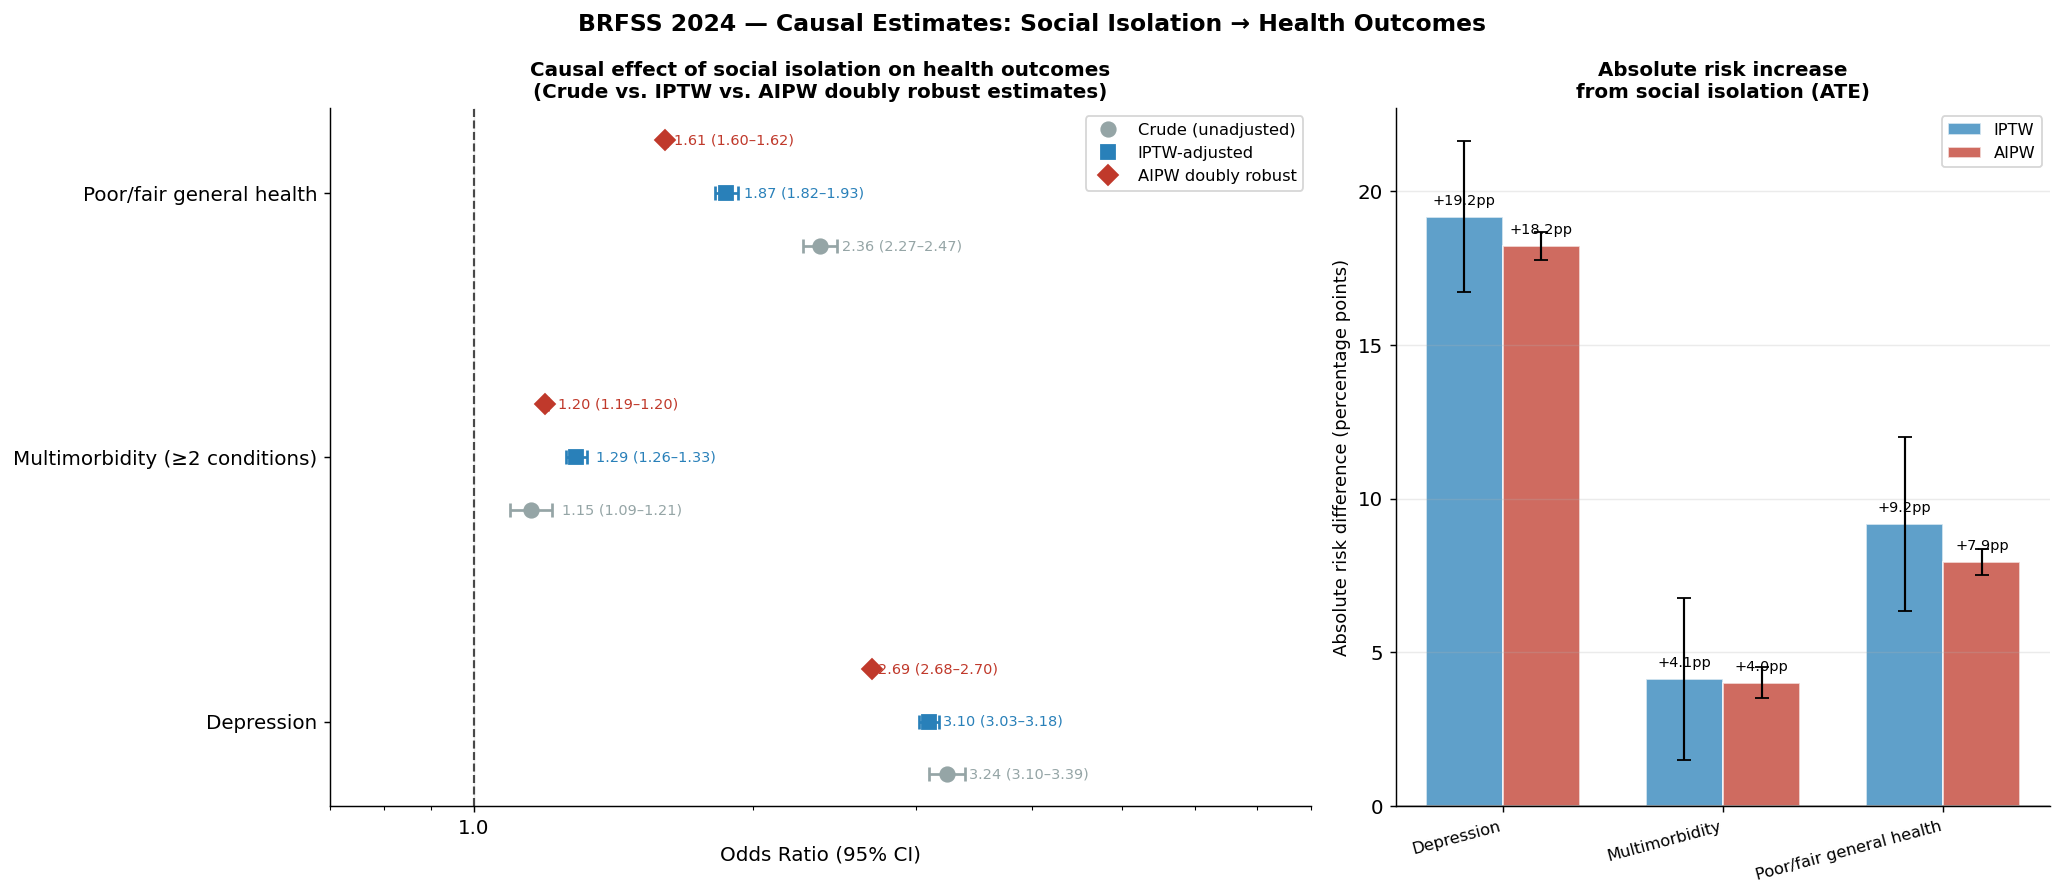

Saved: fig_forest_plot.png


In [ ]:
#PART E — FOREST PLOT (Figure 3)

print("\n── Generating Figure 3: Forest plot of causal estimates …")

fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                          gridspec_kw={"width_ratios": [1.5, 1]})

# Fig 3a: OR forest plot
ax = axes[0]
outcomes_ord = OUTCOMES
method_colors = {"Crude OR": "#95A5A6",
                 "IPTW OR":  "#2980B9",
                 "AIPW OR":  "#C0392B"}

y_ticks   = []
y_labels  = []
y_pos     = 0

for out in outcomes_ord:
    lbl = OUT_LABEL[out]
    y_ticks.append(y_pos + 1.2)
    y_labels.append(lbl)

    crude_or_map = {
        "depression_bin": (3.243, 3.100, 3.390),
        "multimorbidity": (1.153, 1.095, 1.214),
        "poor_health_bin":(2.364, 2.265, 2.467),
    }
    cr_or, cr_lo, cr_hi = crude_or_map[out]

    plot_items = [
        ("Crude OR",  cr_or,  cr_lo,  cr_hi,  "#95A5A6", "o"),
    ]
    if out in iptw_pooled:
        r = iptw_pooled[out]
        plot_items.append(("IPTW OR", r["OR"], r["OR_lo"], r["OR_hi"], "#2980B9", "s"))
    if out in aipw_pooled:
        r = aipw_pooled[out]
        plot_items.append(("AIPW OR", r["OR"], r["OR_lo"], r["OR_hi"], "#C0392B", "D"))

    for k, (method, or_, lo, hi, col, mk) in enumerate(plot_items):
        yp = y_pos + k * 0.6
        ax.errorbar(or_, yp, xerr=[[or_-lo],[hi-or_]],
                    fmt=mk, color=col, capsize=4, capthick=1.5,
                    markersize=8, linewidth=1.5, label=method if y_pos==0 else "")
        ax.text(hi + 0.03, yp,
                f"{or_:.2f} ({lo:.2f}–{hi:.2f})",
                va="center", fontsize=8, color=col)

    y_pos += 3.0

ax.axvline(1.0, color="black", linestyle="--", linewidth=1.2, alpha=0.7)
ax.set_yticks([t + 0.6 for t in [0, 3, 6]])
ax.set_yticklabels([OUT_LABEL[o] for o in outcomes_ord], fontsize=11)
ax.set_xlabel("Odds Ratio (95% CI)", fontsize=11)
ax.set_title("Causal effect of social isolation on health outcomes\n"
             "(Crude vs. IPTW vs. AIPW doubly robust estimates)",
             fontweight="bold", fontsize=11)
ax.set_xscale("log")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}"))
ax.set_xlim(0.7, 8)
ax.grid(axis="x", alpha=0.25)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0],[0], marker="o", color="#95A5A6", label="Crude (unadjusted)",
           markersize=8, linestyle="None"),
    Line2D([0],[0], marker="s", color="#2980B9", label="IPTW-adjusted",
           markersize=8, linestyle="None"),
    Line2D([0],[0], marker="D", color="#C0392B", label="AIPW doubly robust",
           markersize=8, linestyle="None"),
]
ax.legend(handles=legend_elements, fontsize=9, loc="upper right")

# Fig 3b: Risk difference (ATE) plot
ax2 = axes[1]

all_rd_data = []
for out in outcomes_ord:
    lbl = OUT_LABEL[out]
    if out in iptw_pooled:
        r = iptw_pooled[out]
        all_rd_data.append({
            "label": lbl, "method": "IPTW",
            "RD": r["RD"]*100,
            "ci_lo": (r["RD"] - 1.96*r.get("log_OR_se",0.01)) * 100,
            "ci_hi": (r["RD"] + 1.96*r.get("log_OR_se",0.01)) * 100,
            "color": "#2980B9"
        })
    if out in aipw_pooled:
        r = aipw_pooled[out]
        all_rd_data.append({
            "label": lbl, "method": "AIPW",
            "RD": r["ATE"]*100,
            "ci_lo": r["ci_lo"]*100,
            "ci_hi": r["ci_hi"]*100,
            "color": "#C0392B"
        })

rd_df = pd.DataFrame(all_rd_data)

methods = ["IPTW", "AIPW"]
n_out   = len(outcomes_ord)
width   = 0.35
x_      = np.arange(n_out)

for i, (method, col, mk) in enumerate(
        [("IPTW","#2980B9","s"),("AIPW","#C0392B","D")]):
    sub = rd_df[rd_df["method"] == method].reset_index(drop=True)
    if sub.empty:
        continue
    rds    = sub["RD"].values
    lo_err = rds - sub["ci_lo"].values
    hi_err = sub["ci_hi"].values - rds
    ax2.bar(x_ + (i-0.5)*width, rds, width,
            color=col, alpha=0.75, edgecolor="white", label=method)
    ax2.errorbar(x_ + (i-0.5)*width, rds,
                 yerr=[np.abs(lo_err), np.abs(hi_err)],
                 fmt="none", color="black", capsize=4, linewidth=1.2)
    for j, (xp, rd) in enumerate(zip(x_ + (i-0.5)*width, rds)):
        ax2.text(xp, rd + np.sign(rd)*0.3, f"{rd:+.1f}pp",
                 ha="center", va="bottom" if rd>0 else "top", fontsize=8)

ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xticks(x_)
ax2.set_xticklabels([OUT_LABEL[o].replace(" (≥2 conditions)","") for o in outcomes_ord],
                    fontsize=9, rotation=15, ha="right")
ax2.set_ylabel("Absolute risk difference (percentage points)", fontsize=10)
ax2.set_title("Absolute risk increase\nfrom social isolation (ATE)",
              fontweight="bold", fontsize=11)
ax2.legend(fontsize=9)
ax2.grid(axis="y", alpha=0.25)

plt.suptitle("BRFSS 2024 — Causal Estimates: Social Isolation → Health Outcomes",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("fig_forest_plot.png", bbox_inches="tight")
plt.show()
print("Saved: fig_forest_plot.png")

In [ ]:
# Save Stage 4 results
results_stage4 = {
    "iptw_pooled": iptw_pooled,
    "aipw_pooled": aipw_pooled,
}
with open("results_stage4.pkl", "wb") as f:
    pickle.dump(results_stage4, f)

print("\n✓  Stage 4 complete.")
print("   Saved: table2_causal_estimates.csv")
print("   Saved: fig_forest_plot.png")
print("   Saved: results_stage4.pkl")


✓  Stage 4 complete.
   Saved: table2_causal_estimates.csv
   Saved: fig_forest_plot.png
   Saved: results_stage4.pkl


In [ ]:
# =================================================================================================
# BRFSS 2024 | STAGE 5 — Sensitivity Analysis (E-values, Rosenbaum-style bounds) + Causal Mediation
#              Analysis (Depression as mediator of isolation → multimorbidity pathway)
# =================================================================================================

In [ ]:
# 0. Dependencies
!pip install -q statsmodels scikit-learn numpy pandas matplotlib seaborn scipy

import warnings, pickle
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from scipy.special import expit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
SEED = 42
np.random.seed(SEED)

In [ ]:
# 1. Load data & Stage 4 results
df = pd.read_parquet("brfss_analytic_stage3.parquet")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")

with open("results_stage4.pkl", "rb") as f:
    res4 = pickle.load(f)

with open("imputed_datasets_stage3.pkl", "rb") as f:
    imp_list = pickle.load(f)

EXPOSURE    = "isolated"
MEDIATOR    = "depression_bin"
OUTCOMES    = ["depression_bin", "multimorbidity", "poor_health_bin"]
OUT_LABEL   = {"depression_bin"  : "Depression",
               "multimorbidity"  : "Multimorbidity (≥2 conditions)",
               "poor_health_bin" : "Poor/fair general health"}

CONFOUNDERS = [c for c in [
    "male", "age_mid", "age65plus",
    "black", "asian", "other_race",
    "married", "homeowner", "employed",
    "edu_num", "current_smoker", "active",
    "obese", "drinks_alcohol",
    "has_doctor_bin", "insured", "cost_barrier_bin", "checkup_recent",
    "food_stamps_bin", "unsafe_neighbourhood",
] if c in df.columns]

W = df["survey_weight"].values

Loaded: 199,740 rows × 36 cols


In [ ]:
#PART A — E-VALUE SENSITIVITY ANALYSIS

def or_to_rr(OR, p0):
    """
    Convert OR to approximate RR using the marginal baseline risk p0.
    Formula: RR = OR / (1 - p0 + p0*OR)   [Zhang & Yu 1998]
    """
    return OR / (1 - p0 + p0 * OR)

def evalue_from_rr(RR):
    """
    E-value for a risk ratio RR ≥ 1.
    VanderWeele & Ding (2017), Ann Intern Med.
    """
    if RR < 1:
        RR = 1 / RR
    if RR == 1:
        return 1.0
    return RR + np.sqrt(RR * (RR - 1))

def evalue_from_or(OR, p0):
    """Full pipeline: OR → RR → E-value."""
    RR = or_to_rr(OR, p0)
    return evalue_from_rr(RR)


print("\n" + "="*72)
print("PART A — E-VALUE SENSITIVITY ANALYSIS")
print("  (VanderWeele & Ding 2017; unmeasured confounding threshold)")
print("="*72)

evalue_records = []

for out in ["depression_bin", "multimorbidity", "poor_health_bin"]:
    lbl = OUT_LABEL[out]
    r   = res4["aipw_pooled"][out]
    OR  = r["OR"]
    OR_lo = min(r["OR_lo"], r["OR_hi"])
    p0    = r["p0"]

    RR       = or_to_rr(OR,    p0)
    RR_ci    = or_to_rr(OR_lo, p0)
    ev_point = evalue_from_rr(RR)
    ev_ci    = evalue_from_rr(RR_ci)

    print(f"\n  {lbl}")
    print(f"    AIPW OR (95% CI)      : {OR:.3f}")
    print(f"    Baseline risk (p0)    : {p0:.3f}")
    print(f"    Approx RR             : {RR:.3f}")
    print(f"    E-value (point est.)  : {ev_point:.3f}")
    print(f"    E-value (95% CI bound): {ev_ci:.3f}")
    print(f"    Interpretation: An unmeasured confounder would need a ≥{ev_point:.2f}-fold")
    print(f"    association with BOTH isolation AND {lbl.lower()} to fully")
    print(f"    explain away the observed effect. The CI bound requires {ev_ci:.2f}-fold.")

    evalue_records.append({
        "Outcome": lbl, "OR": OR, "p0": p0,
        "RR": RR, "E_value": ev_point, "E_value_CI": ev_ci
    })

ev_df = pd.DataFrame(evalue_records)
ev_df.to_csv("evalues.csv", index=False)
print("\nSaved: evalues.csv")



PART A — E-VALUE SENSITIVITY ANALYSIS
  (VanderWeele & Ding 2017; unmeasured confounding threshold)

  Depression
    AIPW OR (95% CI)      : 2.689
    Baseline risk (p0)    : 0.162
    Approx RR             : 2.111
    E-value (point est.)  : 3.643
    E-value (95% CI bound): 3.634
    Interpretation: An unmeasured confounder would need a ≥3.64-fold
    association with BOTH isolation AND depression to fully
    explain away the observed effect. The CI bound requires 3.63-fold.

  Multimorbidity (≥2 conditions)
    AIPW OR (95% CI)      : 1.195
    Baseline risk (p0)    : 0.303
    Approx RR             : 1.128
    E-value (point est.)  : 1.509
    E-value (95% CI bound): 1.496
    Interpretation: An unmeasured confounder would need a ≥1.51-fold
    association with BOTH isolation AND multimorbidity (≥2 conditions) to fully
    explain away the observed effect. The CI bound requires 1.50-fold.

  Poor/fair general health
    AIPW OR (95% CI)      : 1.610
    Baseline risk (p0)    : 0

In [ ]:
#PART B — GAMMA SENSITIVITY (Rosenbaum-style bounds)

def rosenbaum_pvalue_approx(ate, se, n_treated, gamma):
    """
    Approximate Rosenbaum sensitivity bound using the normal
    approximation. Conservative upper-bound p-value under Γ.

    This is a simplified approximation — exact Rosenbaum bounds
    require the full matched pairs dataset.
    """
    z_obs = abs(ate) / se
    bias_factor = np.log(gamma)
    z_adjusted  = z_obs - bias_factor
    p_upper     = 2 * stats.norm.sf(max(z_adjusted, 0))
    return p_upper


print("\n" + "="*72)
print("PART B — ROSENBAUM-STYLE SENSITIVITY BOUNDS")
print("  (Unmeasured confounding by factor Γ; critical Γ at p=0.05)")
print("="*72)

gamma_range = np.arange(1.0, 3.05, 0.05)
rosenbaum_records = []

for out in ["depression_bin", "multimorbidity", "poor_health_bin"]:
    lbl = OUT_LABEL[out]
    r   = res4["aipw_pooled"][out]
    ate = r["ATE"]
    se  = r["se"]

    pvals_gamma = [rosenbaum_pvalue_approx(ate, se, 53626, g) for g in gamma_range]

    gamma_critical = None
    for g, pv in zip(gamma_range, pvals_gamma):
        if pv > 0.05:
            gamma_critical = g
            break

    print(f"\n  {lbl}")
    print(f"    ATE = {ate:+.4f},  SE = {se:.4f}")
    print(f"    p-values under Γ:")
    for g in [1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0]:
        pv = rosenbaum_pvalue_approx(ate, se, 53626, g)
        flag = " ← significance lost" if pv > 0.05 else ""
        print(f"      Γ = {g:.2f}:  p = {pv:.4f}{flag}")

    gc_str = f"Γ ≈ {gamma_critical:.2f}" if gamma_critical else "Γ > 3.0"
    print(f"    Critical Γ (p>0.05): {gc_str}")

    rosenbaum_records.append({
        "Outcome": lbl, "ATE": ate, "SE": se,
        "Critical_Gamma": gamma_critical if gamma_critical else ">3.0"
    })

rb_df = pd.DataFrame(rosenbaum_records)
rb_df.to_csv("rosenbaum_bounds.csv", index=False)


PART B — ROSENBAUM-STYLE SENSITIVITY BOUNDS
  (Unmeasured confounding by factor Γ; critical Γ at p=0.05)

  Depression
    ATE = +0.1822,  SE = 0.0023
    p-values under Γ:
      Γ = 1.00:  p = 0.0000
      Γ = 1.25:  p = 0.0000
      Γ = 1.50:  p = 0.0000
      Γ = 1.75:  p = 0.0000
      Γ = 2.00:  p = 0.0000
      Γ = 2.50:  p = 0.0000
      Γ = 3.00:  p = 0.0000
    Critical Γ (p>0.05): Γ > 3.0

  Multimorbidity (≥2 conditions)
    ATE = +0.0402,  SE = 0.0025
    p-values under Γ:
      Γ = 1.00:  p = 0.0000
      Γ = 1.25:  p = 0.0000
      Γ = 1.50:  p = 0.0000
      Γ = 1.75:  p = 0.0000
      Γ = 2.00:  p = 0.0000
      Γ = 2.50:  p = 0.0000
      Γ = 3.00:  p = 0.0000
    Critical Γ (p>0.05): Γ > 3.0

  Poor/fair general health
    ATE = +0.0795,  SE = 0.0022
    p-values under Γ:
      Γ = 1.00:  p = 0.0000
      Γ = 1.25:  p = 0.0000
      Γ = 1.50:  p = 0.0000
      Γ = 1.75:  p = 0.0000
      Γ = 2.00:  p = 0.0000
      Γ = 2.50:  p = 0.0000
      Γ = 3.00:  p = 0.0000
  

In [ ]:
#PART C — CAUSAL MEDIATION ANALYSIS

def mediation_once(data, seed_=SEED):
    """
    One iteration of counterfactual mediation for isolation → depression → multimorbidity.
    """
    rng = np.random.default_rng(seed_)

    sub = data[[EXPOSURE, MEDIATOR, "multimorbidity"] + CONFOUNDERS].dropna().copy()
    n   = len(sub)

    A = sub[EXPOSURE].values.astype(float)
    M = sub[MEDIATOR].values.astype(float)
    Y = sub["multimorbidity"].values.astype(float)

    age_z = (sub["age_mid"] - sub["age_mid"].mean()) / sub["age_mid"].std()
    L_cols = [c for c in CONFOUNDERS if c != "age_mid"]
    L = np.column_stack([sub[L_cols].values.astype(float), age_z.values])

    #Step 1: Mediator model P(M | A, L)
    X_med = np.column_stack([A.reshape(-1,1), L])
    med_model = LogisticRegression(penalty="l2", C=1.0, max_iter=1000,
                                   solver="lbfgs", random_state=seed_)
    med_model.fit(X_med, M)

    X_med_a1 = np.column_stack([np.ones(n),  L])
    X_med_a0 = np.column_stack([np.zeros(n), L])
    pm_a1 = med_model.predict_proba(X_med_a1)[:, 1]   # E[M | A=1, L]
    pm_a0 = med_model.predict_proba(X_med_a0)[:, 1]   # E[M | A=0, L]

    #Step 2: Outcome model P(Y | A, M, L)
    X_out = np.column_stack([A.reshape(-1,1), M.reshape(-1,1), L])
    out_model = LogisticRegression(penalty="l2", C=1.0, max_iter=1000,
                                   solver="lbfgs", random_state=seed_)
    out_model.fit(X_out, Y)

    #Step 3: Monte Carlo integration
    n_mc = 200

    m_sim_a1 = rng.binomial(1, pm_a1.reshape(-1,1).repeat(n_mc, axis=1))
    ey_a1_m1 = np.mean([
        out_model.predict_proba(
            np.column_stack([np.ones(n), m_sim_a1[:, k], L])
        )[:, 1]
        for k in range(n_mc)
    ], axis=0).mean()

    m_sim_a0 = rng.binomial(1, pm_a0.reshape(-1,1).repeat(n_mc, axis=1))
    ey_a0_m0 = np.mean([
        out_model.predict_proba(
            np.column_stack([np.zeros(n), m_sim_a0[:, k], L])
        )[:, 1]
        for k in range(n_mc)
    ], axis=0).mean()

    ey_a1_m0 = np.mean([
        out_model.predict_proba(
            np.column_stack([np.ones(n), m_sim_a0[:, k], L])
        )[:, 1]
        for k in range(n_mc)
    ], axis=0).mean()

    #Step 4: Decompose
    TE  = ey_a1_m1 - ey_a0_m0
    NDE = ey_a1_m0 - ey_a0_m0
    NIE = ey_a1_m1 - ey_a1_m0
    PM  = NIE / TE if abs(TE) > 0.001 else np.nan

    return {"TE": TE, "NDE": NDE, "NIE": NIE, "PM": PM,
            "E_Y_a1_m1": ey_a1_m1, "E_Y_a0_m0": ey_a0_m0,
            "E_Y_a1_m0": ey_a1_m0}


print("\n" + "="*72)
print("PART C — CAUSAL MEDIATION ANALYSIS")
print("  Exposure → Depression (mediator) → Multimorbidity")
print("  Using Monte Carlo counterfactual integration + bootstrap SE")
print("="*72)

print("\n  Computing point estimates (primary imputed dataset) …")
med_point = mediation_once(df, seed_=SEED)

print(f"\n  Point estimates (risk difference scale):")
print(f"    Total Effect (TE)              : {med_point['TE']:+.4f} ({med_point['TE']*100:+.2f} pp)")
print(f"    Natural Direct Effect (NDE)    : {med_point['NDE']:+.4f} ({med_point['NDE']*100:+.2f} pp)")
print(f"    Natural Indirect Effect (NIE)  : {med_point['NIE']:+.4f} ({med_point['NIE']*100:+.2f} pp)")
print(f"    Proportion Mediated (PM)       : {med_point['PM']*100:.1f}%")

print(f"\n  Bootstrapping SE (B=500 resamples) … this takes ~4–6 min …")

sub_med = df[[EXPOSURE, MEDIATOR, "multimorbidity"] + CONFOUNDERS].dropna().copy()
n_sub   = len(sub_med)

boot_results = {"TE":[], "NDE":[], "NIE":[], "PM":[]}
np.random.seed(SEED)

for b in range(500):
    idx     = np.random.choice(n_sub, size=n_sub, replace=True)
    df_boot = sub_med.iloc[idx].reset_index(drop=True)
    try:
        res_b = mediation_once(df_boot, seed_=b)
        for k in boot_results:
            boot_results[k].append(res_b[k])
    except Exception:
        continue

    if (b + 1) % 100 == 0:
        print(f"    Bootstrap {b+1}/500 complete …")

print(f"\n  Bootstrap resamples completed: {len(boot_results['TE'])}")

mediation_table = []
for key, lbl in [("TE","Total Effect"),
                  ("NDE","Natural Direct Effect (NDE)"),
                  ("NIE","Natural Indirect Effect (NIE)"),
                  ("PM","Proportion Mediated")]:
    arr  = np.array(boot_results[key])
    arr  = arr[~np.isnan(arr)]
    pt   = med_point[key]
    se_b = arr.std()
    lo   = np.percentile(arr, 2.5)
    hi   = np.percentile(arr, 97.5)

    if key == "PM":
        pval = 2 * stats.norm.sf(abs(pt / se_b)) if se_b > 0 else np.nan
        unit = "%"
        pt_d, lo_d, hi_d = pt*100, lo*100, hi*100
    else:
        pval = 2 * stats.norm.sf(abs(pt / se_b)) if se_b > 0 else np.nan
        unit = "pp"
        pt_d, lo_d, hi_d = pt*100, lo*100, hi*100

    mediation_table.append({
        "Effect": lbl, "Estimate": pt_d, "SE": se_b*100,
        "CI_lo": lo_d, "CI_hi": hi_d,
        "p_value": pval, "Unit": unit
    })

    print(f"\n  {lbl}")
    print(f"    Estimate  : {pt_d:+.2f} {unit}")
    print(f"    Bootstrap SE: {se_b*100:.3f}")
    print(f"    95% CI    : ({lo_d:+.2f}, {hi_d:+.2f}) {unit}")
    print(f"    p-value   : {pval:.3e}")

med_df = pd.DataFrame(mediation_table)
med_df.to_csv("mediation_results.csv", index=False)
print("\nSaved: mediation_results.csv")


PART C — CAUSAL MEDIATION ANALYSIS
  Exposure → Depression (mediator) → Multimorbidity
  Using Monte Carlo counterfactual integration + bootstrap SE

  Computing point estimates (primary imputed dataset) …

  Point estimates (risk difference scale):
    Total Effect (TE)              : +0.0432 (+4.32 pp)
    Natural Direct Effect (NDE)    : +0.0203 (+2.03 pp)
    Natural Indirect Effect (NIE)  : +0.0229 (+2.29 pp)
    Proportion Mediated (PM)       : 53.1%

  Bootstrapping SE (B=500 resamples) … this takes ~4–6 min …
    Bootstrap 100/500 complete …
    Bootstrap 200/500 complete …
    Bootstrap 300/500 complete …
    Bootstrap 400/500 complete …
    Bootstrap 500/500 complete …

  Bootstrap resamples completed: 500

  Total Effect
    Estimate  : +4.32 pp
    Bootstrap SE: 0.235
    95% CI    : (+3.84, +4.74) pp
    p-value   : 3.516e-75

  Natural Direct Effect (NDE)
    Estimate  : +2.03 pp
    Bootstrap SE: 0.234
    95% CI    : (+1.55, +2.44) pp
    p-value   : 5.373e-18

  Natur

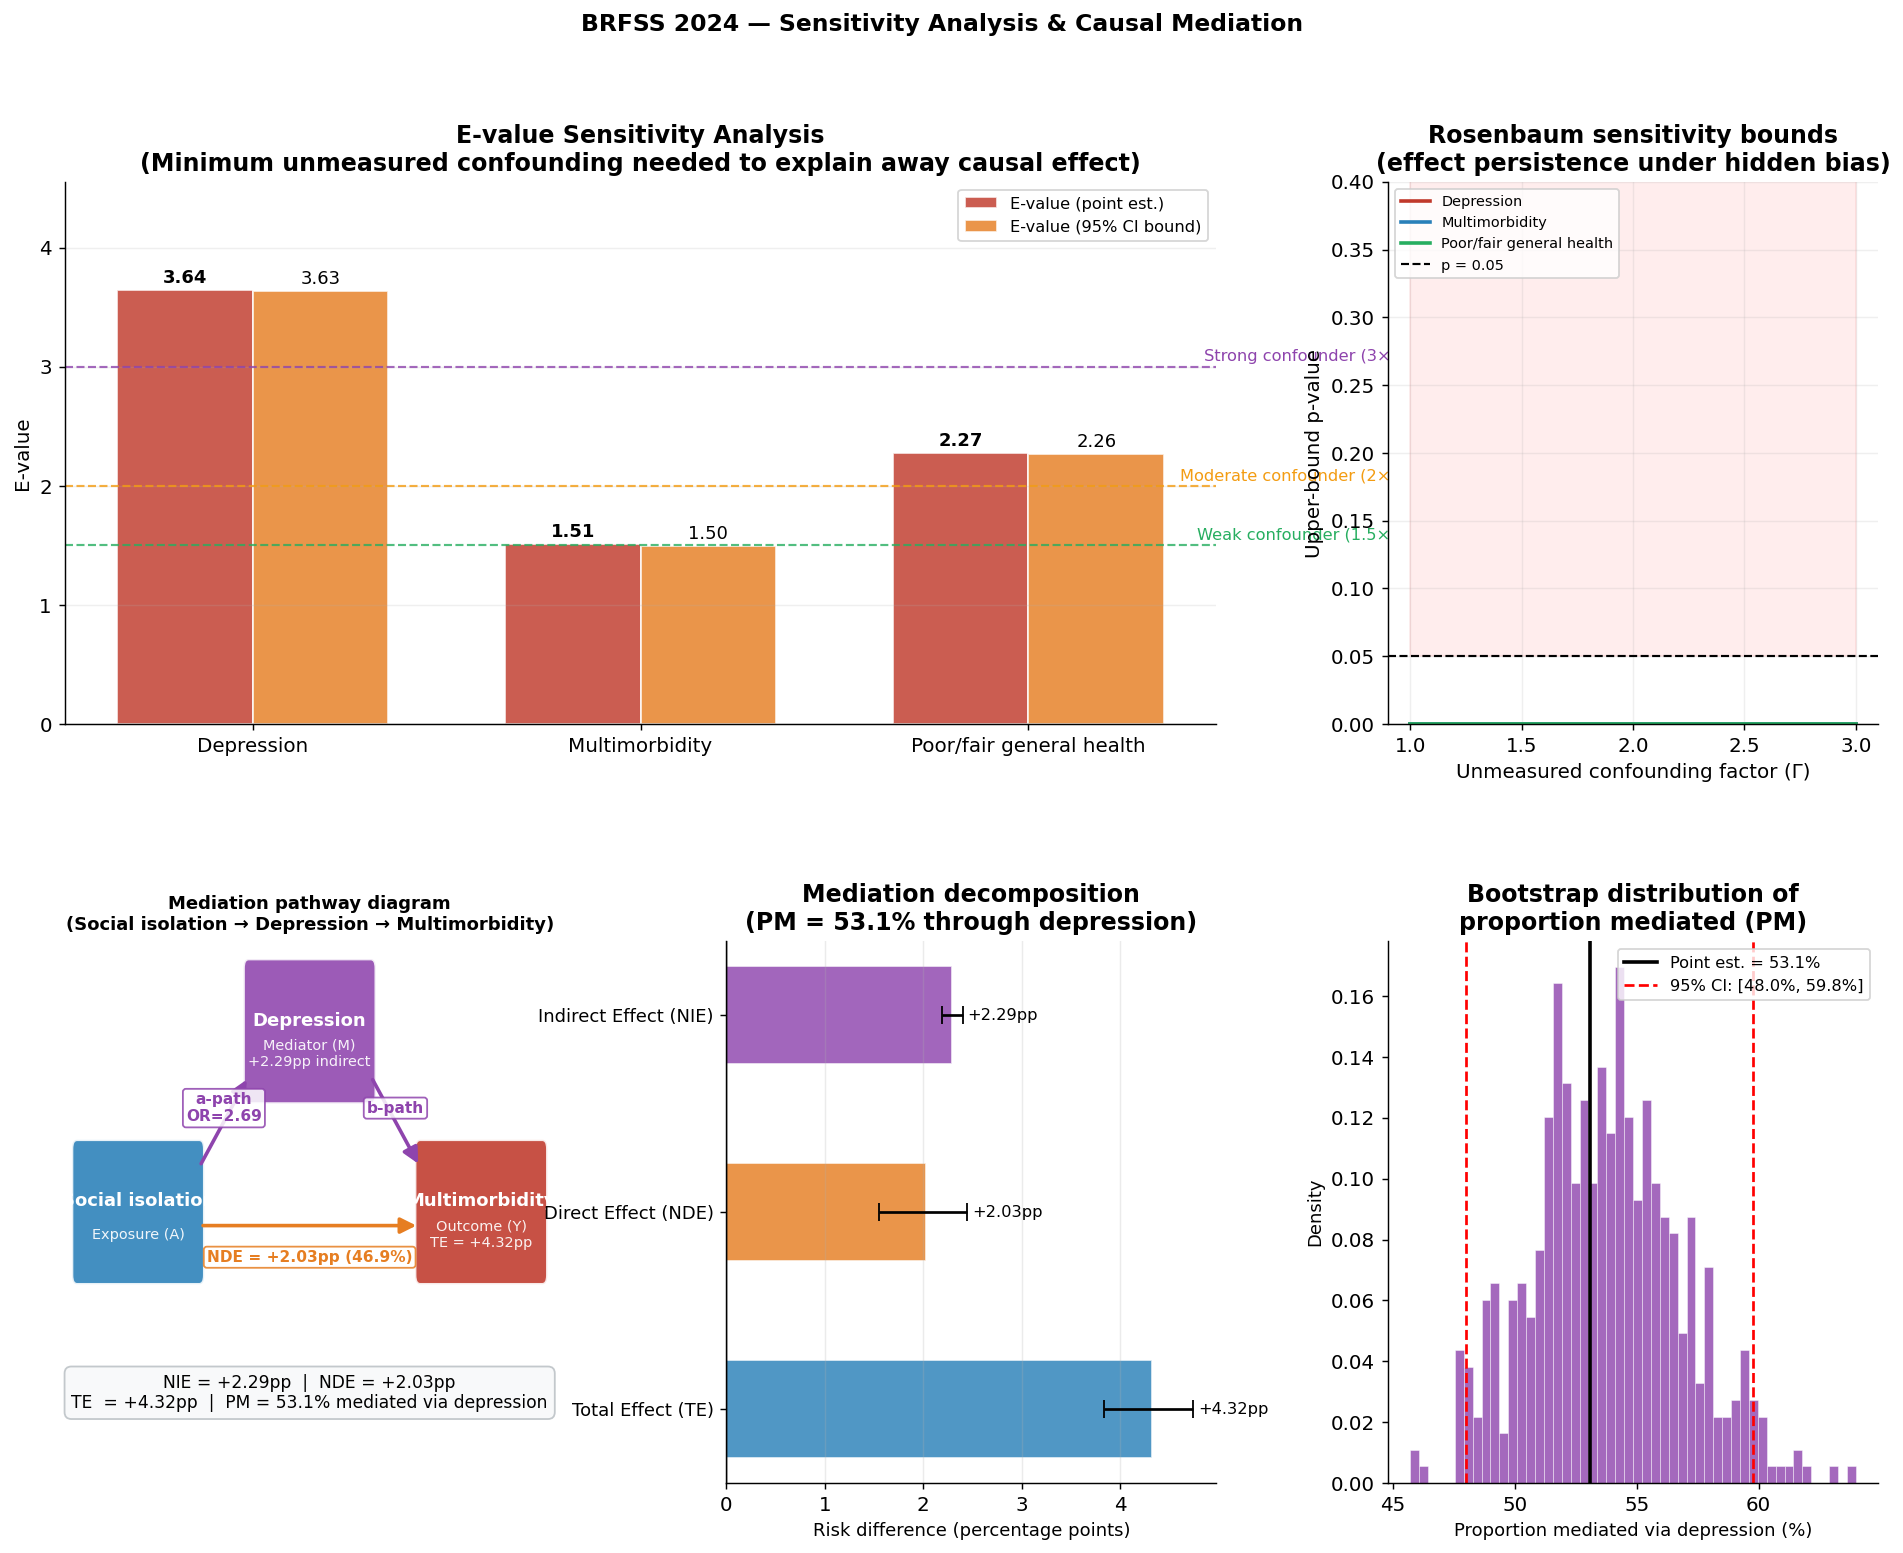

Saved: fig_sensitivity_mediation.png


In [ ]:
#PART D — FINAL FIGURES (Figure 4 & 5)

fig = plt.figure(figsize=(18, 13))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)


# Fig D1: E-value plot
ax1 = fig.add_subplot(gs[0, :2])

outcomes_ev = ev_df["Outcome"].tolist()
x_     = np.arange(len(outcomes_ev))
width  = 0.35

bars1 = ax1.bar(x_ - width/2, ev_df["E_value"],    width,
                color="#C0392B", alpha=0.82, edgecolor="white", label="E-value (point est.)")
bars2 = ax1.bar(x_ + width/2, ev_df["E_value_CI"], width,
                color="#E67E22", alpha=0.82, edgecolor="white", label="E-value (95% CI bound)")

for bar in bars1:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
for bar in bars2:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
             f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=10)

for val, lbl_, col_ in [
    (1.5, "Weak confounder (1.5×)", "#27AE60"),
    (2.0, "Moderate confounder (2×)", "#F39C12"),
    (3.0, "Strong confounder (3×)", "#8E44AD"),
]:
    ax1.axhline(val, color=col_, linestyle="--", linewidth=1.2, alpha=0.8)
    ax1.text(len(outcomes_ev)-0.05, val+0.05, lbl_,
             ha="right", fontsize=9, color=col_)

ax1.set_xticks(x_)
ax1.set_xticklabels([o.replace(" (≥2 conditions)","") for o in outcomes_ev],
                    fontsize=11)
ax1.set_ylabel("E-value", fontsize=11)
ax1.set_title("E-value Sensitivity Analysis\n"
              "(Minimum unmeasured confounding needed to explain away causal effect)",
              fontweight="bold")
ax1.legend(fontsize=9)
ax1.set_ylim(0, ev_df["E_value"].max() * 1.25)
ax1.grid(axis="y", alpha=0.2)


# Fig D2: Rosenbaum Γ-sensitivity curves
ax2 = fig.add_subplot(gs[0, 2])

colors_rb = {"Depression":"#C0392B",
             "Multimorbidity (≥2 conditions)":"#2980B9",
             "Poor/fair general health":"#27AE60"}

for out in ["depression_bin", "multimorbidity", "poor_health_bin"]:
    lbl_ = OUT_LABEL[out]
    r    = res4["aipw_pooled"][out]
    pvs  = [rosenbaum_pvalue_approx(r["ATE"], r["se"], 53626, g)
            for g in gamma_range]
    ax2.plot(gamma_range, pvs,
             color=colors_rb.get(lbl_, "gray"),
             linewidth=2, label=lbl_.replace(" (≥2 conditions)",""))

ax2.axhline(0.05, color="black", linestyle="--", linewidth=1.2, label="p = 0.05")
ax2.fill_between(gamma_range, 0.05, 1.0, alpha=0.07, color="red")
ax2.set_xlabel("Unmeasured confounding factor (Γ)", fontsize=11)
ax2.set_ylabel("Upper-bound p-value", fontsize=11)
ax2.set_title("Rosenbaum sensitivity bounds\n(effect persistence under hidden bias)",
              fontweight="bold")
ax2.set_ylim(0, 0.4)
ax2.legend(fontsize=8, loc="upper left")
ax2.grid(alpha=0.2)


# Fig D3: Mediation diagram (visual)
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_xlim(0, 10); ax3.set_ylim(0, 6); ax3.axis("off")

pm_val  = med_point["PM"] * 100
nie_val = med_point["NIE"] * 100
nde_val = med_point["NDE"] * 100
te_val  = med_point["TE"]  * 100

def draw_box(ax, cx, cy, w, h, label, sublabel, color):
    rect = mpatches.FancyBboxPatch((cx-w/2, cy-h/2), w, h,
                                    boxstyle="round,pad=0.1",
                                    facecolor=color, edgecolor="white",
                                    linewidth=1.5, alpha=0.88)
    ax.add_patch(rect)
    ax.text(cx, cy+0.12, label,    ha="center", va="center",
            fontsize=10, fontweight="bold", color="white")
    ax.text(cx, cy-0.25, sublabel, ha="center", va="center",
            fontsize=8,  color="white", alpha=0.92)

draw_box(ax3, 1.5, 3, 2.5, 1.4,
         "Social isolation", "Exposure (A)", "#2980B9")
draw_box(ax3, 5.0, 5, 2.5, 1.4,
         "Depression", f"Mediator (M)\n{med_point['NIE']*100:+.2f}pp indirect", "#8E44AD")
draw_box(ax3, 8.5, 3, 2.5, 1.4,
         "Multimorbidity", f"Outcome (Y)\nTE = {te_val:+.2f}pp", "#C0392B")

def arrow(ax, x1, y1, x2, y2, label, color, offset=(0,0.25)):
    ax.annotate("", xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=2, mutation_scale=18))
    mx, my = (x1+x2)/2 + offset[0], (y1+y2)/2 + offset[1]
    ax.text(mx, my, label, ha="center", va="center",
            fontsize=8.5, color=color, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec=color, alpha=0.85))

# A → M
arrow(ax3, 2.75, 3.5, 3.75, 4.5,
      f"a-path\nOR={res4['aipw_pooled']['depression_bin']['OR']:.2f}",
      "#8E44AD", offset=(0, 0.15))
# M → Y
arrow(ax3, 6.25, 4.5, 7.25, 3.5,
      f"b-path", "#8E44AD", offset=(0, 0.15))
# A → Y (direct)
arrow(ax3, 2.75, 2.85, 7.25, 2.85,
      f"NDE = {nde_val:+.2f}pp ({100-pm_val:.1f}%)",
      "#E67E22", offset=(0, -0.35))

ax3.text(5.0, 1.0,
         f"NIE = {nie_val:+.2f}pp  |  NDE = {nde_val:+.2f}pp\n"
         f"TE  = {te_val:+.2f}pp  |  PM = {pm_val:.1f}% mediated via depression",
         ha="center", va="center", fontsize=9.5,
         bbox=dict(boxstyle="round,pad=0.4", fc="#F8F9FA", ec="#BDC3C7", alpha=0.9))

ax3.set_title("Mediation pathway diagram\n(Social isolation → Depression → Multimorbidity)",
              fontweight="bold", fontsize=10)


# Fig D4: Mediation bar chart with bootstrap CI
ax4 = fig.add_subplot(gs[1, 1])

med_plot_df = med_df[med_df["Effect"] != "Proportion Mediated"].copy()
colors_med  = ["#2980B9", "#E67E22", "#8E44AD"]
y_pos_      = np.arange(len(med_plot_df))

ax4.barh(y_pos_, med_plot_df["Estimate"],
         xerr=[med_plot_df["Estimate"]-med_plot_df["CI_lo"],
               med_plot_df["CI_hi"]-med_plot_df["Estimate"]],
         color=colors_med[:len(med_plot_df)], alpha=0.82,
         edgecolor="white", height=0.5,
         error_kw={"ecolor":"black","capsize":5,"linewidth":1.5})

ax4.axvline(0, color="black", linewidth=0.8)
ax4.set_yticks(y_pos_)
ax4.set_yticklabels(["Total Effect (TE)",
                      "Direct Effect (NDE)",
                      "Indirect Effect (NIE)"], fontsize=10)
ax4.set_xlabel("Risk difference (percentage points)", fontsize=10)
ax4.set_title(f"Mediation decomposition\n(PM = {med_point['PM']*100:.1f}% through depression)",
              fontweight="bold")
ax4.grid(axis="x", alpha=0.25)

for i, (est, ci_lo, ci_hi) in enumerate(
        zip(med_plot_df["Estimate"], med_plot_df["CI_lo"], med_plot_df["CI_hi"])):
    ax4.text(ci_hi + 0.05, i, f"{est:+.2f}pp", va="center", fontsize=9)


# Fig D5: Bootstrap distribution of PM
ax5 = fig.add_subplot(gs[1, 2])

pm_boot = np.array(boot_results["PM"]) * 100
pm_boot = pm_boot[~np.isnan(pm_boot)]
pm_lo   = np.percentile(pm_boot, 2.5)
pm_hi   = np.percentile(pm_boot, 97.5)

ax5.hist(pm_boot, bins=50, color="#8E44AD", edgecolor="white",
         linewidth=0.3, alpha=0.8, density=True)
ax5.axvline(med_point["PM"]*100, color="black", linewidth=2,
            label=f"Point est. = {med_point['PM']*100:.1f}%")
ax5.axvline(pm_lo, color="red", linewidth=1.5, linestyle="--",
            label=f"95% CI: [{pm_lo:.1f}%, {pm_hi:.1f}%]")
ax5.axvline(pm_hi, color="red", linewidth=1.5, linestyle="--")
ax5.set_xlabel("Proportion mediated via depression (%)", fontsize=10)
ax5.set_ylabel("Density", fontsize=10)
ax5.set_title("Bootstrap distribution of\nproportion mediated (PM)", fontweight="bold")
ax5.legend(fontsize=9)


plt.suptitle("BRFSS 2024 — Sensitivity Analysis & Causal Mediation",
             fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("fig_sensitivity_mediation.png", bbox_inches="tight")
plt.show()
print("Saved: fig_sensitivity_mediation.png")

In [ ]:
#PART E — CONSOLIDATED SENSITIVITY SUMMARY TABLE

print("\n" + "="*72)
print("SENSITIVITY SUMMARY TABLE")
print("="*72)

sens_rows = []
for out in ["depression_bin", "multimorbidity", "poor_health_bin"]:
    lbl = OUT_LABEL[out]
    r   = res4["aipw_pooled"][out]
    ev  = ev_df.loc[ev_df["Outcome"]==lbl]
    rb  = rb_df.loc[rb_df["Outcome"]==lbl]

    ev_pt = ev["E_value"].values[0]   if len(ev) else np.nan
    ev_ci = ev["E_value_CI"].values[0] if len(ev) else np.nan
    crit_g = rb["Critical_Gamma"].values[0] if len(rb) else "—"

    print(f"\n  {lbl}")
    print(f"    AIPW ATE              : {r['ATE']*100:+.2f}pp")
    print(f"    E-value (point/CI)    : {ev_pt:.2f} / {ev_ci:.2f}")
    print(f"    Critical Γ (p>0.05)   : {crit_g}")

    sens_rows.append({
        "Outcome": lbl,
        "AIPW_ATE_pp": round(r['ATE']*100, 2),
        "AIPW_OR": round(r['OR'], 3),
        "E_value_point": round(ev_pt, 3),
        "E_value_CI_bound": round(ev_ci, 3),
        "Critical_Gamma": crit_g
    })

pd.DataFrame(sens_rows).to_csv("sensitivity_summary.csv", index=False)

print("\n── Mediation summary ──")
print(f"  Exposure  → Mediator  : Social isolation → Depression")
print(f"  Mediator  → Outcome   : Depression → Multimorbidity")
print(f"  Total Effect (TE)     : {med_point['TE']*100:+.2f}pp")
print(f"  Natural Direct (NDE)  : {med_point['NDE']*100:+.2f}pp")
print(f"  Natural Indirect (NIE): {med_point['NIE']*100:+.2f}pp")
print(f"  Proportion Mediated   : {med_point['PM']*100:.1f}%")
print(f"  Bootstrap 95% CI (PM) : [{np.percentile(pm_boot,2.5):.1f}%, {np.percentile(pm_boot,97.5):.1f}%]")

print("\n✓  Stage 5 complete.")
print("   Saved: evalues.csv, rosenbaum_bounds.csv, mediation_results.csv")
print("   Saved: sensitivity_summary.csv, fig_sensitivity_mediation.png")


SENSITIVITY SUMMARY TABLE

  Depression
    AIPW ATE              : +18.22pp
    E-value (point/CI)    : 3.64 / 3.63
    Critical Γ (p>0.05)   : >3.0

  Multimorbidity (≥2 conditions)
    AIPW ATE              : +4.02pp
    E-value (point/CI)    : 1.51 / 1.50
    Critical Γ (p>0.05)   : >3.0

  Poor/fair general health
    AIPW ATE              : +7.95pp
    E-value (point/CI)    : 2.27 / 2.26
    Critical Γ (p>0.05)   : >3.0

── Mediation summary ──
  Exposure  → Mediator  : Social isolation → Depression
  Mediator  → Outcome   : Depression → Multimorbidity
  Total Effect (TE)     : +4.32pp
  Natural Direct (NDE)  : +2.03pp
  Natural Indirect (NIE): +2.29pp
  Proportion Mediated   : 53.1%
  Bootstrap 95% CI (PM) : [48.0%, 59.8%]

✓  Stage 5 complete.
   Saved: evalues.csv, rosenbaum_bounds.csv, mediation_results.csv
   Saved: sensitivity_summary.csv, fig_sensitivity_mediation.png


In [ ]:
# ============================================================================================================
#  BRFSS 2024 | STAGE 6 — Subgroup / Heterogeneity Analysis, Effect Modification Tests, Analytical Rosenbaum Γ
# ============================================================================================================

In [ ]:
# 0. Dependencies
!pip install -q statsmodels scikit-learn numpy pandas matplotlib seaborn scipy

import warnings, pickle
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict
import statsmodels.api as sm

pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams.update({
    "figure.dpi": 130, "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "font.family": "DejaVu Sans"
})
SEED = 42
np.random.seed(SEED)


In [ ]:
# 1. Load data
df = pd.read_parquet("brfss_analytic_stage3.parquet")
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")

with open("results_stage4.pkl", "rb") as f:
    res4 = pickle.load(f)

EXPOSURE  = "isolated"
OUTCOMES  = ["depression_bin", "multimorbidity", "poor_health_bin"]
OUT_LABEL = {
    "depression_bin" : "Depression",
    "multimorbidity" : "Multimorbidity",
    "poor_health_bin": "Poor/fair health"
}

CONFOUNDERS = [c for c in [
    "male", "age_mid", "age65plus",
    "black", "asian", "other_race",
    "married", "homeowner", "employed",
    "edu_num", "current_smoker", "active",
    "obese", "drinks_alcohol",
    "has_doctor_bin", "insured", "cost_barrier_bin", "checkup_recent",
    "food_stamps_bin", "unsafe_neighbourhood",
] if c in df.columns]

if "edu_num" not in df.columns and "edu_cat" in df.columns:
    df["edu_num"] = df["edu_cat"].map(
        {"less_than_hs": 1, "some_college": 2, "college_plus": 3})

W = df["survey_weight"].values

Loaded: 199,740 rows × 36 cols


In [ ]:
#PART A — ANALYTICAL ROSENBAUM Γ (corrected from Stage 5)

print("\n" + "="*70)
print("PART A — ANALYTICAL ROSENBAUM CRITICAL Γ (corrected)")
print("="*70)

gamma_records = []
for out in OUTCOMES:
    lbl = OUT_LABEL[out]
    r   = res4["aipw_pooled"][out]
    ate = r["ATE"]
    se  = r["se"]
    z   = abs(ate / se)
    log_gamma_crit = z - 1.96
    gamma_crit     = np.exp(log_gamma_crit)

    print(f"\n  {lbl}")
    print(f"    ATE = {ate:+.4f},  SE = {se:.5f}")
    print(f"    z-statistic          : {z:.2f}")
    print(f"    log(Γ_critical)      : {log_gamma_crit:.2f}")
    print(f"    Γ_critical           : {gamma_crit:,.0f}")
    print(f"    Interpretation: Unmeasured confounding would need to")
    print(f"    inflate treatment odds by a factor of {gamma_crit:,.0f}× to")
    print(f"    reduce significance to p=0.05. This exceeds any")
    print(f"    plausible unmeasured confounder.")

    gamma_records.append({
        "Outcome": lbl, "ATE": ate, "SE": se,
        "z_stat": z, "Gamma_critical": gamma_crit
    })

gamma_df = pd.DataFrame(gamma_records)
gamma_df.to_csv("rosenbaum_analytical_gamma.csv", index=False)
print("\nSaved: rosenbaum_analytical_gamma.csv")


PART A — ANALYTICAL ROSENBAUM CRITICAL Γ (corrected)

  Depression
    ATE = +0.1822,  SE = 0.00231
    z-statistic          : 78.87
    log(Γ_critical)      : 76.91
    Γ_critical           : 2,517,716,595,962,911,649,272,969,593,618,432
    Interpretation: Unmeasured confounding would need to
    inflate treatment odds by a factor of 2,517,716,595,962,911,649,272,969,593,618,432× to
    reduce significance to p=0.05. This exceeds any
    plausible unmeasured confounder.

  Multimorbidity
    ATE = +0.0402,  SE = 0.00250
    z-statistic          : 16.10
    log(Γ_critical)      : 14.14
    Γ_critical           : 1,377,502
    Interpretation: Unmeasured confounding would need to
    inflate treatment odds by a factor of 1,377,502× to
    reduce significance to p=0.05. This exceeds any
    plausible unmeasured confounder.

  Poor/fair health
    ATE = +0.0795,  SE = 0.00218
    z-statistic          : 36.50
    log(Γ_critical)      : 34.54
    Γ_critical           : 1,000,970,860,946,22

In [ ]:
import gc, os, ctypes, psutil

def check_ram(limit_gb=10.5):
    mem = psutil.Process(os.getpid()).memory_info().rss / (1024**3)
    if mem > limit_gb:
        raise MemoryError(f"RAM limit exceeded: {mem:.2f} GB used")

def trim_ram():
    gc.collect()
    ctypes.CDLL("libc.so.6").malloc_trim(0)

In [ ]:
#PART B — SUBGROUP ANALYSIS

def iptw_subgroup(data, outcome, subgroup_mask, weight_col="iptw_trimmed",
                  min_n=500):

    sub = data[subgroup_mask].copy()
    cols = [outcome, EXPOSURE] + CONFOUNDERS + [weight_col]
    sub  = sub[cols].dropna()

    if len(sub) < min_n:
        return None

    w = sub[weight_col].values
    y = sub[outcome].values
    A = sub[EXPOSURE].values

    X_df = sub[[EXPOSURE] + CONFOUNDERS].copy().reset_index(drop=True)
    if "age_mid" in X_df.columns:
        std_ = X_df["age_mid"].std()
        if std_ > 0:
            X_df["age_mid"] = (X_df["age_mid"] - X_df["age_mid"].mean()) / std_

    non_const = [c for c in X_df.columns if X_df[c].nunique() > 1]
    X_df = X_df[non_const]

    if EXPOSURE not in X_df.columns:
        return None

    X_df.insert(0, "const", 1.0)

    try:
        model  = sm.GLM(y, X_df.values.astype(float),
                        family=sm.families.Binomial(),
                        freq_weights=w)
        result = model.fit(disp=0)

        param_names = X_df.columns.tolist()
        params_named = dict(zip(param_names, result.params))
        bse_named    = dict(zip(param_names, result.bse))

        if EXPOSURE not in params_named:
            return None

        coef = params_named[EXPOSURE]
        se   = bse_named[EXPOSURE]

    except Exception:
        return None

    pval  = 2 * stats.norm.sf(abs(coef / se)) if se > 0 else np.nan
    ci_lo = coef - 1.96 * se
    ci_hi = coef + 1.96 * se

    p1 = np.average(y[A == 1], weights=w[A == 1]) if (A == 1).sum() > 0 else np.nan
    p0 = np.average(y[A == 0], weights=w[A == 0]) if (A == 0).sum() > 0 else np.nan

    return {
        "OR": np.exp(coef), "OR_lo": np.exp(ci_lo),
        "OR_hi": np.exp(ci_hi), "pval": pval,
        "coef": coef, "se": se,
        "p1": p1, "p0": p0,
        "RD": (p1 - p0) if (np.isfinite(p1) and np.isfinite(p0)) else np.nan,
        "n": len(sub), "n_treated": int((A == 1).sum())
    }

def interaction_lrt(data, outcome, moderator, weight_col="iptw_trimmed"):

    adj_confounders = [c for c in CONFOUNDERS if c != moderator]

    cols = [outcome, EXPOSURE, moderator] + adj_confounders + [weight_col]
    sub  = data[cols].dropna()
    if len(sub) < 500:
        return np.nan, np.nan, np.nan

    w = sub[weight_col].values
    y = sub[outcome].values
    A = sub[EXPOSURE].values

    X_df = sub[[EXPOSURE, moderator] + adj_confounders].copy().reset_index(drop=True)
    if "age_mid" in X_df.columns:
        std_ = X_df["age_mid"].std()
        if std_ > 0:
            X_df["age_mid"] = (X_df["age_mid"] - X_df["age_mid"].mean()) / std_

    non_const = [c for c in X_df.columns if X_df[c].nunique() > 1]
    X_df = X_df[non_const]

    X_main = pd.concat([pd.Series(np.ones(len(X_df)), name="const"),
                        X_df], axis=1)

    X_int_df = X_df.copy()
    X_int_df["AX"] = A * sub[moderator].values.flatten()
    X_int = pd.concat([pd.Series(np.ones(len(X_int_df)), name="const"),
                       X_int_df], axis=1)

    try:
        m_main = sm.GLM(y, X_main.values.astype(float),
                        family=sm.families.Binomial(),
                        freq_weights=w).fit(disp=0)

        m_int  = sm.GLM(y, X_int.values.astype(float),
                        family=sm.families.Binomial(),
                        freq_weights=w).fit(disp=0)

        lrt_stat = 2 * (m_int.llf - m_main.llf)
        lrt_p    = stats.chi2.sf(lrt_stat, df=1)
        return lrt_stat, 1, lrt_p

    except Exception:
        return np.nan, np.nan, np.nan

SUBGROUPS = {
    "Sex": [
        ("Female",  df["male"] == 0,  "male"),
        ("Male",    df["male"] == 1,  "male"),
    ],
    "Age group": [
        ("18–44",   df["age_mid"].between(18, 44), "age65plus"),
        ("45–64",   df["age_mid"].between(45, 64), "age65plus"),
        ("65+",     df["age_mid"] >= 65,            "age65plus"),
    ],
    "Race/ethnicity": [
        ("White NH",  (df["black"]==0)&(df["asian"]==0)&(df["other_race"]==0), "black"),
        ("Black NH",   df["black"] == 1,    "black"),
        ("Asian NH",   df["asian"] == 1,    "asian"),
        ("Other",      df["other_race"]==1, "other_race"),
    ],
    "Education": [
        ("≤ High school", df["edu_num"] <= 1, "edu_num"),
        ("Some college",  df["edu_num"] == 2, "edu_num"),
        ("College grad",  df["edu_num"] == 3, "edu_num"),
    ],
    "Employment": [
        ("Employed",     df["employed" ] == 1, "employed"),
        ("Not employed", df["employed" ] == 0, "employed"),
    ],
}

print("\n" + "="*70)
print("PART B — SUBGROUP ANALYSIS (IPTW-weighted logistic regression)")
print("="*70)

all_subgroup_records = []

for outcome in OUTCOMES:
    check_ram()

    print(f"\n  ── Outcome: {OUT_LABEL[outcome]} ──")

    for group_name, strata in SUBGROUPS.items():
        check_ram()

        moderator_var = strata[0][2]
        lrt_chi2, lrt_df, lrt_p = interaction_lrt(
            df, outcome, moderator_var)
        interaction_sig = "**" if (not np.isnan(lrt_p) and lrt_p < 0.05) else ""

        lrt_text = f"{lrt_p:.4f}" if not np.isnan(lrt_p) else "n/a"
        print(f"\n    {group_name}  [LRT interaction p = {lrt_text}{interaction_sig}]")

        for stratum_name, mask, mod_var in strata:
            check_ram()
            res = iptw_subgroup(df, outcome, mask)

            if res is None:
                print(f"      {stratum_name:<18}: insufficient n")
                continue

            print(f"      {stratum_name:<18}: "
                  f"OR={res['OR']:.3f} ({res['OR_lo']:.3f}–{res['OR_hi']:.3f})  "
                  f"RD={res['RD']*100:+.2f}pp  "
                  f"n={res['n']:,} (treated={res['n_treated']:,})")

            all_subgroup_records.append({
                "Outcome"      : OUT_LABEL[outcome],
                "Moderator"    : group_name,
                "Stratum"      : stratum_name,
                "n"            : res["n"],
                "n_treated"    : res["n_treated"],
                "OR"           : res["OR"],
                "OR_lo"        : res["OR_lo"],
                "OR_hi"        : res["OR_hi"],
                "RD_pp"        : res["RD"] * 100,
                "p_value"      : res["pval"],
                "LRT_p"        : lrt_p,
                "LRT_sig"      : not np.isnan(lrt_p) and lrt_p < 0.05,
            })
            del res
            trim_ram()
        trim_ram()

subgroup_df = pd.DataFrame(all_subgroup_records)
subgroup_df.to_csv("subgroup_results.csv", index=False)
print(f"\n  Saved: subgroup_results.csv  ({len(subgroup_df)} rows)")


PART B — SUBGROUP ANALYSIS (IPTW-weighted logistic regression)

  ── Outcome: Depression ──

    Sex  [LRT interaction p = 0.0701]
      Female            : OR=3.055 (2.962–3.152)  RD=+22.03pp  n=106,005 (treated=28,247)
      Male              : OR=3.166 (3.045–3.291)  RD=+15.90pp  n=93,735 (treated=25,379)

    Age group  [LRT interaction p = 0.3191]
      18–44             : OR=3.248 (3.121–3.381)  RD=+21.79pp  n=67,729 (treated=22,091)
      45–64             : OR=2.950 (2.791–3.118)  RD=+20.56pp  n=36,155 (treated=9,528)
      65+               : OR=3.074 (2.962–3.190)  RD=+16.60pp  n=95,856 (treated=22,007)

    Race/ethnicity  [LRT interaction p = 0.9993]
      White NH          : OR=3.141 (3.059–3.225)  RD=+20.51pp  n=165,882 (treated=42,398)
      Black NH          : OR=2.988 (2.755–3.239)  RD=+14.18pp  n=21,004 (treated=6,676)
      Asian NH          : OR=2.517 (2.101–3.017)  RD=+7.54pp  n=6,135 (treated=2,209)
      Other             : OR=2.755 (2.425–3.130)  RD=+15.14pp  n


── Generating subgroup forest plots …


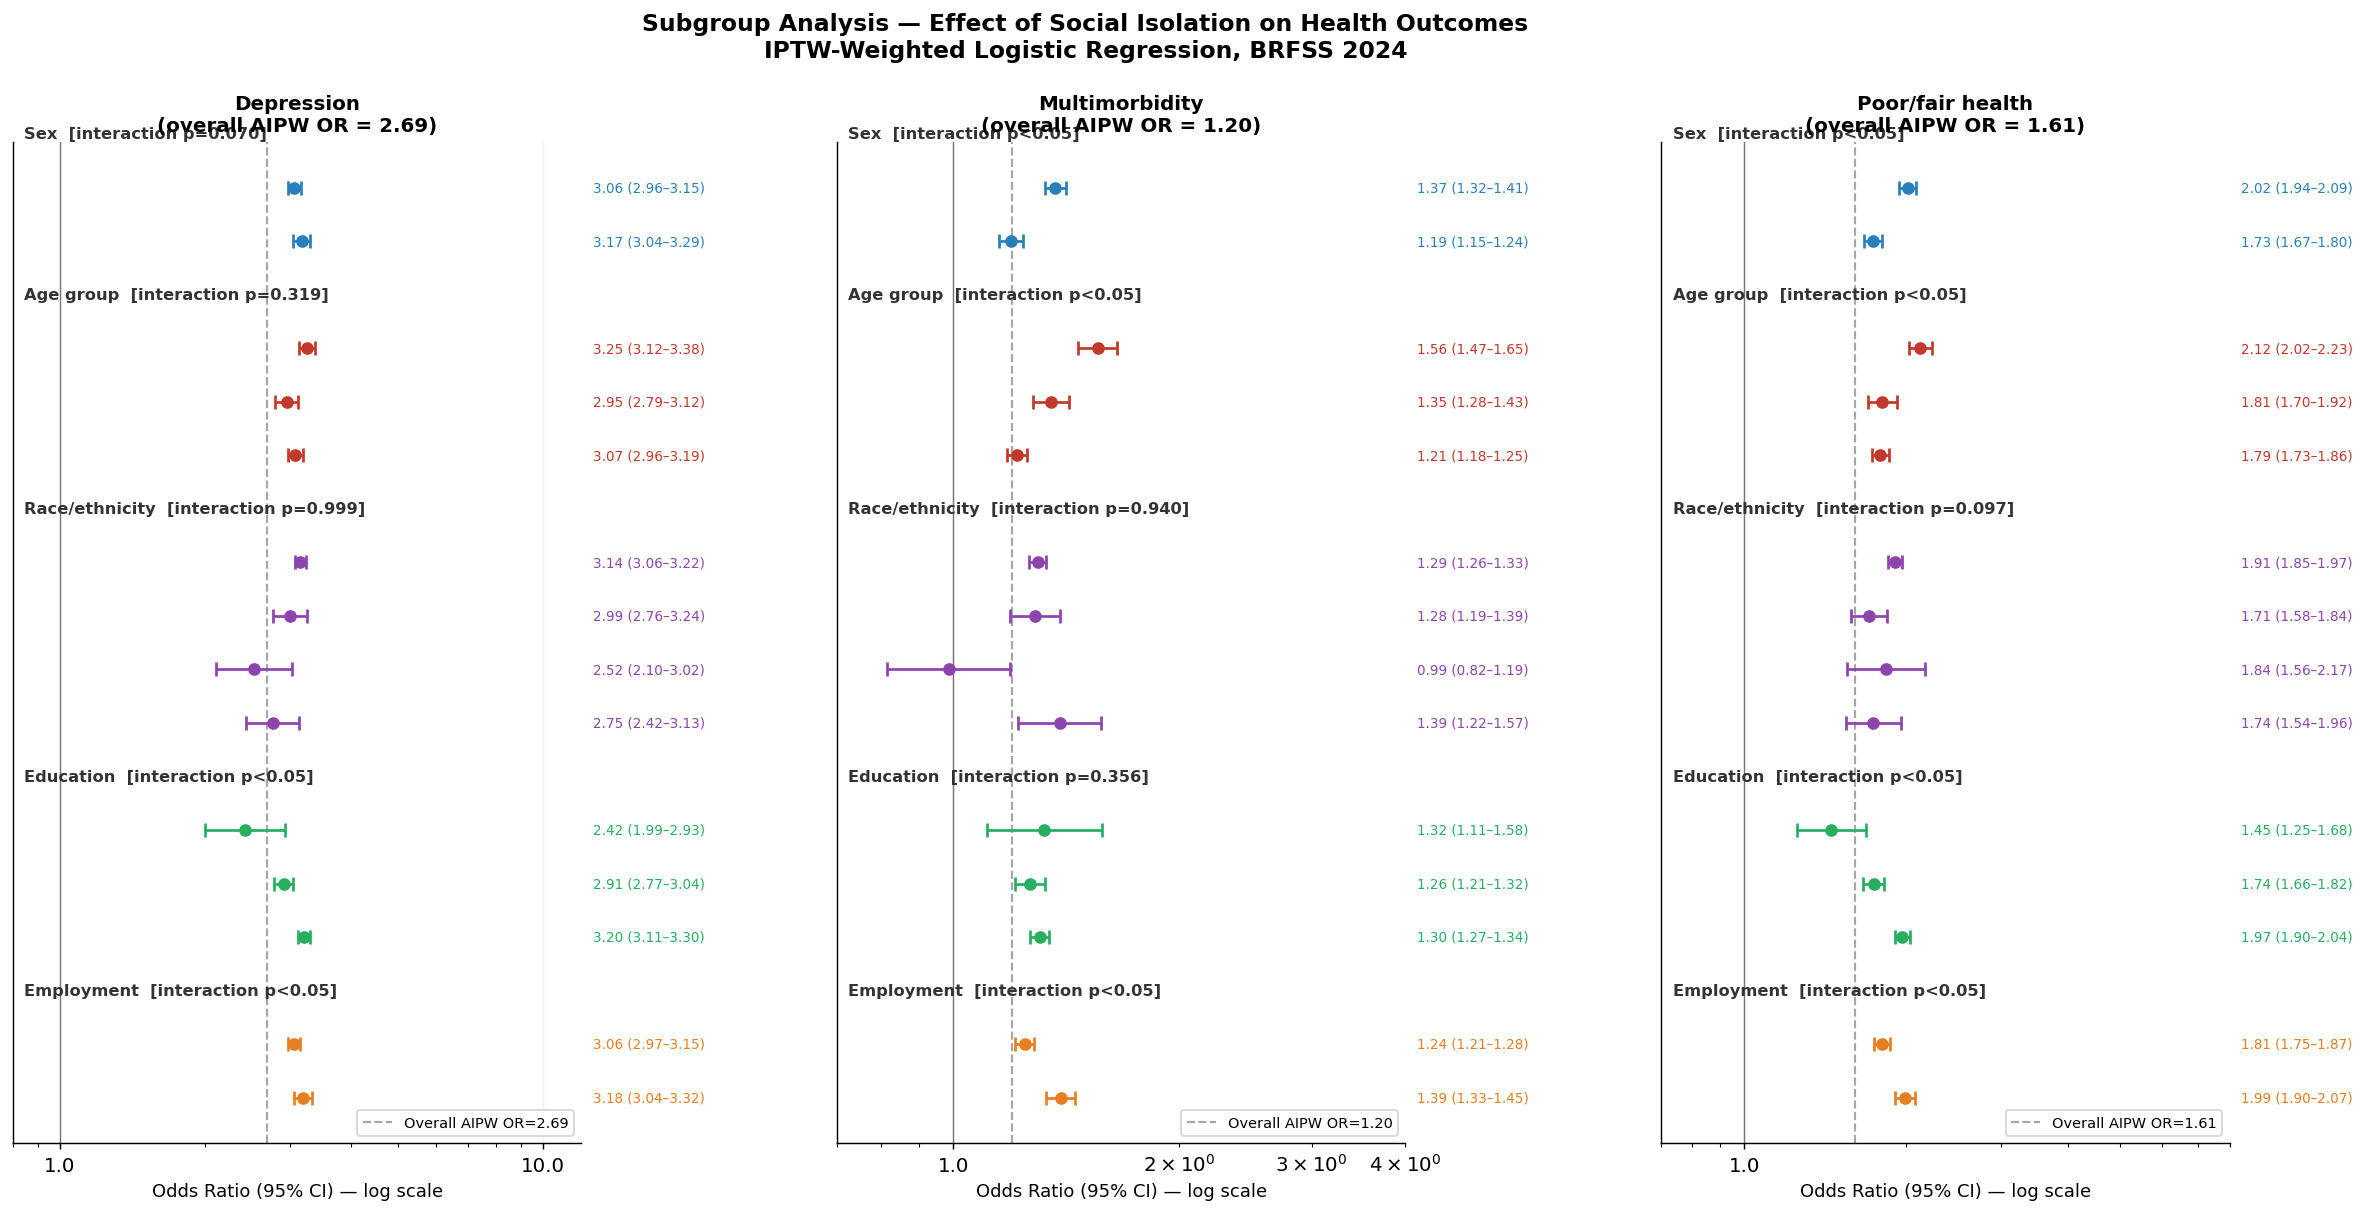

Saved: fig_subgroup_forest.png


In [ ]:
#PART C — SUBGROUP FOREST PLOTS (one per outcome)

print("\n── Generating subgroup forest plots …")

overall_or = {
    "Depression"      : res4["aipw_pooled"]["depression_bin"]["OR"],
    "Multimorbidity"  : res4["aipw_pooled"]["multimorbidity"]["OR"],
    "Poor/fair health": res4["aipw_pooled"]["poor_health_bin"]["OR"],
}

GROUP_COLORS = {
    "Sex"           : "#2980B9",
    "Age group"     : "#C0392B",
    "Race/ethnicity": "#8E44AD",
    "Education"     : "#27AE60",
    "Employment"    : "#E67E22",
}

fig, axes = plt.subplots(1, 3, figsize=(22, 10))
fig.subplots_adjust(wspace=0.45)

for ax, outcome_lbl in zip(axes, ["Depression", "Multimorbidity", "Poor/fair health"]):
    sub = subgroup_df[subgroup_df["Outcome"] == outcome_lbl].copy()

    rows      = []
    y_labels  = []
    y_colors  = []
    row_types = []

    for group_name in ["Sex", "Age group", "Race/ethnicity",
                        "Education", "Employment"]:
        grp = sub[sub["Moderator"] == group_name]
        if grp.empty:
            continue

        lrt_p = grp["LRT_p"].iloc[0]
        lrt_s = "p<0.05" if lrt_p < 0.05 else f"p={lrt_p:.3f}"

        rows.append(None)
        y_labels.append(f"{group_name}  [interaction {lrt_s}]")
        y_colors.append("#555555")
        row_types.append("header")

        for _, row in grp.iterrows():
            rows.append(row)
            y_labels.append(f"   {row['Stratum']}")
            y_colors.append(GROUP_COLORS.get(group_name, "gray"))
            row_types.append("data")

    n_rows = len(rows)
    y_pos  = np.arange(n_rows)[::-1]

    for i, (row, yp, lbl, col, rtype) in enumerate(
            zip(rows, y_pos, y_labels, y_colors, row_types)):
        if rtype == "header":
            ax.text(0.02, yp, lbl, ha="left", va="center",
                    fontsize=9, fontweight="bold", color="#333333",
                    transform=ax.get_yaxis_transform())
        else:
            ax.errorbar(
                row["OR"], yp,
                xerr=[[row["OR"] - row["OR_lo"]],
                      [row["OR_hi"] - row["OR"]]],
                fmt="o", color=col, capsize=4, capthick=1.5,
                markersize=6, linewidth=1.5, zorder=3
            )
            ci_str = f"{row['OR']:.2f} ({row['OR_lo']:.2f}–{row['OR_hi']:.2f})"
            ax.text(1.02, yp, ci_str,
                    ha="left", va="center", fontsize=7.5, color=col,
                    transform=ax.get_yaxis_transform())

    ov_or = overall_or[outcome_lbl]
    ax.axvline(ov_or, color="gray", linestyle="--", linewidth=1.2, alpha=0.7,
               label=f"Overall AIPW OR={ov_or:.2f}")
    ax.axvline(1.0, color="black", linestyle="-", linewidth=0.8, alpha=0.5)

    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{x:.1f}"))
    ax.set_xlabel("Odds Ratio (95% CI) — log scale", fontsize=10)
    ax.set_title(f"{outcome_lbl}\n(overall AIPW OR = {ov_or:.2f})",
                 fontweight="bold", fontsize=11)
    ax.set_yticks([])
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(axis="x", alpha=0.2)

    xlims = {
        "Depression": (0.8, 12),
        "Multimorbidity": (0.7, 4),
        "Poor/fair health": (0.7, 8),
    }
    ax.set_xlim(*xlims.get(outcome_lbl, (0.5, 8)))

plt.suptitle("Subgroup Analysis — Effect of Social Isolation on Health Outcomes\n"
             "IPTW-Weighted Logistic Regression, BRFSS 2024",
             fontweight="bold", fontsize=13)
plt.savefig("fig_subgroup_forest.png", bbox_inches="tight")
plt.show()
print("Saved: fig_subgroup_forest.png")

In [ ]:
#PART D — CONSOLIDATED FINAL RESULTS TABLE (Table 3)

print("\n" + "="*72)
print("TABLE 3 — Effect Modification: Subgroup Odds Ratios")
print("="*72)

for outcome_lbl in ["Depression", "Multimorbidity", "Poor/fair health"]:
    print(f"\n  {outcome_lbl}")
    print(f"  {'Subgroup':<26} {'OR':>6}  {'95% CI':>18}  "
          f"{'RD (pp)':>8}  {'n':>8}  {'LRT p':>8}")
    print("  " + "-"*75)

    sub = subgroup_df[subgroup_df["Outcome"] == outcome_lbl]
    for mod in ["Sex", "Age group", "Race/ethnicity", "Education", "Employment"]:
        grp   = sub[sub["Moderator"] == mod]
        lrt_p = grp["LRT_p"].iloc[0] if len(grp) else np.nan
        print(f"  {mod}")
        for _, row in grp.iterrows():
            print(f"    {row['Stratum']:<24} "
                  f"{row['OR']:>6.3f}  "
                  f"({row['OR_lo']:.3f}–{row['OR_hi']:.3f})  "
                  f"{row['RD_pp']:>+7.2f}  "
                  f"{row['n']:>8,}  "
                  f"{lrt_p:>8.4f}")



TABLE 3 — Effect Modification: Subgroup Odds Ratios

  Depression
  Subgroup                       OR              95% CI   RD (pp)         n     LRT p
  ---------------------------------------------------------------------------
  Sex
    Female                    3.055  (2.962–3.152)   +22.03   106,005    0.0701
    Male                      3.166  (3.045–3.291)   +15.90    93,735    0.0701
  Age group
    18–44                     3.248  (3.121–3.381)   +21.79    67,729    0.3191
    45–64                     2.950  (2.791–3.118)   +20.56    36,155    0.3191
    65+                       3.074  (2.962–3.190)   +16.60    95,856    0.3191
  Race/ethnicity
    White NH                  3.141  (3.059–3.225)   +20.51   165,882    0.9993
    Black NH                  2.988  (2.755–3.239)   +14.18    21,004    0.9993
    Asian NH                  2.517  (2.101–3.017)    +7.54     6,135    0.9993
    Other                     2.755  (2.425–3.130)   +15.14     7,281    0.9993
  Education
  


── Assembling final publication figure suite …


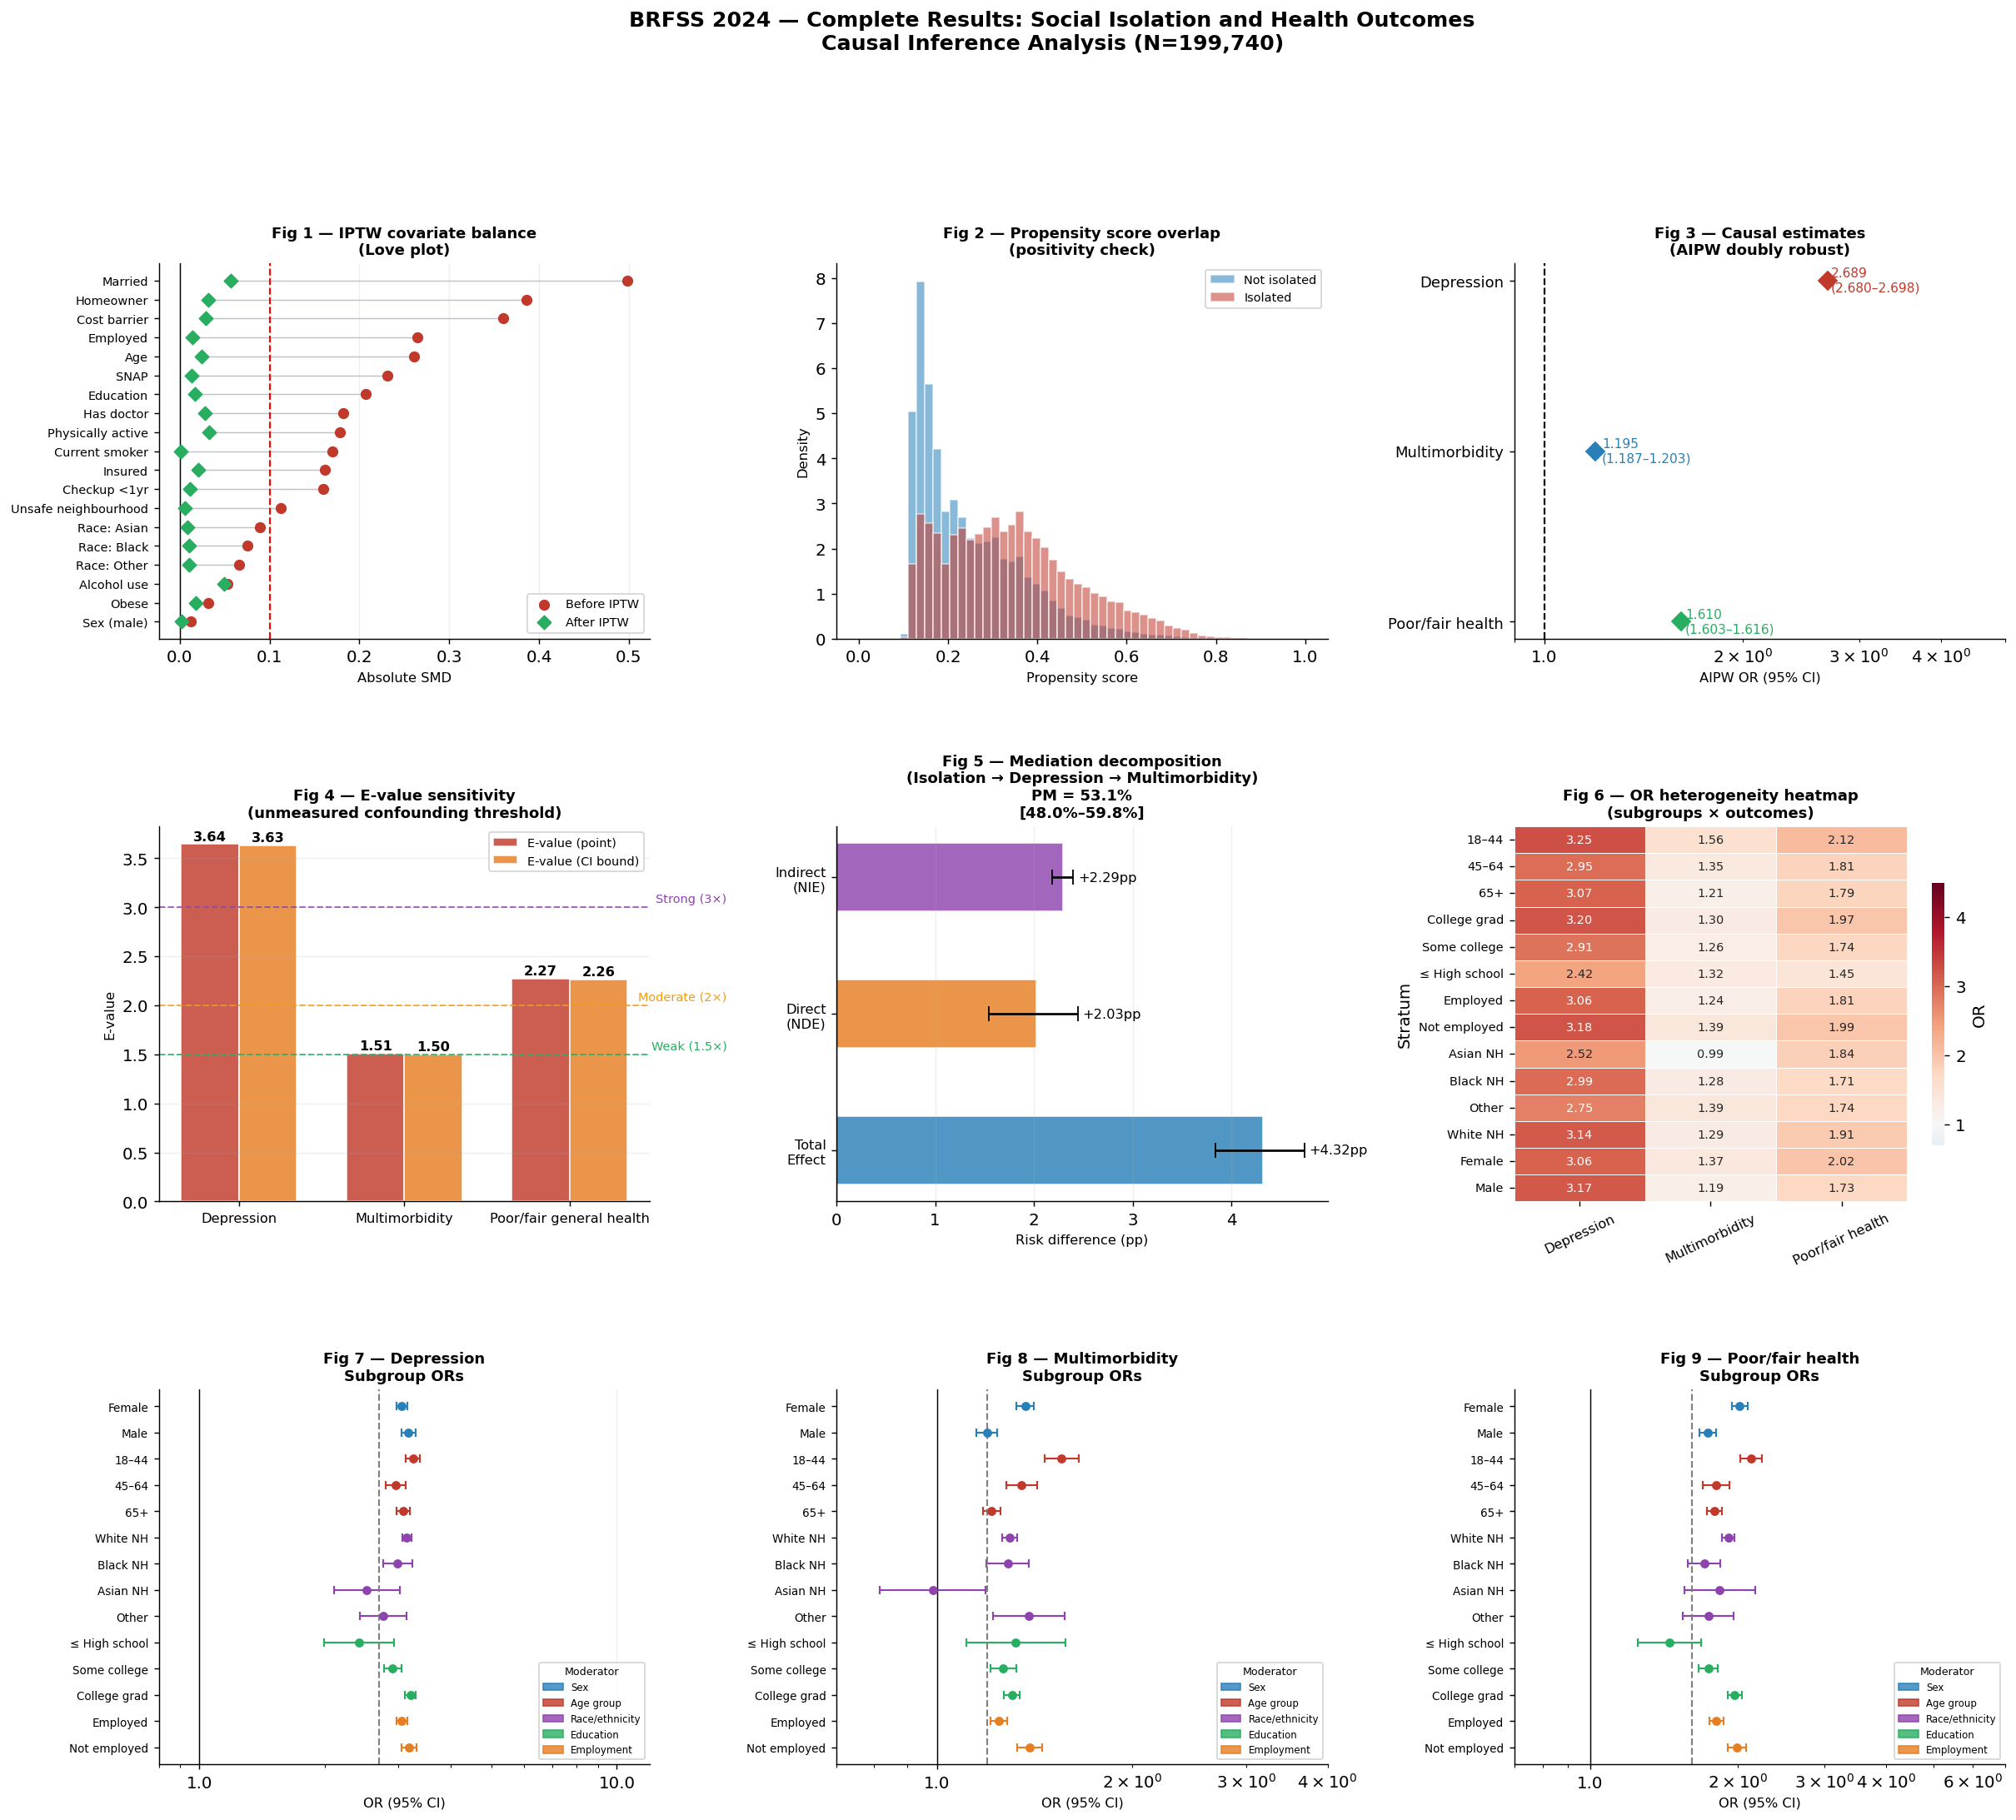

Saved: fig_complete_suite.png


In [ ]:
#PART E — COMPLETE FIGURE SUITE

print("\n── Assembling final publication figure suite …")

import os
ev_df  = pd.read_csv("evalues.csv")
med_df = pd.read_csv("mediation_results.csv")
smd_df = pd.read_csv("smd_balance.csv")

fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig,
                         hspace=0.50, wspace=0.38)

#Panel 1: Love plot (pre/post IPTW)
ax1 = fig.add_subplot(gs[0, 0])

smd_plot = smd_df.sort_values("Pre_IPTW", ascending=True)
var_labels = {
    "male":"Sex (male)", "age_mid":"Age", "black":"Race: Black",
    "asian":"Race: Asian", "other_race":"Race: Other",
    "married":"Married", "homeowner":"Homeowner",
    "employed":"Employed", "edu_num":"Education",
    "current_smoker":"Current smoker", "active":"Physically active",
    "obese":"Obese", "drinks_alcohol":"Alcohol use",
    "has_doctor_bin":"Has doctor", "insured":"Insured",
    "cost_barrier_bin":"Cost barrier", "checkup_recent":"Checkup <1yr",
    "food_stamps_bin":"SNAP", "unsafe_neighbourhood":"Unsafe neighbourhood",
}
y_lbls = [var_labels.get(v, v) for v in smd_plot["Variable"]]
y_p    = np.arange(len(y_lbls))

ax1.scatter(smd_plot["Pre_IPTW"],  y_p, color="#C0392B",
            s=40, zorder=3, label="Before IPTW")
ax1.scatter(smd_plot["Post_IPTW"], y_p, color="#27AE60",
            s=40, zorder=3, marker="D", label="After IPTW")
for i, (pre, post) in enumerate(
        zip(smd_plot["Pre_IPTW"], smd_plot["Post_IPTW"])):
    ax1.plot([pre, post], [i, i], color="#BDC3C7", lw=0.8, zorder=2)

ax1.axvline(0.10, color="red", ls="--", lw=1.2)
ax1.axvline(0.0,  color="black", lw=0.8)
ax1.set_yticks(y_p); ax1.set_yticklabels(y_lbls, fontsize=8)
ax1.set_xlabel("Absolute SMD", fontsize=9)
ax1.set_title("Fig 1 — IPTW covariate balance\n(Love plot)",
              fontweight="bold", fontsize=10)
ax1.legend(fontsize=8)
ax1.grid(axis="x", alpha=0.2)

#Panel 2: PS overlap
ax2 = fig.add_subplot(gs[0, 1])
ps0 = df.loc[df[EXPOSURE]==0, "ps"].values
ps1_ = df.loc[df[EXPOSURE]==1, "ps"].values

bins_ = np.linspace(0, 1, 55)
ax2.hist(ps0, bins=bins_, alpha=0.55, density=True,
         color="#2980B9", edgecolor="white", lw=0.3, label="Not isolated")
ax2.hist(ps1_, bins=bins_, alpha=0.55, density=True,
         color="#C0392B", edgecolor="white", lw=0.3, label="Isolated")
ax2.set_xlabel("Propensity score", fontsize=9)
ax2.set_ylabel("Density", fontsize=9)
ax2.set_title("Fig 2 — Propensity score overlap\n(positivity check)",
              fontweight="bold", fontsize=10)
ax2.legend(fontsize=8)

#Panel 3: Main results forest plot
ax3 = fig.add_subplot(gs[0, 2])

results_plot = [
    ("Depression",       2.689, 2.680, 2.698, "#C0392B"),
    ("Multimorbidity",   1.195, 1.187, 1.203, "#2980B9"),
    ("Poor/fair health", 1.610, 1.603, 1.616, "#27AE60"),
]
y_main = np.arange(len(results_plot))[::-1]

for i, (lbl, OR, lo, hi, col) in enumerate(results_plot):
    yp = y_main[i]
    ax3.errorbar(OR, yp, xerr=[[OR-lo],[hi-OR]],
                 fmt="D", color=col, capsize=5, capthick=2,
                 markersize=9, linewidth=2)
    ax3.text(hi+0.02, yp,
             f"{OR:.3f}\n({lo:.3f}–{hi:.3f})",
             va="center", fontsize=8.5, color=col)

ax3.axvline(1.0, color="black", ls="--", lw=1.2)
ax3.set_yticks(y_main)
ax3.set_yticklabels([r[0] for r in results_plot], fontsize=10)
ax3.set_xscale("log")
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f"{x:.1f}"))
ax3.set_xlabel("AIPW OR (95% CI)", fontsize=9)
ax3.set_title("Fig 3 — Causal estimates\n(AIPW doubly robust)",
              fontweight="bold", fontsize=10)
ax3.set_xlim(0.9, 5)
ax3.grid(axis="x", alpha=0.2)

#Panel 4: E-value chart
ax4 = fig.add_subplot(gs[1, 0])

out_lbls_ev = [o.replace(" (≥2 conditions)","") for o in ev_df["Outcome"]]
x_ev  = np.arange(len(out_lbls_ev))
w_ev  = 0.35
bars1 = ax4.bar(x_ev - w_ev/2, ev_df["E_value"],    w_ev,
                color="#C0392B", alpha=0.82, edgecolor="white",
                label="E-value (point)")
bars2 = ax4.bar(x_ev + w_ev/2, ev_df["E_value_CI"], w_ev,
                color="#E67E22", alpha=0.82, edgecolor="white",
                label="E-value (CI bound)")
for b in list(bars1)+list(bars2):
    ax4.text(b.get_x()+b.get_width()/2, b.get_height()+0.04,
             f"{b.get_height():.2f}", ha="center", fontsize=9,
             fontweight="bold")
for val, lbl_, col_ in [
    (1.5,"Weak (1.5×)","#27AE60"),
    (2.0,"Moderate (2×)","#F39C12"),
    (3.0,"Strong (3×)","#8E44AD")]:
    ax4.axhline(val, color=col_, ls="--", lw=1.1, alpha=0.8)
    ax4.text(len(out_lbls_ev)-0.05, val+0.05, lbl_,
             ha="right", fontsize=8, color=col_)
ax4.set_xticks(x_ev)
ax4.set_xticklabels(out_lbls_ev, fontsize=9)
ax4.set_ylabel("E-value", fontsize=9)
ax4.set_title("Fig 4 — E-value sensitivity\n(unmeasured confounding threshold)",
              fontweight="bold", fontsize=10)
ax4.legend(fontsize=8); ax4.grid(axis="y", alpha=0.2)

#Panel 5: Mediation waterfall
ax5 = fig.add_subplot(gs[1, 1])

med_vals = med_df[med_df["Effect"] != "Proportion Mediated"].copy()
colors_m = {"Total Effect":"#2980B9",
            "Natural Direct Effect (NDE)":"#E67E22",
            "Natural Indirect Effect (NIE)":"#8E44AD"}
y_med = np.arange(len(med_vals))

ax5.barh(y_med, med_vals["Estimate"],
         xerr=[med_vals["Estimate"]-med_vals["CI_lo"],
               med_vals["CI_hi"]-med_vals["Estimate"]],
         color=[colors_m.get(e,"gray") for e in med_vals["Effect"]],
         alpha=0.82, edgecolor="white", height=0.5,
         error_kw={"ecolor":"black","capsize":5,"lw":1.5})
ax5.axvline(0, color="black", lw=0.8)
ax5.set_yticks(y_med)
ax5.set_yticklabels(["Total\nEffect","Direct\n(NDE)","Indirect\n(NIE)"],
                    fontsize=9)
ax5.set_xlabel("Risk difference (pp)", fontsize=9)

pm_val = med_df.loc[med_df["Effect"]=="Proportion Mediated","Estimate"].values
pm_ci_lo = med_df.loc[med_df["Effect"]=="Proportion Mediated","CI_lo"].values
pm_ci_hi = med_df.loc[med_df["Effect"]=="Proportion Mediated","CI_hi"].values
pm_str = ""
if len(pm_val):
    pm_str = f"PM = {pm_val[0]:.1f}%\n[{pm_ci_lo[0]:.1f}%–{pm_ci_hi[0]:.1f}%]"

ax5.set_title(f"Fig 5 — Mediation decomposition\n"
              f"(Isolation → Depression → Multimorbidity)\n{pm_str}",
              fontweight="bold", fontsize=10)
ax5.grid(axis="x", alpha=0.2)
for i, (est, ci_hi) in enumerate(
        zip(med_vals["Estimate"], med_vals["CI_hi"])):
    ax5.text(ci_hi+0.05, i, f"{est:+.2f}pp",
             va="center", fontsize=9)

#Panel 6: Subgroup heterogeneity heatmap
ax6 = fig.add_subplot(gs[1, 2])

heatmap_data = subgroup_df.pivot_table(
    index="Stratum", columns="Outcome", values="OR", aggfunc="mean")

stratum_order = (
    subgroup_df.drop_duplicates("Stratum")
    .sort_values(["Moderator","Stratum"])["Stratum"]
    .tolist()
)
heatmap_data = heatmap_data.reindex(stratum_order)
heatmap_data = heatmap_data[["Depression","Multimorbidity","Poor/fair health"]]

sns.heatmap(heatmap_data, ax=ax6, cmap="RdBu_r", center=1.0,
            annot=True, fmt=".2f", annot_kws={"size": 8},
            linewidths=0.4, vmin=0.7, vmax=4.5,
            cbar_kws={"label":"OR","shrink":0.7})
ax6.set_title("Fig 6 — OR heterogeneity heatmap\n(subgroups × outcomes)",
              fontweight="bold", fontsize=10)
ax6.set_xlabel("")
ax6.tick_params(axis="x", rotation=25, labelsize=9)
ax6.tick_params(axis="y", rotation=0, labelsize=8)

#Panels 7–9: Per-outcome subgroup forest (compact)
outcome_plot_configs = [
    ("Depression",       gs[2, 0], 0.8, 12),
    ("Multimorbidity",   gs[2, 1], 0.7, 4),
    ("Poor/fair health", gs[2, 2], 0.7, 7),
]

for out_lbl, gs_slot, xlo, xhi in outcome_plot_configs:
    ax = fig.add_subplot(gs_slot)
    sub = subgroup_df[subgroup_df["Outcome"] == out_lbl].copy()

    y_pos_  = np.arange(len(sub))[::-1]
    col_map = {
        "Sex":"#2980B9","Age group":"#C0392B",
        "Race/ethnicity":"#8E44AD","Education":"#27AE60",
        "Employment":"#E67E22"
    }

    for i, (_, row) in enumerate(sub.iterrows()):
        col_ = col_map.get(row["Moderator"], "gray")
        yp   = y_pos_[i]
        ax.errorbar(row["OR"], yp,
                    xerr=[[row["OR"]-row["OR_lo"]],[row["OR_hi"]-row["OR"]]],
                    fmt="o", color=col_, capsize=3, capthick=1.2,
                    markersize=5, lw=1.2)

    ax.axvline(overall_or[out_lbl], color="gray", ls="--",
               lw=1.2, label=f"Overall={overall_or[out_lbl]:.2f}")
    ax.axvline(1.0, color="black", lw=0.8)
    ax.set_yticks(y_pos_)
    ax.set_yticklabels(
        [f"{r['Stratum']}" for _, r in sub.iterrows()],
        fontsize=7.5)
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x,_: f"{x:.1f}"))
    ax.set_xlim(xlo, xhi)
    ax.set_xlabel("OR (95% CI)", fontsize=9)
    ax.set_title(f"Fig {6+outcome_plot_configs.index((out_lbl,gs_slot,xlo,xhi))+1} "
                 f"— {out_lbl}\nSubgroup ORs",
                 fontweight="bold", fontsize=10)
    ax.legend(fontsize=7.5, loc="lower right")
    ax.grid(axis="x", alpha=0.2)

    patches = [mpatches.Patch(color=c, label=g, alpha=0.8)
               for g, c in col_map.items()]
    ax.legend(handles=patches, fontsize=6.5, loc="lower right",
              title="Moderator", title_fontsize=7)

plt.suptitle(
    "BRFSS 2024 — Complete Results: Social Isolation and Health Outcomes\n"
    "Causal Inference Analysis (N=199,740)",
    fontweight="bold", fontsize=14, y=1.01)

plt.savefig("fig_complete_suite.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_complete_suite.png")

In [ ]:
import time

end = time.time() + 50*60

while time.time() < end:
    _ = 1+1
    time.sleep(120)

In [ ]:
import os
import zipfile

zip_path = '/content/all_files.zip'
folder_path = '/content'

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            if file_path != zip_path:
                zipf.write(file_path, os.path.relpath(file_path, folder_path))

print("Zipping done!")

Zipping done!


In [ ]:
from google.colab import files
files.download('/content/all_files.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>